# ЗАДАНИЕ
Дан многомерный размеченный набор данных. Необходимо выполнить регрессионный анализ данных на основе полносвязной нейросетевой модели и нейросетевой модели, указанной в варианте, в соответствии со следующей последовательностью этапов.
1. Загрузить необходимые пакеты и библиотеки.
2. Загрузить данные из указанного источника.
3. Выполнить разведочный анализ данных в соответствии с этапами описанными в файле Этапы проекта машинного обучения в примерах.pdf:\
a. Ознакомление с данными с помощью методов описательной статистики;\
b. Выполнить визуализацию данных одномерную для понимания распределения данных и многомерную для выяснения зависимостей между признаками;\
c. При необходимости выполнить очистку данных одним из методов.\
d. Проанализировать корреляционную зависимость между признаками;\
e. Поэкспериментировать с комбинациями атрибутов. При необходимости добавить новые атрибуты в набор данных.\
f. Выполнить отбор существенных признаков. Сформировать набор данных из существенных признаков.\
g. При необходимости преобразовать текстовые или категориальные признаки одним из методов.\
h. Выполнить преобразование данных для обоих наборов (исходного и сформированного) одним из методов по варианту.
4. Анализ выполняется для исходного набора данных, преобразованного исходного набора данных, построенного набора данных и преобразованного построенного набора данных. Во всех наборах данных выделить обучающую, проверочную (валидационную) и тестовую выборки данных.
5. Сравнить качество полносвязной нейросетевой регрессионной модели и регрессионной нейросетевой модели, указанной в варианте, на обучающей и валидационной выборках для всех наборов данных, включая их преобразованные варианты. Для оценки качества моделей использовать метрики: корень из среднеквадратичной ошибки, коэффициент детерминации R2.
6. Для лучшей модели на лучшем наборе данных оценить качество на тестовом наборе.
7. Для лучшей модели на лучшем наборе данных выполнить Grid поиск лучших гиперпараметров регрессионной нейросетевой модели на обучающей и валидационной выборках. Определить значения лучших гиперпараметров.
8. Определить показатели качества полученной в результате Grid поиска регрессионной нейросетевой модели на тестовом наборе. Сравнить показатели качества лучшей модели на лучшем наборе данных до поиска гиперпараметров и после поиска гиперпараметров.
9. Сделать выводы по проведенному анализу.

# ПОСТАНОВКА ИНДИВИДУАЛЬНЫЙ ВАРИАНТ ЗАДАНИЯ
Вариант 13

**Цель проекта:** Провести регрессионный анализ данных телемониторинга болезни Паркинсона для прогнозирования целевого признака `total_UPDRS` на основе нейросетевых моделей.

## Формальное описание задачи
**Проблема:** Построение регрессионной модели для прогнозирования общего показателя UPDRS (Unified Parkinson's Disease Rating Scale) на основе голосовых характеристик пациентов.

**Целевая переменная:** `total_UPDRS`

**Входные признаки:** Все признаки из набора данных, за исключением:
- `motor_UPDRS` (исключен по условию варианта)
- `index`, `subject#` (служебные идентификаторы)

**Основные этапы решения:**
1. Разведочный анализ данных (EDA) с описательной статистикой и визуализацией
2. Предобработка данных, включая стандартизацию и отбор признаков
3. Построение и сравнение двух типов нейросетевых моделей:
   - Полносвязная нейронная сеть(MLP) Multi-Layer Perceptron
   - Двунаправленная LSTM-сеть
4. Оптимизация гиперпараметров и оценка качества моделей

## Мотивация и применение
**Практическая значимость:** Разработанная модель может быть использована для:
- Неинвазивного мониторинга прогрессирования болезни Паркинсона
- Объективной оценки эффективности лечения
- Раннего выявления ухудшения состояния пациентов

**Метрики качества:**
- RMSE (корень из среднеквадратичной ошибки)
- R² (коэффициент детерминации)

## Предметная область
Болезнь Паркинсона - прогрессирующее неврологическое заболевание, где показатель UPDRS является стандартным инструментом оценки тяжести симптомов. Голосовые характеристики (jitter, shimmer, HNR и др.) являются важными маркерами двигательных нарушений, что делает возможным построение регрессионных моделей для прогнозирования общего состояния пациента.

In [255]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
#from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization, LSTM, Bidirectional, Masking
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from scipy.stats import loguniform, randint
from scipy.stats.mstats import winsorize
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import skew, kurtosis
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')


In [256]:
# We will ensure the reproducibility of calculations by fixing the random seed values, enabling deterministic operations in TensorFlow, and limiting multithreading.
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load the dataset
data_path = 'E:/Data-mining-based-on-machine-learning-methods/lab1/LR!_datasets/V5.csv'
df = pd.read_csv(data_path)

# Exploratory Data Analysis

### Check the success of dataset, first 5 rows and basic information about it


In [257]:
print(f"Размер: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

print("\nПервые 5 строк:")
display(df.head())
size_mb = os.path.getsize(data_path) / (1024 * 1024)

print("=== Основная информация о наборе данных ===")
print(f"1️⃣ Размер набора данных: {size_mb:.2f} МБ")
print(f"2️⃣ Количество записей: {len(df)}")
print(f"3️⃣ Количество признаков: {len(df.columns)}")
print(f"4️⃣ Целевая переменная: 'total_UPDRS' (тип: {df['total_UPDRS'].dtype})")
print(f"5️⃣ Категориальный признак: 'sex' (бинарный 0/1)")
print(f"6️⃣ Уникальных пациентов: {df['subject#'].nunique()}")
print(f"7️⃣ Временной диапазон тестов: {df['test_time'].min()} → {df['test_time'].max()}")

Размер: (5875, 24)
Колонки: ['Unnamed: 0', 'index', 'subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

Первые 5 строк:


,Unnamed: 0,index,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,0,0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,2,2,1,72,0,19.6810,28.695,35.389,0.00481,NaN,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,3,3,1,72,0,25.6470,28.905,35.810,0.00528,NaN,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,4,4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


=== Основная информация о наборе данных ===
1️⃣ Размер набора данных: 0.90 МБ
2️⃣ Количество записей: 5875
3️⃣ Количество признаков: 24
4️⃣ Целевая переменная: 'total_UPDRS' (тип: float64)
5️⃣ Категориальный признак: 'sex' (бинарный 0/1)
6️⃣ Уникальных пациентов: 42
7️⃣ Временной диапазон тестов: -4.2625 → 215.49


In [259]:
df.info()
print("\n=== Пропущенные значения (по колонкам) ===")
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]   # фильтруем только где есть пропуски
print(missing_cols)

print("\n=== Пропущенные значения (по строкам) ===")
missing_rows = df.isnull().sum(axis=1)
missing_rows = missing_rows[missing_rows > 0]   # фильтруем только строки с пропусками
print(missing_rows)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     5875 non-null   int64  
 1   index          5875 non-null   int64  
 2   subject#       5875 non-null   int64  
 3   age            5875 non-null   int64  
 4   sex            5875 non-null   int64  
 5   test_time      5875 non-null   float64
 6   motor_UPDRS    5875 non-null   float64
 7   total_UPDRS    5875 non-null   float64
 8   Jitter(%)      5875 non-null   float64
 9   Jitter(Abs)    2944 non-null   float64
 10  Jitter:RAP     5875 non-null   float64
 11  Jitter:PPQ5    5875 non-null   float64
 12  Jitter:DDP     5875 non-null   float64
 13  Shimmer        5875 non-null   float64
 14  Shimmer(dB)    5875 non-null   float64
 15  Shimmer:APQ3   5875 non-null   float64
 16  Shimmer:APQ5   5875 non-null   float64
 17  Shimmer:APQ11  5875 non-null   float64
 18  Shimmer:

#### Наш датафрейм показывает, что он содержит 24 признака, при этом у одного признака — Jitter(Abs) — отсутствуют значения в 2931 записи из общего числа 5875. Соответствующие строки с пропущенными значениями отражены в разделе поиска пропусков по строкам. Наш набор данных включает 19 признаков типа float и 5 признаков типа integer, среди которых переменная sex является бинарным представлением (0 или 1).
**Unnamed: 0, index и subject# (служебные идентификаторы, не несущие смысловой нагрузки)**


In [260]:
print("=== Описательная статистика набора данных ===")
display(df.describe(include="all"))


=== Описательная статистика набора данных ===


,Unnamed: 0,index,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,2944.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,2937.000000,2937.000000,21.494128,64.804936,0.317787,92.863722,21.296229,29.018942,0.006154,0.000044,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,1696.110747,1696.110747,12.372279,8.821524,0.465656,53.445602,8.129282,10.700283,0.005624,0.000036,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,0.000000,0.000000,1.000000,36.000000,0.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,1468.500000,1468.500000,10.000000,58.000000,0.000000,46.847500,15.000000,21.371000,0.003580,0.000023,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,2937.000000,2937.000000,22.000000,65.000000,0.000000,91.523000,20.871000,27.576000,0.004900,0.000035,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,4405.500000,4405.500000,33.000000,72.000000,1.000000,138.445000,27.596500,36.399000,0.006800,0.000053,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,5874.000000,5874.000000,42.000000,85.000000,1.000000,215.490000,39.511000,54.992000,0.099990,0.000396,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730


##  Сводка по набору данных
- **Размер набора данных**: 5875 записей, 24 признака.  
- **Пациенты**: 42 уникальных пациента (`subject#` от 1 до 42).  
- **Возраст**: 36–85 лет, среднее ≈ 65 лет.  
- **Пол**: бинарный (0 = мужчина, 1 = женщина), около 32% женщин.  
- **Время теста**: –4.26 → 215.49 (вероятно, дни/часы, зависит от определения в датасете).  

###  Целевые переменные
- `motor_UPDRS`: 5.03 – 39.51 (среднее ≈ 21.3).  
  ⚠️ Будет исключена (оставляем одну целевую переменную).  
- `total_UPDRS`: 7.0 – 54.99 (среднее ≈ 29.0).  

### 🎙 Голосовые признаки
- **Jitter, Shimmer, NHR, HNR, RPDE, DFA, PPE**: в основном малые значения (доли).  
- Есть выбросы: `Jitter` до 0.0999, `Shimmer(dB)` до 2.107.  
- **Jitter(Abs)**: имеет пропуски (только 2944 из 5875 заполнены).  

### 📌 Ключевое наблюдение
Набор данных хорошо структурирован с числовыми признаками.  
Требуется особое внимание к пропускам в **Jitter(Abs)**  
и корректной интерпретации **test_time** (масштаб/единицы).


In [261]:
# === Удаление ненужных признаков ===
cols_to_drop = ['motor_UPDRS', 'Unnamed: 0', 'index']
existing_cols = [col for col in cols_to_drop if col in df.columns]

if existing_cols:  # если такие колонки реально существуют
    df = df.drop(columns=existing_cols)
    print(f"\n✅ Удалены ненужные признаки: {existing_cols}")
else:
    print("\nℹ️ Ненужные признаки не найдены.")



✅ Удалены ненужные признаки: ['motor_UPDRS', 'Unnamed: 0', 'index']


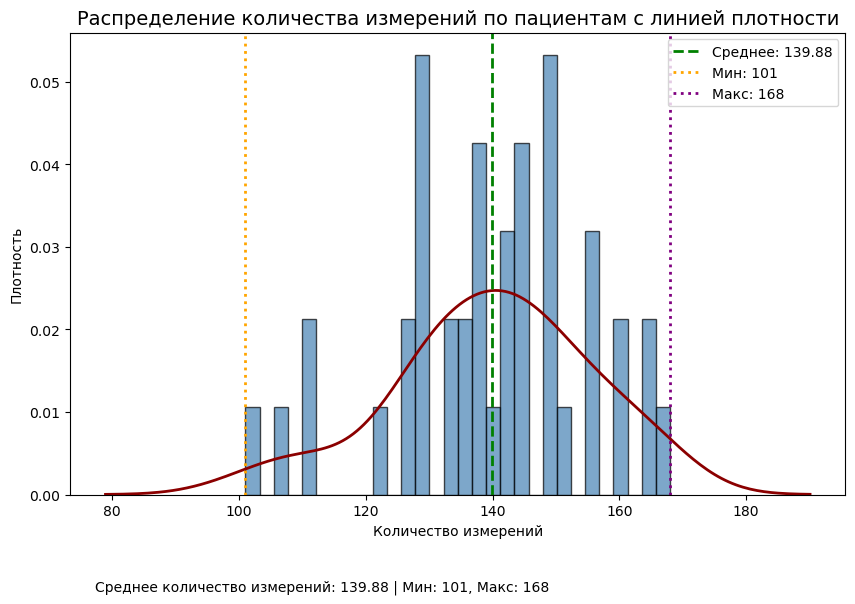

In [262]:
# === Статистика по пациентам с линией распределения ===
subject_counts = df['subject#'].value_counts()
mean_count = subject_counts.mean()
min_count = subject_counts.min()
max_count = subject_counts.max()

plt.figure(figsize=(10,6))

# Histogram
n, bins, patches = plt.hist(subject_counts, bins=30, color="steelblue", edgecolor="black", alpha=0.7, density=True)

# Overlay KDE line to show distribution type
import seaborn as sns
sns.kdeplot(subject_counts, color="darkred", linewidth=2)

# Add vertical lines for min, mean, max
plt.axvline(mean_count, color='green', linestyle='--', linewidth=2, label=f"Среднее: {mean_count:.2f}")
plt.axvline(min_count, color='orange', linestyle=':', linewidth=2, label=f"Мин: {min_count}")
plt.axvline(max_count, color='purple', linestyle=':', linewidth=2, label=f"Макс: {max_count}")

plt.title("Распределение количества измерений по пациентам с линией плотности", fontsize=14)
plt.xlabel("Количество измерений")
plt.ylabel("Плотность")
plt.legend()

# Add text annotation below the histogram showing average range
plt.figtext(0.15, -0.05, f"Среднее количество измерений: {mean_count:.2f} | Мин: {min_count}, Макс: {max_count}", fontsize=10)

plt.show()


Распределение количества измерений на пациента имеет примерно колоколообразную форму(bell-shaped) с легким смещением вправо, со средним значением около 140 и диапазоном от 101 до 168. Это указывает на то, что набор данных хорошо сбалансирован, так как большинство пациентов имеют схожее количество наблюдений. Как следствие, риск смещения модели невелик, поскольку ни один отдельный пациент или небольшая группа не доминируют в данных.

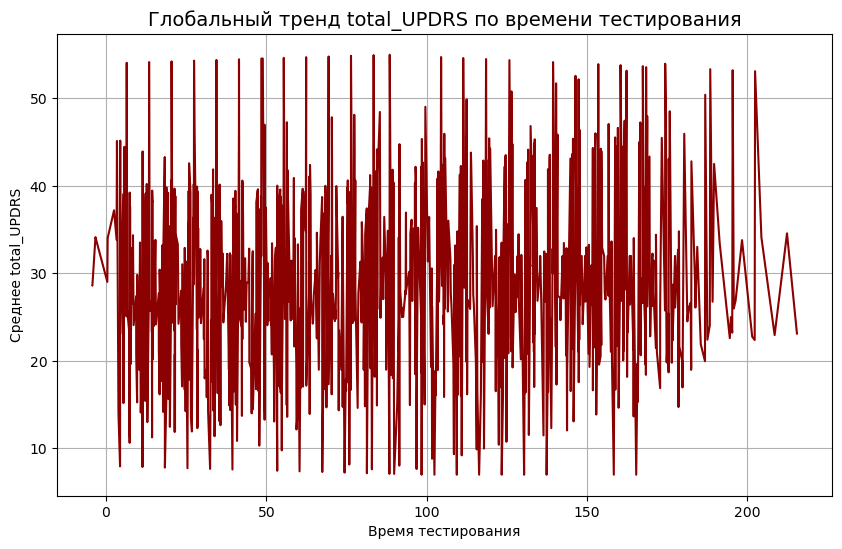

In [263]:
# === Глобальный тренд total_UPDRS по времени ===
# Tells you whether time is a strong predictor
plt.figure(figsize=(10,6))
df_grouped = df.groupby("test_time")["total_UPDRS"].mean()
plt.plot(df_grouped.index, df_grouped.values, color="darkred")
plt.title("Глобальный тренд total_UPDRS по времени тестирования", fontsize=14)
plt.xlabel("Время тестирования")
plt.ylabel("Среднее total_UPDRS")
plt.grid(True)
plt.show()

print("")

Слабый прогностический признак: Сам по себе test_time (время тестирования), скорее всего, будет слабым признаком для прогнозирования total_UPDRS в модели. Модель не может выучить последовательную взаимосвязь из этих данных.

График показывает стабильную, но изменчивую среднюю тяжесть симптомов с течением времени, что указывает на необходимость искать хорошие предикторы оценок UPDRS за пределами простого временного фактора.

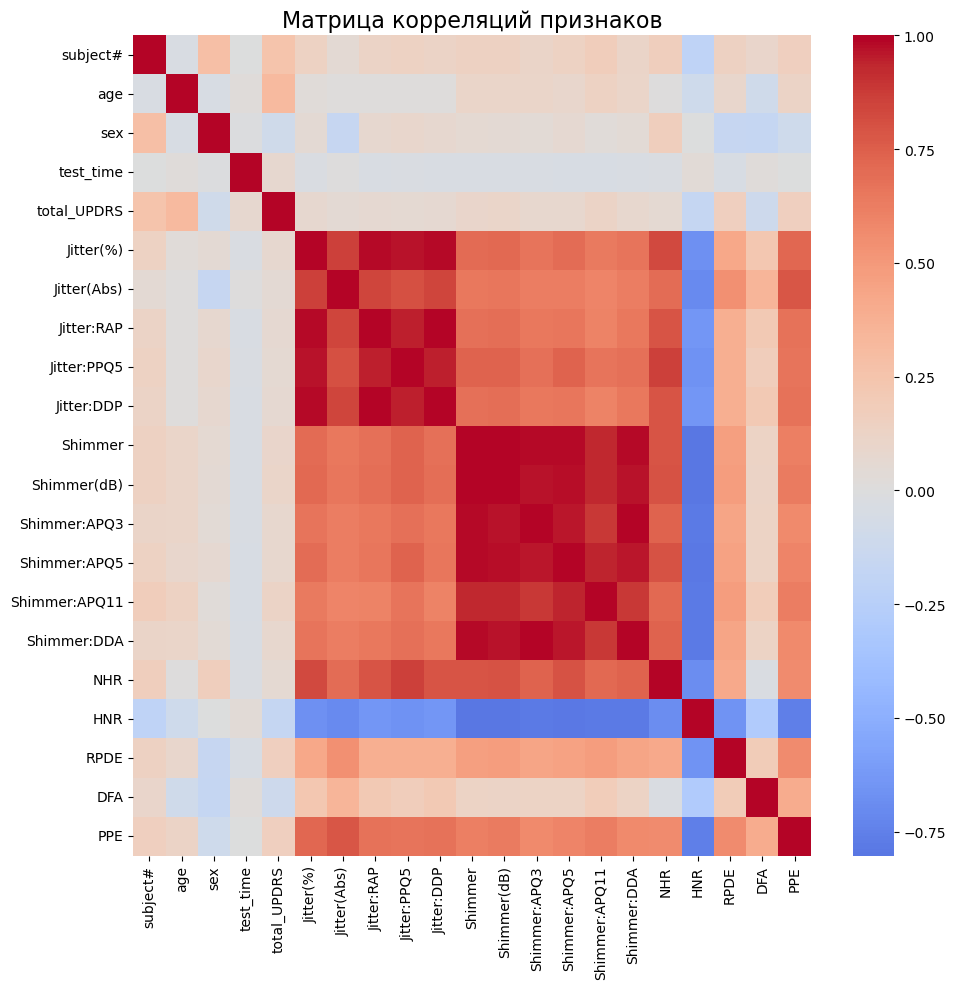


=== Корреляция признаков с total_UPDRS ===
total_UPDRS      1.000000
age              0.310290
subject#         0.253643
RPDE             0.156897
PPE              0.156195
Shimmer:APQ11    0.120838
Shimmer(dB)      0.098790
Shimmer          0.092141
Shimmer:APQ5     0.083467
Shimmer:DDA      0.079363
Shimmer:APQ3     0.079363
test_time        0.075263
Jitter(%)        0.074247
Jitter:DDP       0.064027
Jitter:RAP       0.064015
Jitter:PPQ5      0.063352
NHR              0.060952
Jitter(Abs)      0.054074
sex             -0.096559
DFA             -0.113475
HNR             -0.162117
Name: total_UPDRS, dtype: float64


In [264]:
# === Анализ корреляций ===
# Features highly correlated with total_UPDRS are potential predictors.
# Features highly correlated with each other may be redundant.
# Helps with feature selection and avoiding multicollinearity.
corr_matrix = df.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Матрица корреляций признаков', fontsize=16)
plt.tight_layout()
plt.show()

target_corr = corr_matrix['total_UPDRS'].sort_values(ascending=False)
print("\n=== Корреляция признаков с total_UPDRS ===")
print(target_corr)

In [265]:
# === Сильно коррелирующие пары признаков (с комментариями) ===
high_corr_records = []

for i, col1 in enumerate(corr_matrix.columns):
    for j, col2 in enumerate(corr_matrix.columns):
        if i < j:  # избегаем дубликатов и самокорреляции
            corr_val = corr_matrix.loc[col1, col2]
            comment = (
                "⚠️ Возможная избыточность (|корр| > 0.9)"
                if abs(corr_val) > 0.9
                else "Проблем избыточности нет"
            )
            high_corr_records.append((col1, col2, corr_val, comment))
            
# Конвертируем в DataFrame для красивого отображения
high_corr_df = pd.DataFrame(
    high_corr_records,
    columns=["Признак 1", "Признак 2", "Корреляция", "Комментарий"]
).sort_values(by="Корреляция", key=lambda x: abs(x), ascending=False)

print("\n=== Таблица корреляций пар признаков ===")
display(high_corr_df.head(20))  # показываем топ-20 самых сильных корреляций


=== Таблица корреляций пар признаков ===


,Признак 1,Признак 2,Корреляция,Комментарий
176,Shimmer:APQ3,Shimmer:DDA,1.000000,⚠️ Возможная избыточность (|корр| > 0.9)
120,Jitter:RAP,Jitter:DDP,1.000000,⚠️ Возможная избыточность (|корр| > 0.9)
155,Shimmer,Shimmer(dB),0.992334,⚠️ Возможная избыточность (|корр| > 0.9)
157,Shimmer,Shimmer:APQ5,0.984904,⚠️ Возможная избыточность (|корр| > 0.9)
93,Jitter(%),Jitter:DDP,0.984184,⚠️ Возможная избыточность (|корр| > 0.9)
91,Jitter(%),Jitter:RAP,0.984181,⚠️ Возможная избыточность (|корр| > 0.9)
156,Shimmer,Shimmer:APQ3,0.979828,⚠️ Возможная избыточность (|корр| > 0.9)
159,Shimmer,Shimmer:DDA,0.979827,⚠️ Возможная избыточность (|корр| > 0.9)
166,Shimmer(dB),Shimmer:APQ5,0.976373,⚠️ Возможная избыточность (|корр| > 0.9)
92,Jitter(%),Jitter:PPQ5,0.968214,⚠️ Возможная избыточность (|корр| > 0.9)


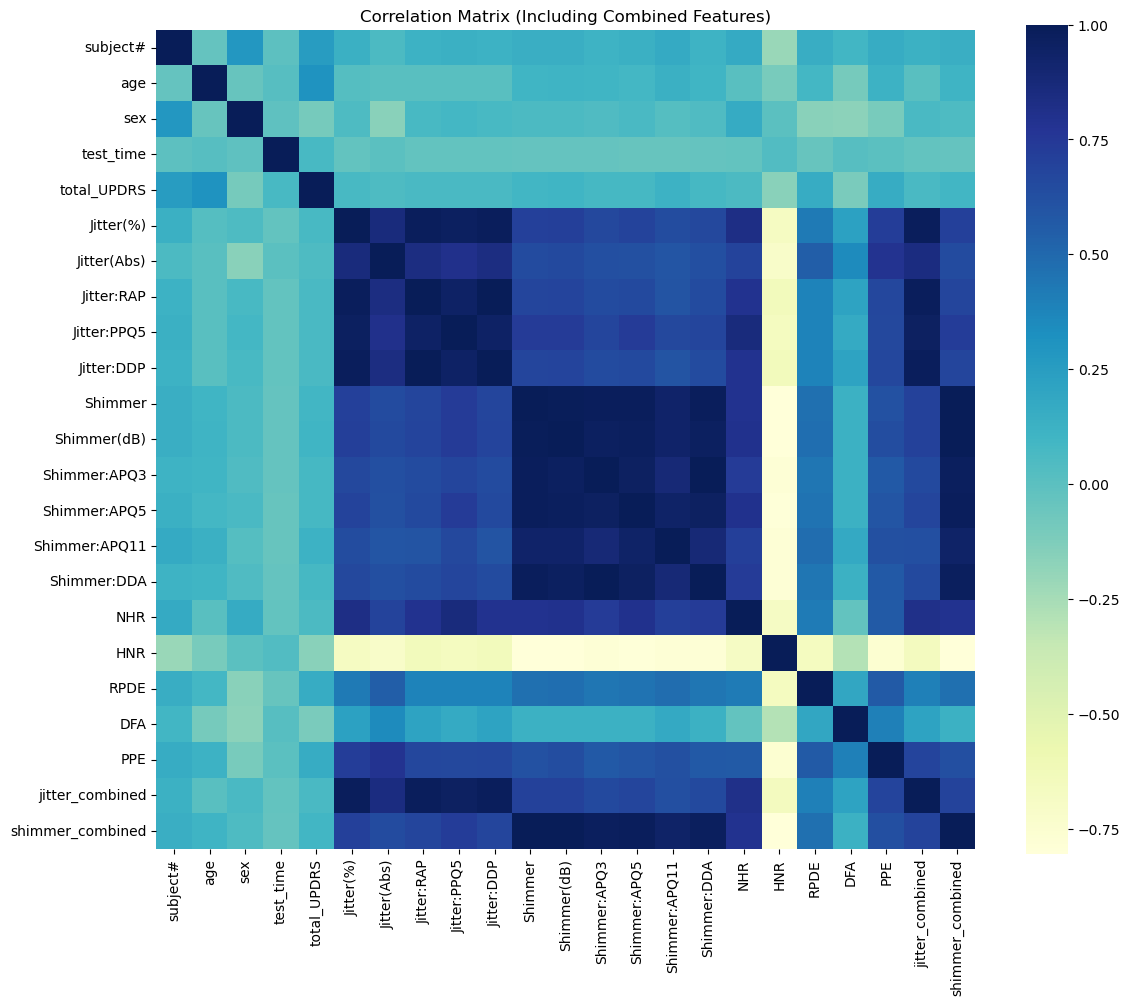

In [266]:
# Create combined features on a copy of the dataset
shimmer_features = ['Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA']
jitter_features = ['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP']

# Create a copy for analysis
df_analysis = df.copy()

# Create combined features on the copy
df_analysis['jitter_combined'] = df_analysis[jitter_features].mean(axis=1)
df_analysis['shimmer_combined'] = df_analysis[shimmer_features].mean(axis=1)

# Perform correlation on the analysis dataset
correlation = df_analysis.corr()
plt.figure(figsize=(12, 10))
plt.title("Correlation Matrix (Including Combined Features)")
sns.heatmap(correlation, vmax=1, square=True, annot=False, cmap="YlGnBu")
plt.tight_layout()
plt.show()

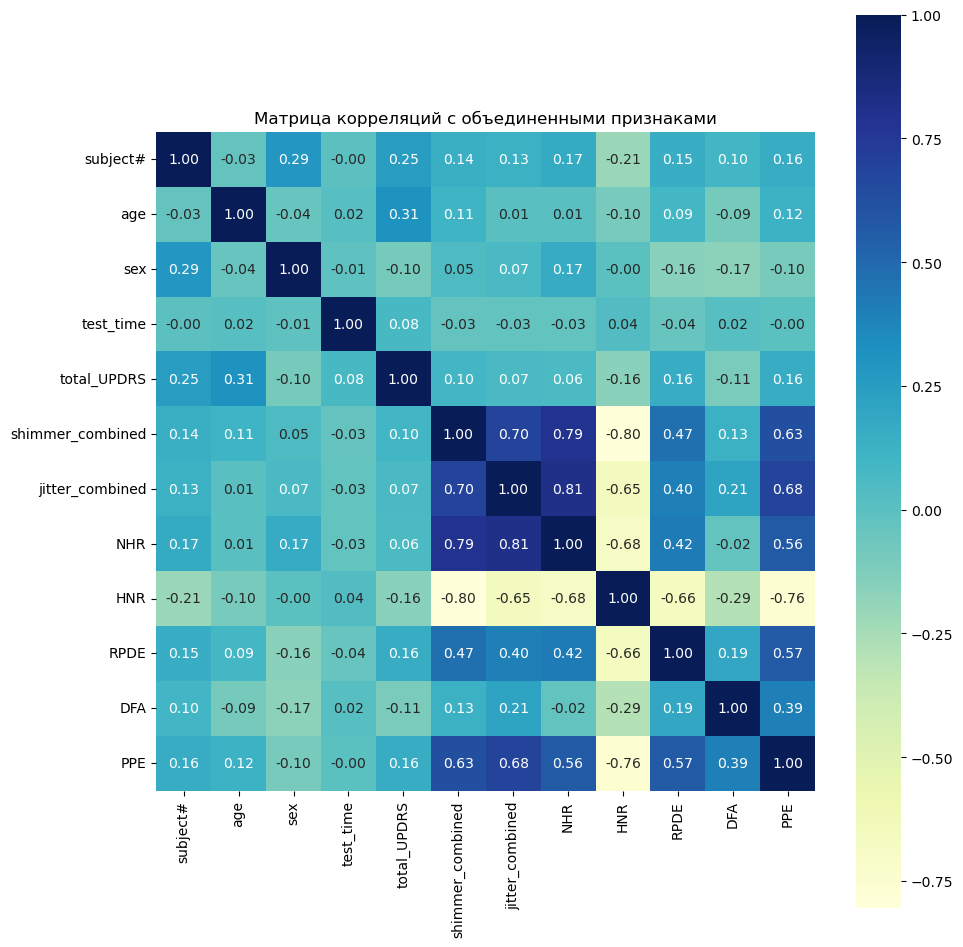


=== Корреляция с total_UPDRS (после объединения признаков) ===
total_UPDRS         1.000000
age                 0.310290
subject#            0.253643
RPDE                0.156897
PPE                 0.156195
shimmer_combined    0.096716
test_time           0.075263
jitter_combined     0.067477
NHR                 0.060952
sex                -0.096559
DFA                -0.113475
HNR                -0.162117
Name: total_UPDRS, dtype: float64


In [267]:
# Оставляем только объединенные версии и другие важные признаки
features_to_keep = [
    'subject#', 'age', 'sex', 'test_time', 'total_UPDRS',
    'shimmer_combined', 'jitter_combined',
    'NHR', 'HNR', 'RPDE', 'DFA', 'PPE'
]

df_combined = df_analysis[features_to_keep]

# Выполняем корреляцию на новом наборе данных
correlation = df_combined.corr()
plt.figure(figsize=(10, 10))
plt.title("Матрица корреляций с объединенными признаками")
sns.heatmap(correlation, vmax=1, square=True, annot=True, cmap="YlGnBu", fmt='.2f')
plt.tight_layout()
plt.show()

# Проверяем корреляцию с целевой переменной отдельно
print("\n=== Корреляция с total_UPDRS (после объединения признаков) ===")
target_corr_new = correlation['total_UPDRS'].sort_values(ascending=False)
print(target_corr_new)

In [268]:

# Проверяем оставшуюся мультиколлинеарность
print("\n=== Проверка на мультиколлинеарность ===")
# Ищем высокие корреляции между предикторами (исключая целевую и subject#)
predictor_corr = correlation.drop(['total_UPDRS', 'subject#'], errors='ignore')
predictor_corr = predictor_corr.drop(['total_UPDRS', 'subject#'], axis=1, errors='ignore')

# Находим высокие корреляции между предикторами (абсолютное значение > 0.7)
high_corr_pairs = []
for i in range(len(predictor_corr.columns)):
    for j in range(i+1, len(predictor_corr.columns)):
        if abs(predictor_corr.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                predictor_corr.columns[i],
                predictor_corr.columns[j],
                predictor_corr.iloc[i, j]
            ))

if high_corr_pairs:
    print("Обнаружены высокие корреляции (потенциальная мультиколлинеарность):")
    for feature1, feature2, corr_value in high_corr_pairs:
        print(f"  {feature1} - {feature2}: {corr_value:.3f}")
else:
    print("Значительной мультиколлинеарности не обнаружено (все корреляции < |0.7|)")

# Проверяем силу наших новых объединенных признаков
print(f"\nКорреляции объединенных признаков с целевой переменной:")
print(f"shimmer_combined: {correlation.loc['shimmer_combined', 'total_UPDRS']:.3f}")
print(f"jitter_combined: {correlation.loc['jitter_combined', 'total_UPDRS']:.3f}")


=== Проверка на мультиколлинеарность ===
Обнаружены высокие корреляции (потенциальная мультиколлинеарность):
  shimmer_combined - NHR: 0.790
  shimmer_combined - HNR: -0.804
  jitter_combined - NHR: 0.812
  HNR - PPE: -0.759

Корреляции объединенных признаков с целевой переменной:
shimmer_combined: 0.097
jitter_combined: 0.067


**Краткое резюме:**

В данных сохраняется **мультиколлинеарность** между акустическими признаками (shimmer_combined, jitter_combined, NHR, HNR), но мы решим эту проблему с помощью **winsorizing** для обработки выбросов, что особенно важно при уменьшенном количестве признаков.

Что касается **низкой корреляции** shimmer_combined и jitter_combined с целевой переменной - это нормально. Хотя средние значения дают слабую линейную зависимость, в **LSTM и MLP моделях** эти признаки могут играть crucial роль благодаря:

- **Неlinear interactions**, которые не видны в корреляционном анализе
- **Временным паттернам**, которые раскрываются в последовательностях
- **Комбинаторным эффектам** с другими признаками в скрытых слоях нейросетей

**Таким образом:** Текущие метрики - лишь отправная точка, а настоящая сила признаков проявится в сложных моделях, учитывающих временные зависимости.

In [269]:
# Наш новый датасет
df_combined.shape

(5875, 12)

In [270]:
df.shape

(5875, 21)

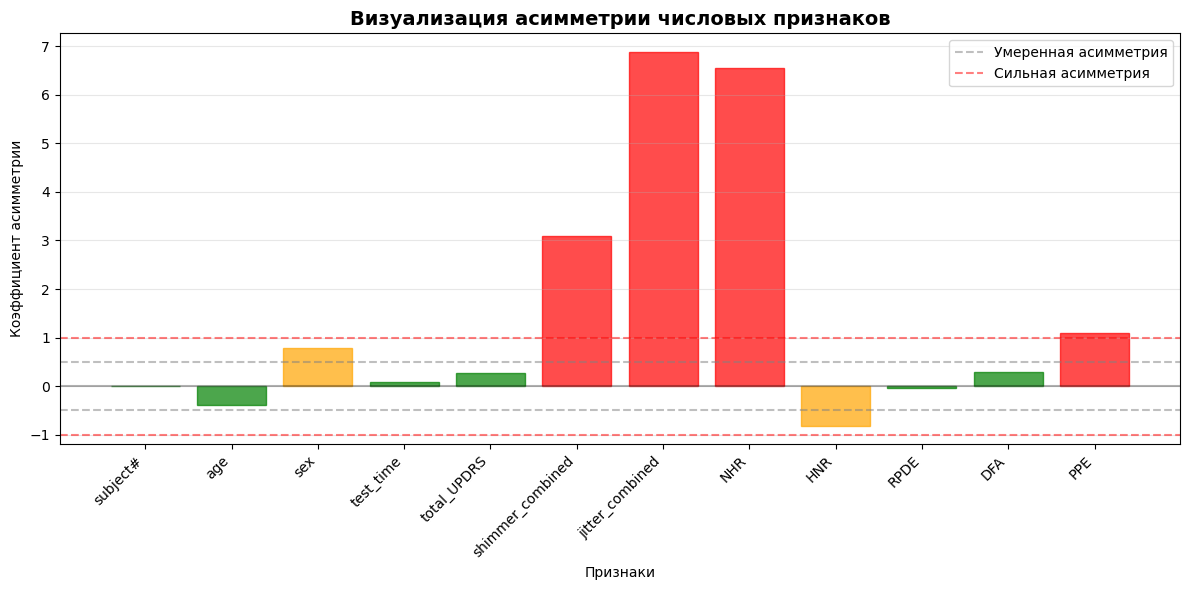


=== Асимметрия и эксцесс (числовые признаки) ===


,Асимметрия,Эксцесс,Рекомендации
subject#,0.002996,-1.249432,Асимметрия в норме\nРавномерное распределение - хорошо
age,-0.379037,0.668864,Асимметрия в норме\nЭксцесс в норме
sex,0.782674,-1.387422,Возможно убрать высокие выбросы\nРавномерное распределение - хорошо
test_time,0.077700,-1.147422,Асимметрия в норме\nРавномерное распределение - хорошо
total_UPDRS,0.270984,-0.356422,Асимметрия в норме\nЭксцесс в норме
shimmer_combined,3.100951,13.267674,Нужно убрать крайне высокие значения\nМного экстремальных значений - проверить выбросы
jitter_combined,6.881709,76.017130,Нужно убрать крайне высокие значения\nМного экстремальных значений - проверить выбросы
NHR,6.547450,52.560390,Нужно убрать крайне высокие значения\nМного экстремальных значений - проверить выбросы
HNR,-0.811850,2.502006,Возможно убрать низкие выбросы\nМного экстремальных значений - проверить выбросы
RPDE,-0.037425,-0.066002,Асимметрия в норме\nЭксцесс в норме


In [271]:
# === Анализ распределений и асимметрии ===
numeric_features = df_combined.select_dtypes(include=[np.number]).columns
skew_kurt = pd.DataFrame({
    "Асимметрия": df_combined[numeric_features].apply(lambda x: skew(x.dropna())),
    "Эксцесс": df_combined[numeric_features].apply(lambda x: kurtosis(x.dropna()))
})

# Добавляем колонку со статусом рекомендаций
def get_skewness_recommendation(skew_val, kurt_val):
    recommendations = []
    
    # Рекомендации по асимметрии
    if skew_val > 1:
        recommendations.append("Нужно убрать крайне высокие значения")
    elif skew_val > 0.5:
        recommendations.append("Возможно убрать высокие выбросы")
    elif skew_val < -1:
        recommendations.append("Нужно убрать крайне низкие значения")
    elif skew_val < -0.5:
        recommendations.append("Возможно убрать низкие выбросы")
    else:
        recommendations.append("Асимметрия в норме")
    
    # Рекомендации по эксцессу
    if kurt_val > 2:
        recommendations.append("Много экстремальных значений - проверить выбросы")
    elif kurt_val > 1:
        recommendations.append("Возможны выбросы по краям")
    elif kurt_val < -1:
        recommendations.append("Равномерное распределение - хорошо")
    else:
        recommendations.append("Эксцесс в норме")
    
    return "\n".join(recommendations)

skew_kurt["Рекомендации"] = skew_kurt.apply(
    lambda row: get_skewness_recommendation(row["Асимметрия"], row["Эксцесс"]), 
    axis=1
)

# Настраиваем отображение для полного показа текста
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)



# Визуализация асимметрии на графике
plt.figure(figsize=(12, 6))
bars = plt.bar(skew_kurt.index, skew_kurt['Асимметрия'], color='skyblue', edgecolor='navy', alpha=0.7)

# Добавляем цветовую индикацию для асимметрии
for bar, skew_val in zip(bars, skew_kurt['Асимметрия']):
    if abs(skew_val) > 1:  # Сильная асимметрия
        bar.set_color('red')
    elif abs(skew_val) > 0.5:  # Умеренная асимметрия
        bar.set_color('orange')
    else:  # Слабая асимметрия
        bar.set_color('green')

plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Умеренная асимметрия')
plt.axhline(y=-0.5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Сильная асимметрия')
plt.axhline(y=-1, color='red', linestyle='--', alpha=0.5)

plt.title('Визуализация асимметрии числовых признаков', fontsize=14, fontweight='bold')
plt.xlabel('Признаки')
plt.ylabel('Коэффициент асимметрии')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Асимметрия и эксцесс (числовые признаки) ===")

display(skew_kurt)

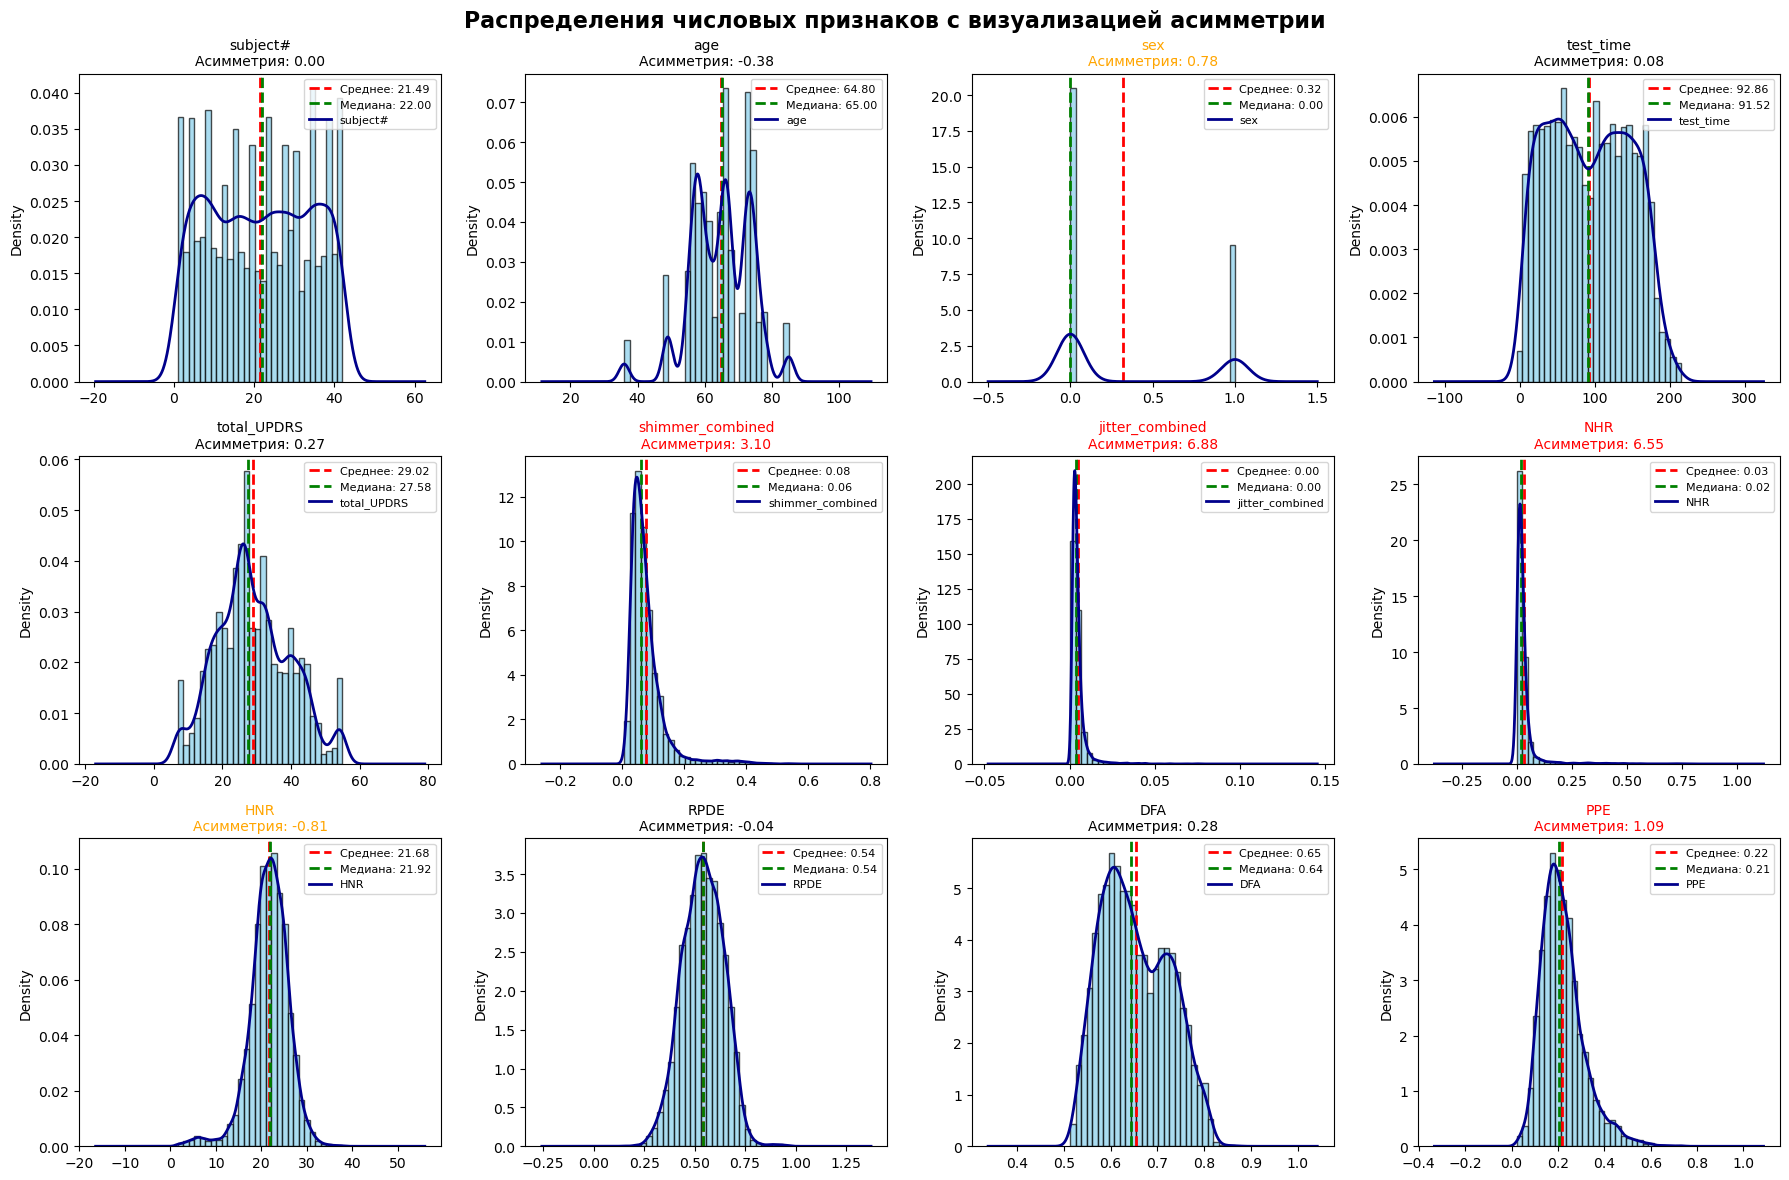

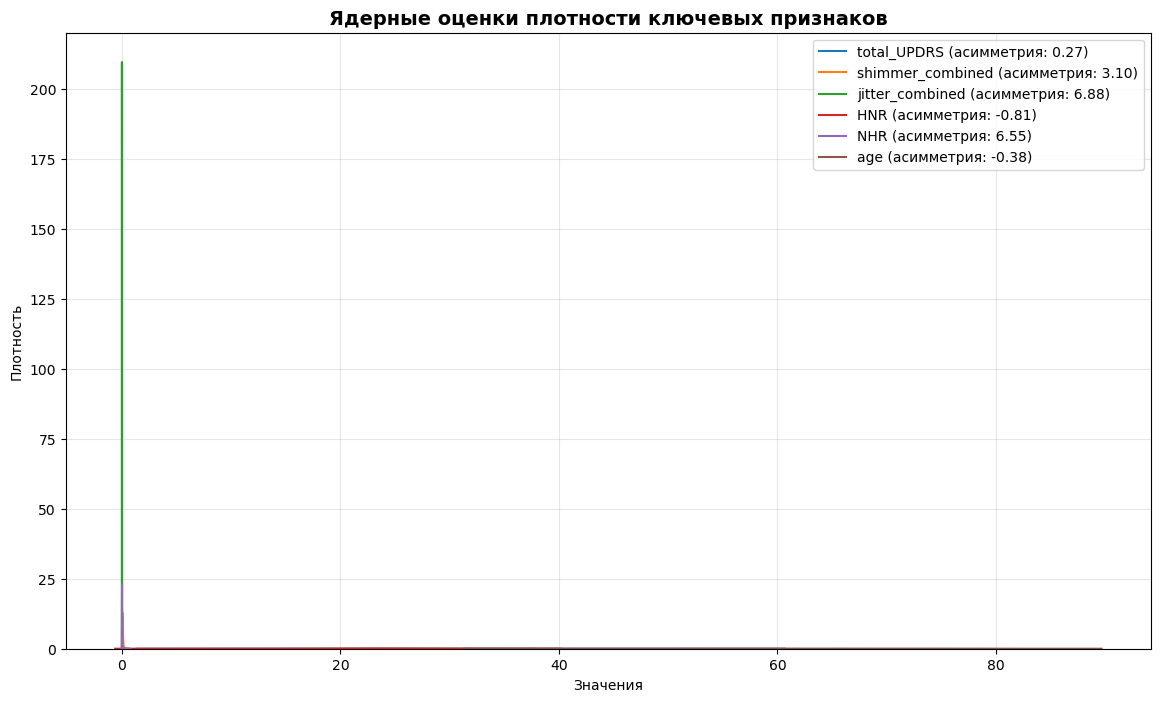


=== Сводка по асимметрии ===
Признаки с СИЛЬНОЙ асимметрией (> |1|):
shimmer_combined    3.100951
jitter_combined     6.881709
NHR                 6.547450
PPE                 1.090540
Name: Асимметрия, dtype: float64

Признаки с УМЕРЕННОЙ асимметрией (0.5 < |x| ≤ 1):
sex    0.782674
HNR   -0.811850
Name: Асимметрия, dtype: float64

Признаки с нормальным распределением (асимметрия ≤ |0.5|): 6


In [272]:
# Гистограммы с линиями асимметрии
n_cols = 4
n_rows = (len(numeric_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    if i < len(axes):
        # Гистограмма
        axes[i].hist(df_combined[col].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black', density=True)
        
        # Линия среднего
        mean_val = df_combined[col].mean()
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
        
        # Линия медианы
        median_val = df_combined[col].median()
        axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_val:.2f}')
        
        # KDE
        df_combined[col].dropna().plot.density(ax=axes[i], color='darkblue', linewidth=2)
        
        skew_val = skew_kurt.loc[col, 'Асимметрия']
        axes[i].set_title(f'{col}\nАсимметрия: {skew_val:.2f}', fontsize=10)
        axes[i].legend(fontsize=8)
        
        # Цвет заголовка в зависимости от асимметрии
        if abs(skew_val) > 1:
            axes[i].title.set_color('red')
        elif abs(skew_val) > 0.5:
            axes[i].title.set_color('orange')

# Скрываем пустые subplots
for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Распределения числовых признаков с визуализацией асимметрии", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Ядерные оценки плотности для ключевых признаков
key_features = ['total_UPDRS', 'shimmer_combined', 'jitter_combined', 'HNR', 'NHR', 'age']
plt.figure(figsize=(14, 8))
for col in key_features:
    if col in df_combined.columns:
        sns.kdeplot(df_combined[col].dropna(), label=f'{col} (асимметрия: {skew_kurt.loc[col, "Асимметрия"]:.2f})')
plt.title("Ядерные оценки плотности ключевых признаков", fontsize=14, fontweight='bold')
plt.xlabel("Значения")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Сводка по асимметрии
print("\n=== Сводка по асимметрии ===")
strong_skew = skew_kurt[abs(skew_kurt['Асимметрия']) > 1]
moderate_skew = skew_kurt[(abs(skew_kurt['Асимметрия']) > 0.5) & (abs(skew_kurt['Асимметрия']) <= 1)]

if not strong_skew.empty:
    print("Признаки с СИЛЬНОЙ асимметрией (> |1|):")
    print(strong_skew['Асимметрия'])
    
if not moderate_skew.empty:
    print("\nПризнаки с УМЕРЕННОЙ асимметрией (0.5 < |x| ≤ 1):")
    print(moderate_skew['Асимметрия'])

normal_skew = skew_kurt[abs(skew_kurt['Асимметрия']) <= 0.5]
if not normal_skew.empty:
    print(f"\nПризнаки с нормальным распределением (асимметрия ≤ |0.5|): {len(normal_skew)}")

## Асимметрия (Skewness) - "Перекос распределения"

### Что это значит:

**Асимметрия ≈ 0 (от -0.5 до +0.5):**
- Данные распределены симметрично - как идеальная горка с равными склонами

**Асимметрия > +0.5 (положительная):**
- Данные сдвинуты влево - большинство значений низкие, но есть несколько очень высоких "выбросов"
- ▶️ **Что делать:** Возможно, нужно убрать крайне высокие значения

**Асимметрия < -0.5 (отрицательная):**
- Данные сдвинуты вправо - большинство значений высокие, но есть несколько очень низких "выбросов"
- ▶️ **Что делать:** Возможно, нужно убрать крайне низкие значения

## Эксцесс (Kurtosis) - "Острота пика"

### Что это значит:

**Эксцесс ≈ 0:**
- Нормальная "колоколообразная" кривая - стандартное распределение

**Эксцесс > 0 (положительный):**
- "Острый пик" с тяжелыми хвостами - данные сильно сконцентрированы в центре, но есть экстремальные значения по краям
- ▶️ **Что делать:** Много выбросов - нужно проверить крайние значения

**Эксцесс < 0 (отрицательный):**
- "Плоский пик" с легкими хвостами - данные равномерно распределены, мало экстремальных значений
- ▶️ **Что делать:** Обычно это хорошо - данные стабильны

In [273]:
# === Обнаружение выбросов методом IQR ===
print("\n=== Обнаружение выбросов (метод IQR) ===")
outlier_summary = []

features_to_check = [
    'subject#', 'age', 'sex', 'test_time', 'total_UPDRS',
    'shimmer_combined', 'jitter_combined', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE'
]

for col in features_to_check:
    Q1 = df_combined[col].quantile(0.25)
    Q3 = df_combined[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_combined[col] < lower) | (df_combined[col] > upper)).sum()
    total_rows = len(df_combined)
    outlier_percentage = (n_outliers / total_rows) * 100
    
    # Определяем уровень проблемы
    if outlier_percentage > 20:
        status = "🚨 КРИТИЧЕСКИЙ УРОВЕНЬ"
        recommendation = "Требуется winsorizing/удаление выбросов"
    elif outlier_percentage > 10:
        status = "⚠️ ВЫСОКИЙ УРОВЕНЬ"
        recommendation = "Рекомендуется обработка выбросов"
    elif outlier_percentage > 5:
        status = "🔶 УМЕРЕННЫЙ УРОВЕНЬ"
        recommendation = "Рассмотреть обработку выбросов"
    else:
        status = "✅ НОРМА"
        recommendation = "Обработка не требуется"
    
    outlier_summary.append({
        'Признак': col,
        'Кол-во выбросов': n_outliers,
        '% выбросов': f"{outlier_percentage:.1f}%",
        'Статус': status,
        'Рекомендация': recommendation,
        'Границы IQR': f"[{lower:.2f}, {upper:.2f}]"
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.sort_values("Кол-во выбросов", ascending=False))


=== Обнаружение выбросов (метод IQR) ===


,Признак,Кол-во выбросов,% выбросов,Статус,Рекомендация,Границы IQR
7,NHR,436,7.4%,🔶 УМЕРЕННЫЙ УРОВЕНЬ,Рассмотреть обработку выбросов,"[-0.02, 0.06]"
6,jitter_combined,419,7.1%,🔶 УМЕРЕННЫЙ УРОВЕНЬ,Рассмотреть обработку выбросов,"[-0.00, 0.01]"
5,shimmer_combined,327,5.6%,🔶 УМЕРЕННЫЙ УРОВЕНЬ,Рассмотреть обработку выбросов,"[-0.03, 0.16]"
11,PPE,206,3.5%,✅ НОРМА,Обработка не требуется,"[-0.01, 0.43]"
8,HNR,171,2.9%,✅ НОРМА,Обработка не требуется,"[11.85, 32.00]"
1,age,101,1.7%,✅ НОРМА,Обработка не требуется,"[37.00, 93.00]"
9,RPDE,26,0.4%,✅ НОРМА,Обработка не требуется,"[0.25, 0.83]"
0,subject#,0,0.0%,✅ НОРМА,Обработка не требуется,"[-24.50, 67.50]"
2,sex,0,0.0%,✅ НОРМА,Обработка не требуется,"[-1.50, 2.50]"
3,test_time,0,0.0%,✅ НОРМА,Обработка не требуется,"[-90.55, 275.84]"


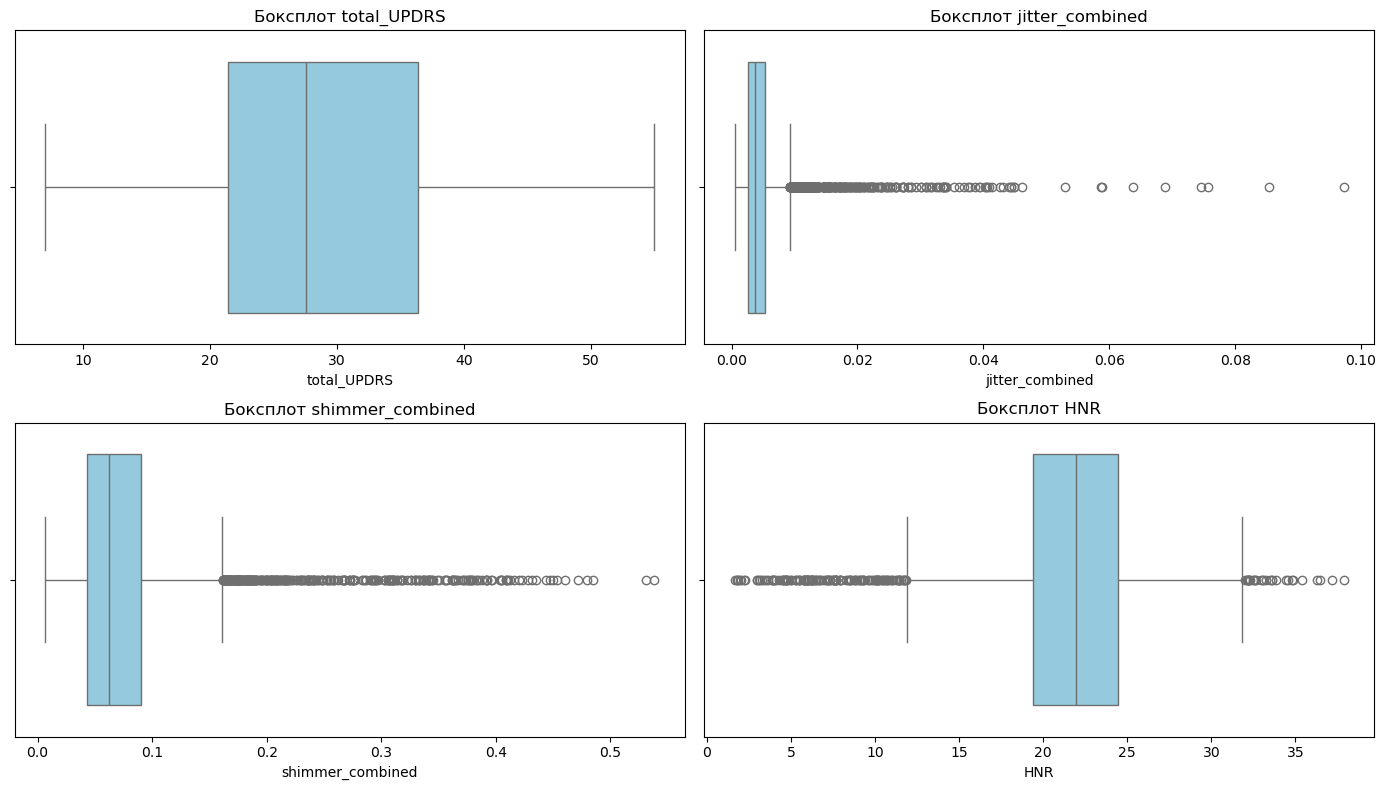

In [274]:
# Боксплоты для выбранных признаков из df_combined
plt.figure(figsize=(14, 8))
features_for_boxplot = ['total_UPDRS', 'jitter_combined', 'shimmer_combined', 'HNR']
for i, col in enumerate(features_for_boxplot):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df_combined[col], color="skyblue")
    plt.title(f"Боксплот {col}")
plt.tight_layout()
plt.show()

### total_UPDRS ✅
Распределение: Сбалансированное, нормальное - Целевая переменная хорошо распределена

### jitter_combined 🚨
Сильно смещено вправо -ОЧЕНЬ МНОГО - подтверждает наш IQR анализ (419 выбросов). 
Проблема: Большинство значений сконцентрировано внизу, но есть экстремальные выбросы. 
Заключение: Требуется срочная обработка winsorizing

### shimmer_combined 🚨
Распределение: Аналогично jitter - сильно смещено вправо -МНОГО - подтверждает 327 выбросов из IQR
Проблема: Та же картина - компактное ядро + длинный хвост выбросов
Заключение: Необходима обработка winsorizing

### HNR ⚠️
Распределение: Более сбалансированное, но с выбросами
Выбросы: Умеренное количество (подтверждает 171 выброс)
Медиана: ~20-25 единиц
Особенность: Выбросы в основном в нижней части
Заключение: Рекомендуется обработка

НЕОБХОДИМЫЕ ДЕЙСТВИЯ:

1. СРОЧНО: Применить winsorizing к:
   - jitter_combined (критический уровень)
   - shimmer_combined (критический уровень)

2. РЕКОМЕНДУЕТСЯ: Обработать HNR

3. БЕЗ ИЗМЕНЕНИЙ: total_UPDRS в отличном состоянии

📌 Почему это важно: Выбросы в jitter и shimmer могут доминировать 
   в обучении модели и искажать результаты!
""")

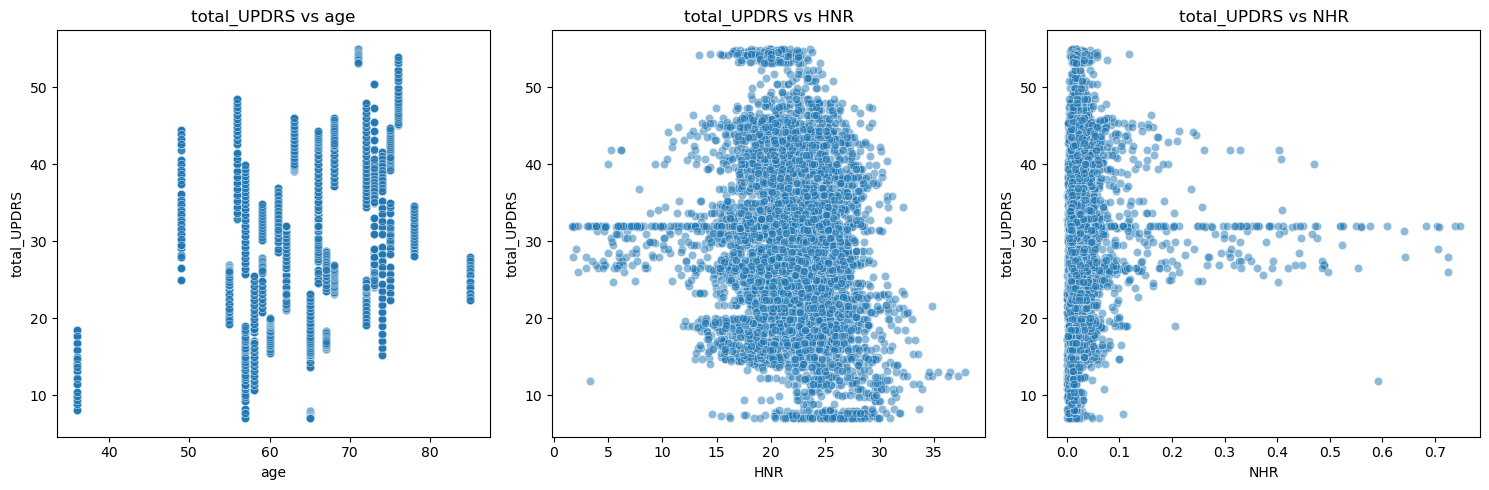

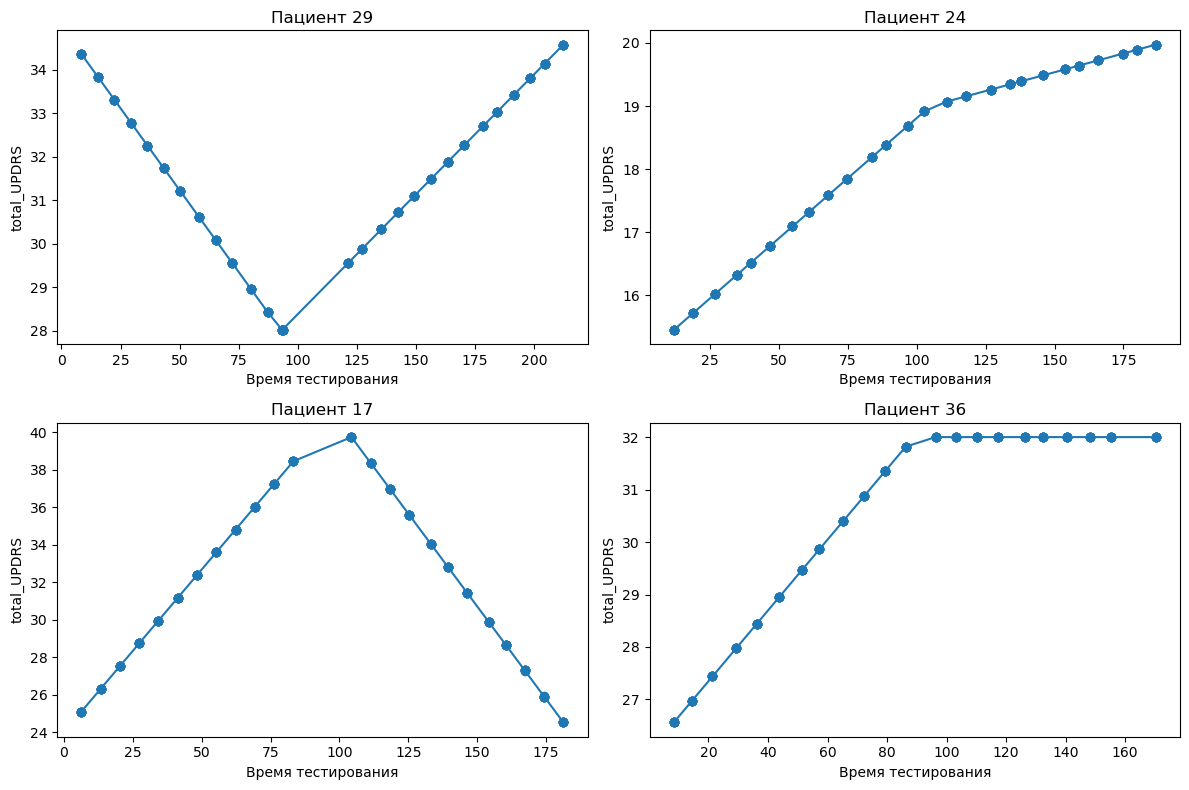

In [143]:
# === Диаграммы рассеяния: целевая переменная vs выбранные признаки ===
top_features = ['age', 'HNR', 'NHR']
plt.figure(figsize=(15, 5))
for i, feat in enumerate(top_features):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=df_combined[feat], y=df_combined['total_UPDRS'], alpha=0.5)
    plt.title(f'total_UPDRS vs {feat}')
plt.tight_layout()
plt.show()

# === Временные тренды для нескольких пациентов ===
subject_sample = np.random.choice(df_combined['subject#'].unique(), 4, replace=False)
plt.figure(figsize=(12, 8))
for i, subject in enumerate(subject_sample):
    subject_data = df_combined[df_combined['subject#'] == subject].sort_values('test_time')
    plt.subplot(2, 2, i+1)
    plt.plot(subject_data['test_time'], subject_data['total_UPDRS'], marker='o', linestyle='-')
    plt.title(f'Пациент {subject}', fontsize=12)
    plt.xlabel('Время тестирования')
    plt.ylabel('total_UPDRS')
plt.tight_layout()
plt.show()


📈 ОБЩАЯ КАРТИНА:
   - Ни один признак не показывает сильной линейной связи с UPDRS
   - Это подтверждает необходимость сложных моделей (LSTM/MLP)
   - Взаимодействия признаков могут быть важнее индивидуальных связей

# Этап B. Подготовка данных

In [291]:
print("=" * 80)
print("B. ПОДГОТОВКА ДАННЫХ - TWO DATASET APPROACH")
print("=" * 80)

# Создаем две рабочие копии для разных версий
df_full = df.copy()  # For versions 1 & 2
df_reduced = df_combined.copy()  # For versions 3 & 4

print("📊 ИСХОДНЫЕ ДАТАСЕТЫ:")
print(f"df_full: {df_full.shape}")
print(f"df_reduced: {df_reduced.shape}")

print("\nB.1 УДАЛЕНИЕ СТОЛБЦОВ")
print("-" * 40)

columns_to_remove = ['motor_UPDRS', 'index', 'subject#', 'Unnamed: 0']

for df_name, dataset in [('df_full', df_full), ('df_reduced', df_reduced)]:
    print(f"\nОбработка {df_name}:")
    original_shape = dataset.shape
    for col in columns_to_remove:
        if col in dataset.columns:
            dataset.drop(col, axis=1, inplace=True)
            print(f"  ✅ Удален '{col}'")
    print(f"  Размер: {original_shape} → {dataset.shape}")

B. ПОДГОТОВКА ДАННЫХ - TWO DATASET APPROACH
📊 ИСХОДНЫЕ ДАТАСЕТЫ:
df_full: (5875, 21)
df_reduced: (5875, 12)

B.1 УДАЛЕНИЕ СТОЛБЦОВ
----------------------------------------

Обработка df_full:
  ✅ Удален 'subject#'
  Размер: (5875, 21) → (5875, 20)

Обработка df_reduced:
  ✅ Удален 'subject#'
  Размер: (5875, 12) → (5875, 11)



B.2 АНАЛИЗ F-SCORE (SELECTKBEST)
----------------------------------------

📊 АНАЛИЗ F-SCORE ДЛЯ df_full:

📊 АНАЛИЗ F-SCORE ДЛЯ df_reduced:


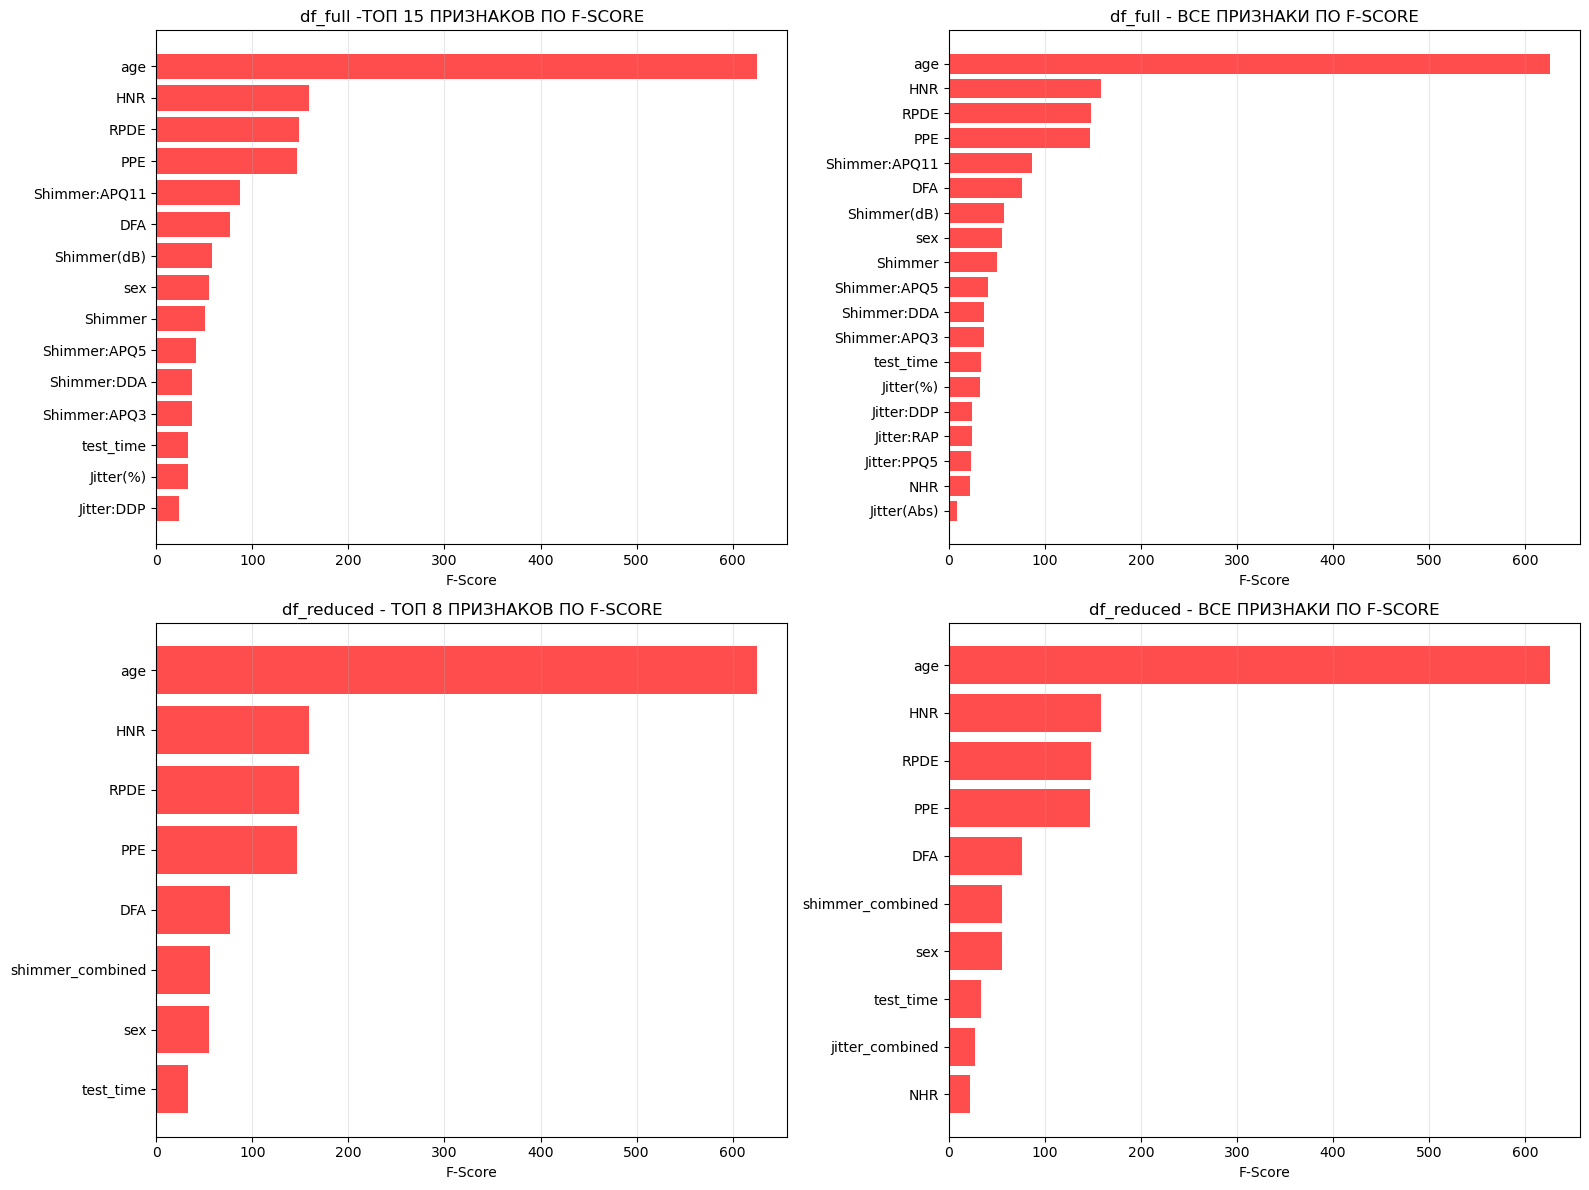

In [292]:
print("\nB.2 АНАЛИЗ F-SCORE (SELECTKBEST)")
print("-" * 40)

def analyze_feature_importance(df, df_name):
    """Анализирует важность признаков с помощью SelectKBest"""
    print(f"\n📊 АНАЛИЗ F-SCORE ДЛЯ {df_name}:")
    
    # Подготовка данных
    X = df.drop('total_UPDRS', axis=1)
    y = df['total_UPDRS']
    
    # Кодируем категориальные признаки
    if 'sex' in X.columns and X['sex'].dtype == 'object':
        X['sex'] = X['sex'].astype('category').cat.codes
    
    # Заполняем пропущенные значения медианой для анализа
    if X.isnull().sum().sum() > 0:
        X_filled = X.fillna(X.median())
    else:
        X_filled = X.copy()
    
    # Применяем SelectKBest
    k_best = SelectKBest(score_func=f_regression, k='all')
    k_best.fit(X_filled, y)
    
    # Создаем DataFrame с результатами
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'F_Score': k_best.scores_,
        'P_Value': k_best.pvalues_
    }).sort_values('F_Score', ascending=False)
    
    return feature_importance

# Анализируем оба датасета
feature_importance_full = analyze_feature_importance(df_full, 'df_full')
feature_importance_reduced = analyze_feature_importance(df_reduced, 'df_reduced')

# Визуализация F-Score для обоих датасетов
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# df_full - Top features
top_full = feature_importance_full.head(15)
colors_full = ['red' if pval < 0.05 else 'blue' for pval in top_full['P_Value']]
axes[0, 0].barh(top_full['Feature'], top_full['F_Score'], color=colors_full, alpha=0.7)
axes[0, 0].set_title('df_full -ТОП 15 ПРИЗНАКОВ ПО F-SCORE')
axes[0, 0].set_xlabel('F-Score')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# df_full - Все признаки
all_full = feature_importance_full.sort_values('F_Score', ascending=True)
colors_all_full = ['red' if pval < 0.05 else 'blue' for pval in all_full['P_Value']]
axes[0, 1].barh(all_full['Feature'], all_full['F_Score'], color=colors_all_full, alpha=0.7)
axes[0, 1].set_title('df_full - ВСЕ ПРИЗНАКИ ПО F-SCORE')
axes[0, 1].set_xlabel('F-Score')
axes[0, 1].grid(axis='x', alpha=0.3)

# df_reduced - Top features
top_reduced = feature_importance_reduced.head(8)
colors_reduced = ['red' if pval < 0.05 else 'blue' for pval in top_reduced['P_Value']]
axes[1, 0].barh(top_reduced['Feature'], top_reduced['F_Score'], color=colors_reduced, alpha=0.7)
axes[1, 0].set_title('df_reduced - ТОП 8 ПРИЗНАКОВ ПО F-SCORE')
axes[1, 0].set_xlabel('F-Score')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# df_reduced - Все признаки
all_reduced = feature_importance_reduced.sort_values('F_Score', ascending=True)
colors_all_reduced = ['red' if pval < 0.05 else 'blue' for pval in all_reduced['P_Value']]
axes[1, 1].barh(all_reduced['Feature'], all_reduced['F_Score'], color=colors_all_reduced, alpha=0.7)
axes[1, 1].set_title('df_reduced - ВСЕ ПРИЗНАКИ ПО F-SCORE')
axes[1, 1].set_xlabel('F-Score')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [293]:
print("\n📈 ПОЛНЫЕ РЕЗУЛЬТАТЫ F-SCORE:")
print("=" * 60)

print("\ndf_full - ВСЕ ПРИЗНАКИ:")
print("-" * 40)
for i, (_, row) in enumerate(feature_importance_full.iterrows(), 1):
    significance = "✅ значим" if row['P_Value'] < 0.05 else "⚠️ незначим"
    print(f"{i:2d}. {row['Feature']:25} F-score = {row['F_Score']:7.1f} p-value = {row['P_Value']:8.4f} ({significance})")

print("\ndf_reduced - ВСЕ ПРИЗНАКИ:")
print("-" * 40)
for i, (_, row) in enumerate(feature_importance_reduced.iterrows(), 1):
    significance = "✅ значим" if row['P_Value'] < 0.05 else "⚠️ незначим"
    print(f"{i:2d}. {row['Feature']:25} F-score = {row['F_Score']:7.1f} p-value = {row['P_Value']:8.4f} ({significance})")


📈 ПОЛНЫЕ РЕЗУЛЬТАТЫ F-SCORE:

df_full - ВСЕ ПРИЗНАКИ:
----------------------------------------
 1. age                       F-score =   625.7 p-value =   0.0000 (✅ значим)
 2. HNR                       F-score =   158.5 p-value =   0.0000 (✅ значим)
 3. RPDE                      F-score =   148.2 p-value =   0.0000 (✅ значим)
 4. PPE                       F-score =   146.9 p-value =   0.0000 (✅ значим)
 5. Shimmer:APQ11             F-score =    87.0 p-value =   0.0000 (✅ значим)
 6. DFA                       F-score =    76.6 p-value =   0.0000 (✅ значим)
 7. Shimmer(dB)               F-score =    57.9 p-value =   0.0000 (✅ значим)
 8. sex                       F-score =    55.3 p-value =   0.0000 (✅ значим)
 9. Shimmer                   F-score =    50.3 p-value =   0.0000 (✅ значим)
10. Shimmer:APQ5              F-score =    41.2 p-value =   0.0000 (✅ значим)
11. Shimmer:DDA               F-score =    37.2 p-value =   0.0000 (✅ значим)
12. Shimmer:APQ3              F-score =    37.

In [295]:
print("\nB.3 АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ И РЕЛЕВАНТНОСТИ")
print("-" * 40)

def analyze_missing_values(df, df_name, feature_importance):
    """Анализирует пропущенные значения и их релевантность"""
    print(f"\n🔍 АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ДЛЯ {df_name}:")
    
    # Анализ пропущенных значений
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0]
    
    if len(missing_data) == 0:
        print("  ✅ Пропущенных значений не обнаружено")
        return
    
    print("  Обнаружены пропущенные значения:")
    for col, missing_count in missing_data.items():
        missing_percent = (missing_count / len(df)) * 100
        
        # Проверяем релевантность признака
        if col in feature_importance['Feature'].values:
            f_score = feature_importance[feature_importance['Feature'] == col]['F_Score'].values[0]
            p_value = feature_importance[feature_importance['Feature'] == col]['P_Value'].values[0]
            relevance = "✅ ВЫСОКАЯ" if f_score > 10 else "⚠️ СРЕДНЯЯ" if f_score > 5 else "❌ НИЗКАЯ"
        else:
            f_score = 0
            p_value = 1
            relevance = "❌ НЕ ОЦЕНЕН"
        
        print(f"    {col}: {missing_count} пропусков ({missing_percent:.1f}%)")
        print(f"      Релевантность: {relevance}, F-score: {f_score:.1f}, p-value: {p_value:.4f}")
        
        # Рекомендации по обработке
        if missing_percent > 20:
            print(f"      🚨 РЕКОМЕНДАЦИЯ: МНОГО ПРОПУСКОВ (>20%) - вероятно MNAR(Missing Not at Random)")
            if relevance == "✅ ВЫСОКАЯ":
                print(f"      💡 ДЕЙСТВИЕ: Использовать продвинутую импутацию (KNN/Regression)")
            else:
                print(f"      💡 ДЕЙСТВИЕ: Рассмотреть удаление признака")
        elif missing_percent > 5:
            print(f"      ⚠️  РЕКОМЕНДАЦИЯ: УМЕРЕННО ПРОПУСКОВ (5-20%) - вероятно MAR(Missing at Random)")
            print(f"      💡 ДЕЙСТВИЕ: Использовать KNN импутацию")
        else:
            print(f"      ✅ РЕКОМЕНДАЦИЯ: МАЛО ПРОПУСКОВ (<5%) - вероятно MCAR(Missing Completely at Random)")
            print(f"      💡 ДЕЙСТВИЕ: Использовать простую импутацию (медиана/среднее)")

# Анализируем пропущенные значения для обоих датасетов
analyze_missing_values(df_full, 'df_full', feature_importance_full)
analyze_missing_values(df_reduced, 'df_reduced', feature_importance_reduced)


B.3 АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ И РЕЛЕВАНТНОСТИ
----------------------------------------

🔍 АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ДЛЯ df_full:
  Обнаружены пропущенные значения:
    Jitter(Abs): 2931 пропусков (49.9%)
      Релевантность: ⚠️ СРЕДНЯЯ, F-score: 8.7, p-value: 0.0032
      🚨 РЕКОМЕНДАЦИЯ: МНОГО ПРОПУСКОВ (>20%) - вероятно MNAR(Missing Not at Random)
      💡 ДЕЙСТВИЕ: Рассмотреть удаление признака

🔍 АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ДЛЯ df_reduced:
  ✅ Пропущенных значений не обнаружено


In [296]:
if 'Jitter(Abs)' in df_full.columns:
    df_full = df_full.drop('Jitter(Abs)', axis=1)
    print("✅ Jitter(Abs) удален из df_full (49.9% пропусков)")

✅ Jitter(Abs) удален из df_full (49.9% пропусков)


In [297]:
print("\nB.4 ОБРАБОТКА ВЫБРОСОВ (WINSORIZE)")
print("-" * 40)

def apply_winsorizing(df, df_name):
    """Применяет winsorizing к числовым признакам"""
    print(f"\n🔧 WINSORIZING ДЛЯ {df_name}:")
    
    # Выбираем только числовые признаки (исключая целевую и категориальные)
    numeric_features = df.select_dtypes(include=[np.number]).columns
    numeric_features = [col for col in numeric_features if col != 'total_UPDRS' and col != 'sex']
    
    for feature in numeric_features:
        original_skew = df[feature].skew()
        # Winsorize верхние и нижние 2%
        df[feature] = winsorize(df[feature], limits=[0.02, 0.02])
        new_skew = df[feature].skew()
        
        if abs(original_skew - new_skew) > 0.5:  # Если асимметрия значительно улучшилась
            print(f"  ✅ {feature}: асимметрия {original_skew:.2f} → {new_skew:.2f}")

# Применяем winsorizing к обоим датасетам
apply_winsorizing(df_full, 'df_full')
apply_winsorizing(df_reduced, 'df_reduced')


B.4 ОБРАБОТКА ВЫБРОСОВ (WINSORIZE)
----------------------------------------

🔧 WINSORIZING ДЛЯ df_full:
  ✅ Jitter(%): асимметрия 6.45 → 2.28
  ✅ Jitter:RAP: асимметрия 6.95 → 2.32
  ✅ Jitter:PPQ5: асимметрия 7.59 → 2.43
  ✅ Jitter:DDP: асимметрия 6.95 → 2.31
  ✅ Shimmer: асимметрия 3.31 → 2.21
  ✅ Shimmer(dB): асимметрия 3.10 → 2.21
  ✅ Shimmer:APQ3: асимметрия 3.10 → 1.89
  ✅ Shimmer:APQ5: асимметрия 3.70 → 2.20
  ✅ Shimmer:APQ11: асимметрия 3.41 → 1.92
  ✅ Shimmer:DDA: асимметрия 3.10 → 1.89
  ✅ NHR: асимметрия 6.55 → 3.50

🔧 WINSORIZING ДЛЯ df_reduced:
  ✅ shimmer_combined: асимметрия 3.10 → 2.12
  ✅ jitter_combined: асимметрия 6.88 → 2.38
  ✅ NHR: асимметрия 6.55 → 3.50


In [298]:
print("\nB.5 ПРОВЕРКА МУЛЬТИКОЛЛИНЕАРНОСТИ")
print("-" * 40)

def check_multicollinearity(df, df_name):
    """Проверяет мультиколлинеарность после обработки"""
    print(f"\n🔍 ПРОВЕРКА МУЛЬТИКОЛЛИНЕАРНОСТИ ДЛЯ {df_name}:")
    
    # Удаляем целевую переменную для анализа
    X = df.drop('total_UPDRS', axis=1)
    
    # УДАЛЯЕМ Jitter(Abs) из df_full как рекомендовано
    if df_name == 'df_full' and 'Jitter(Abs)' in X.columns:
        X = X.drop('Jitter(Abs)', axis=1)
        print("✅ Jitter(Abs) удален из анализа (49.9% пропусков)")
    
    # Вычисляем корреляционную матрицу
    corr_matrix = X.corr().abs()
    
    # Находим высококоррелированные пары
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > 0.8:  # Порог 0.8 для сильной корреляции
                col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
                corr_value = corr_matrix.iloc[i, j]
                high_corr_pairs.append((col1, col2, corr_value))
    
    # Сортируем по силе корреляции
    high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
    
    if high_corr_pairs:
        print(f"🚨 Обнаружено {len(high_corr_pairs)} высококоррелированных пар (corr > 0.8):")
        for col1, col2, corr_value in high_corr_pairs:
            print(f"  {col1} - {col2}: {corr_value:.3f}")
    else:
        print("✅ Высококоррелированных пар не обнаружено (corr < 0.8)")
    
    return high_corr_pairs

# Проверяем мультиколлинеарность для обоих датасетов
multicollinearity_full = check_multicollinearity(df_full, 'df_full')
multicollinearity_reduced = check_multicollinearity(df_reduced, 'df_reduced')


B.5 ПРОВЕРКА МУЛЬТИКОЛЛИНЕАРНОСТИ
----------------------------------------

🔍 ПРОВЕРКА МУЛЬТИКОЛЛИНЕАРНОСТИ ДЛЯ df_full:
🚨 Обнаружено 23 высококоррелированных пар (corr > 0.8):
  Shimmer:APQ3 - Shimmer:DDA: 1.000
  Jitter:RAP - Jitter:DDP: 1.000
  Shimmer - Shimmer(dB): 0.991
  Shimmer - Shimmer:APQ5: 0.990
  Shimmer - Shimmer:APQ3: 0.983
  Shimmer - Shimmer:DDA: 0.983
  Shimmer(dB) - Shimmer:APQ5: 0.981
  Jitter(%) - Jitter:DDP: 0.977
  Jitter(%) - Jitter:RAP: 0.977
  Jitter(%) - Jitter:PPQ5: 0.974
  Shimmer:APQ5 - Shimmer:DDA: 0.974
  Shimmer:APQ3 - Shimmer:APQ5: 0.974
  Shimmer(dB) - Shimmer:APQ3: 0.969
  Shimmer(dB) - Shimmer:DDA: 0.969
  Jitter:RAP - Jitter:PPQ5: 0.963
  Jitter:PPQ5 - Jitter:DDP: 0.963
  Shimmer:APQ5 - Shimmer:APQ11: 0.960
  Shimmer - Shimmer:APQ11: 0.955
  Shimmer(dB) - Shimmer:APQ11: 0.952
  Shimmer:APQ11 - Shimmer:DDA: 0.913
  Shimmer:APQ3 - Shimmer:APQ11: 0.913
  Jitter(%) - PPE: 0.828
  Jitter:PPQ5 - PPE: 0.823

🔍 ПРОВЕРКА МУЛЬТИКОЛЛИНЕАРНОСТИ ДЛЯ df_reduced

In [299]:
print("\nB.6 РАЗДЕЛЕНИЕ НА ВЫБОРКИ")
print("-" * 40)

def create_train_val_test_splits(df, test_size=0.2, val_size=0.2, random_state=42):
    """Создает разделенные выборки"""
    X = df.drop('total_UPDRS', axis=1)
    y = df['total_UPDRS']
    
    # Первое разделение: временная и тестовая
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, shuffle=True
    )
    
    # Второе разделение: обучающая и валидационная
    val_relative_size = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_relative_size, random_state=random_state, shuffle=True
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Создаем разделенные выборки для обоих датасетов
print("Создание разделенных выборок...")

X_train_full, X_val_full, X_test_full, y_train_full, y_val_full, y_test_full = create_train_val_test_splits(df_full)
X_train_red, X_val_red, X_test_red, y_train_red, y_val_red, y_test_red = create_train_val_test_splits(df_reduced)

print("✅ Разделенные выборки созданы:")
print(f"  df_full: train={X_train_full.shape[0]}, val={X_val_full.shape[0]}, test={X_test_full.shape[0]}")
print(f"  df_reduced: train={X_train_red.shape[0]}, val={X_val_red.shape[0]}, test={X_test_red.shape[0]}")


B.6 РАЗДЕЛЕНИЕ НА ВЫБОРКИ
----------------------------------------
Создание разделенных выборок...
✅ Разделенные выборки созданы:
  df_full: train=3525, val=1175, test=1175
  df_reduced: train=3525, val=1175, test=1175


In [300]:
print("\nB.7 ПРОВЕРКА НА ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ")
print("-" * 40)

# Проверяем, что все пропуски устранены
print("Проверка пропущенных значений в выборках:")

print(f"\ndf_full:")
print(f"  X_train: {X_train_full.isnull().sum().sum()} пропусков")
print(f"  X_val: {X_val_full.isnull().sum().sum()} пропусков")
print(f"  X_test: {X_test_full.isnull().sum().sum()} пропусков")

print(f"\ndf_reduced:")
print(f"  X_train: {X_train_red.isnull().sum().sum()} пропусков")
print(f"  X_val: {X_val_red.isnull().sum().sum()} пропусков")
print(f"  X_test: {X_test_red.isnull().sum().sum()} пропусков")


B.7 ПРОВЕРКА НА ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ
----------------------------------------
Проверка пропущенных значений в выборках:

df_full:
  X_train: 0 пропусков
  X_val: 0 пропусков
  X_test: 0 пропусков

df_reduced:
  X_train: 0 пропусков
  X_val: 0 пропусков
  X_test: 0 пропусков


In [301]:
# Подготавливаем данные для B.8 (просто переименовываем переменные)
X_train_full_imp = X_train_full
X_val_full_imp = X_val_full
X_test_full_imp = X_test_full

X_train_red_imp = X_train_red
X_val_red_imp = X_val_red
X_test_red_imp = X_test_red

# =============================================================================
# B.8 СОЗДАНИЕ СТАНДАРТИЗИРОВАННЫХ ВЕРСИЙ
# =============================================================================

print("\nB.8 СОЗДАНИЕ СТАНДАРТИЗИРОВАННЫХ ВЕРСИЙ")
print("-" * 40)

def apply_standard_scaling(X_train, X_val, X_test):
    """Применяет стандартизацию"""
    scaler = StandardScaler()
    
    # Fit ТОЛЬКО на обучающих данных
    X_train_scaled = scaler.fit_transform(X_train)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    
    # Transform на валидационных и тестовых данных
    X_val_scaled = scaler.transform(X_val)
    X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
    
    X_test_scaled = scaler.transform(X_test)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

print("Создание 4 вариантов датасетов...")

# 1. Полный набор (без стандартизации)
dataset1 = {
    'X_train': X_train_full_imp, 'X_val': X_val_full_imp, 'X_test': X_test_full_imp,
    'y_train': y_train_full, 'y_val': y_val_full, 'y_test': y_test_full,
    'name': 'Полный набор (без стандартизации)',
    'features': X_train_full_imp.columns.tolist(),
    'source': 'df_full'
}

# 2. Полный набор + стандартизация
X_train_full_std, X_val_full_std, X_test_full_std, scaler_full = apply_standard_scaling(
    X_train_full_imp, X_val_full_imp, X_test_full_imp)
dataset2 = {
    'X_train': X_train_full_std, 'X_val': X_val_full_std, 'X_test': X_test_full_std,
    'y_train': y_train_full, 'y_val': y_val_full, 'y_test': y_test_full,
    'name': 'Полный набор + стандартизация',
    'features': X_train_full_std.columns.tolist(),
    'scaler': scaler_full,
    'source': 'df_full'
}

# 3. Сокращенный набор (без стандартизации)
dataset3 = {
    'X_train': X_train_red_imp, 'X_val': X_val_red_imp, 'X_test': X_test_red_imp,
    'y_train': y_train_red, 'y_val': y_val_red, 'y_test': y_test_red,
    'name': 'Сокращенный набор (без стандартизации)',
    'features': X_train_red_imp.columns.tolist(),
    'source': 'df_reduced'
}

# 4. Сокращенный набор + стандартизация
X_train_red_std, X_val_red_std, X_test_red_std, scaler_red = apply_standard_scaling(
    X_train_red_imp, X_val_red_imp, X_test_red_imp)
dataset4 = {
    'X_train': X_train_red_std, 'X_val': X_val_red_std, 'X_test': X_test_red_std,
    'y_train': y_train_red, 'y_val': y_val_red, 'y_test': y_test_red,
    'name': 'Сокращенный набор + стандартизация',
    'features': X_train_red_std.columns.tolist(),
    'scaler': scaler_red,
    'source': 'df_reduced'
}

# Сохраняем все датасеты
datasets = {
    'full': dataset1,
    'full_std': dataset2, 
    'reduced': dataset3,
    'reduced_std': dataset4
}

print("\n📋 ФИНАЛЬНАЯ СВОДКА:")
for key, dataset in datasets.items():
    print(f"\n{dataset['name']}:")
    print(f"  • Признаков: {len(dataset['features'])}")
    print(f"  • Размеры: train={dataset['X_train'].shape}, val={dataset['X_val'].shape}, test={dataset['X_test'].shape}")
    print(f"  • Признаки: {dataset['features']}")


B.8 СОЗДАНИЕ СТАНДАРТИЗИРОВАННЫХ ВЕРСИЙ
----------------------------------------
Создание 4 вариантов датасетов...

📋 ФИНАЛЬНАЯ СВОДКА:

Полный набор (без стандартизации):
  • Признаков: 18
  • Размеры: train=(3525, 18), val=(1175, 18), test=(1175, 18)
  • Признаки: ['age', 'sex', 'test_time', 'Jitter(%)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

Полный набор + стандартизация:
  • Признаков: 18
  • Размеры: train=(3525, 18), val=(1175, 18), test=(1175, 18)
  • Признаки: ['age', 'sex', 'test_time', 'Jitter(%)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

Сокращенный набор (без стандартизации):
  • Признаков: 10
  • Размеры: train=(3525, 10), val=(1175, 10), test=(1175, 10)
  • Признаки: ['age', 'sex', 'test_time', 'shimmer_combined', '

## B.9 ПОДГОТОВКА ДЛЯ НЕЙРОСЕТЕЙ (MLP, BiLSTM)

Подготовленные данные нейронной сети

In [303]:
def prepare_neural_network_data(datasets):
    """Подготовка всех наборов данных для обучения нейронных сетей"""
    
    print("🔧 Подготовка данных для нейронных сетей...")
    
    for key in datasets.keys():
        dataset = datasets[key]
        
        print(f"\n📊 Обработка набора данных: {dataset['name']}")
        print(f"   Исходные признаки: {len(dataset['features'])}")
        
        # 1. Конвертация в NumPy массивы для MLP
        dataset['X_train_array'] = dataset['X_train'].values.astype('float32')
        dataset['X_val_array'] = dataset['X_val'].values.astype('float32')
        dataset['X_test_array'] = dataset['X_test'].values.astype('float32')
        
        dataset['y_train_array'] = dataset['y_train'].values.astype('float32')
        dataset['y_val_array'] = dataset['y_val'].values.astype('float32')
        dataset['y_test_array'] = dataset['y_test'].values.astype('float32')
        
        # 2. Подготовка для BiLSTM (последовательности)
        # Для BiLSTM рассматриваем каждый вектор признаков как последовательность
        dataset['X_train_lstm'] = dataset['X_train_array'].reshape(
            dataset['X_train_array'].shape[0],
            1,  # длина последовательности
            dataset['X_train_array'].shape[1]  # признаков на временной шаг
        )
        dataset['X_val_lstm'] = dataset['X_val_array'].reshape(
            dataset['X_val_array'].shape[0],
            1,
            dataset['X_val_array'].shape[1]
        )
        dataset['X_test_lstm'] = dataset['X_test_array'].reshape(
            dataset['X_test_array'].shape[0],
            1,
            dataset['X_test_array'].shape[1]
        )
        
        # 3. Вывод форм данных
        print(f"   ✅ Форма массивов для MLP: {dataset['X_train_array'].shape}")
        print(f"   ✅ Форма массивов для BiLSTM: {dataset['X_train_lstm'].shape}")
        print(f"   ✅ Форма целевых переменных: {dataset['y_train_array'].shape}")
        
        # 4. Статистика данных для проверки
        print(f"   📈 Статистика данных:")
        print(f"      Диапазон X_train: [{dataset['X_train_array'].min():.3f}, {dataset['X_train_array'].max():.3f}]")
        print(f"      Диапазон y_train: [{dataset['y_train_array'].min():.3f}, {dataset['y_train_array'].max():.3f}]")
        
        if 'scaler' in dataset:
            print(f"      🔄 Применен StandardScaler")
        
    return datasets


In [304]:
def verify_data_preparation(datasets):
    """Проверка успешности подготовки данных"""
    
    print("\n" + "="*60)
    print("🔍 ПРОВЕРКА ПОДГОТОВКИ ДАННЫХ")
    print("="*60)
    
    verification_passed = True
    
    for key, dataset in datasets.items():
        print(f"\n📋 Набор данных: {dataset['name']}")
        
        # Проверка форм
        shapes_consistent = (
            dataset['X_train_array'].shape[0] == dataset['y_train_array'].shape[0] and
            dataset['X_val_array'].shape[0] == dataset['y_val_array'].shape[0] and
            dataset['X_test_array'].shape[0] == dataset['y_test_array'].shape[0]
        )
        
        # Проверка на NaN значения
        has_nan = (
            np.isnan(dataset['X_train_array']).any() or
            np.isnan(dataset['X_val_array']).any() or
            np.isnan(dataset['X_test_array']).any() or
            np.isnan(dataset['y_train_array']).any() or
            np.isnan(dataset['y_val_array']).any() or
            np.isnan(dataset['y_test_array']).any()
        )
        
        # Проверка типов данных
        correct_dtype = (
            dataset['X_train_array'].dtype == np.float32 and
            dataset['y_train_array'].dtype == np.float32
        )
        
        print(f"   ✅ Формы согласованы: {shapes_consistent}")
        print(f"   ✅ Нет NaN значений: {not has_nan}")
        print(f"   ✅ Правильные типы данных: {correct_dtype}")
        
        if not (shapes_consistent and not has_nan and correct_dtype):
            verification_passed = False
            print(f"   ❌ ОБНАРУЖЕНЫ ПРОБЛЕМЫ В {key}!")
    
    return verification_passed

def create_dataset_summary(datasets):
    """Создание комплексной сводки по подготовленным наборам данных"""
    
    print("\n" + "="*70)
    print("📊 КОМПЛЕКСНАЯ СВОДКА ПО НАБОРАМ ДАННЫХ ДЛЯ НЕЙРОННЫХ СЕТЕЙ")
    print("="*70)
    
    summary_data = []
    
    for key, dataset in datasets.items():
        summary_data.append({
            'Набор данных': dataset['name'],
            'Признаков': len(dataset['features']),
            'Обучающие примеры': dataset['X_train_array'].shape[0],
            'Валидационные примеры': dataset['X_val_array'].shape[0],
            'Тестовые примеры': dataset['X_test_array'].shape[0],
            'Размерность MLP': dataset['X_train_array'].shape[1],
            'Размерность BiLSTM': f"{dataset['X_train_lstm'].shape[1:]}",
            'Стандартизация': 'scaler' in dataset,
            'Список признаков': ', '.join(dataset['features'][:3]) + '...' if len(dataset['features']) > 3 else ', '.join(dataset['features'])
        })
    
    summary_df = pd.DataFrame(summary_data)
    display(summary_df)
    
    return summary_df

In [305]:
# =============================================================================
# ВЫПОЛНЕНИЕ ПОДГОТОВКИ ДАННЫХ
# =============================================================================

print("🚀 Начало подготовки данных для нейронных сетей...")

# Применяем подготовку данных ко всем наборам
datasets = prepare_neural_network_data(datasets)

# Проверяем подготовку
verification_result = verify_data_preparation(datasets)

if verification_result:
    print("\n🎉 ВСЕ ПРОВЕРКИ ПОДГОТОВКИ ДАННЫХ ПРОЙДЕНЫ!")
else:
    print("\n⚠️  ОБНАРУЖЕНЫ ПРОБЛЕМЫ ПРИ ПОДГОТОВКЕ ДАННЫХ!")
    print("   Пожалуйста, проверьте предупреждения выше.")

# Создаем комплексную сводку
dataset_summary = create_dataset_summary(datasets)

🚀 Начало подготовки данных для нейронных сетей...
🔧 Подготовка данных для нейронных сетей...

📊 Обработка набора данных: Полный набор (без стандартизации)
   Исходные признаки: 18
   ✅ Форма массивов для MLP: (3525, 18)
   ✅ Форма массивов для BiLSTM: (3525, 1, 18)
   ✅ Форма целевых переменных: (3525,)
   📈 Статистика данных:
      Диапазон X_train: [0.000, 187.550]
      Диапазон y_train: [7.000, 54.992]

📊 Обработка набора данных: Полный набор + стандартизация
   Исходные признаки: 18
   ✅ Форма массивов для MLP: (3525, 18)
   ✅ Форма массивов для BiLSTM: (3525, 1, 18)
   ✅ Форма целевых переменных: (3525,)
   📈 Статистика данных:
      Диапазон X_train: [-2.877, 5.052]
      Диапазон y_train: [7.000, 54.992]
      🔄 Применен StandardScaler

📊 Обработка набора данных: Сокращенный набор (без стандартизации)
   Исходные признаки: 10
   ✅ Форма массивов для MLP: (3525, 10)
   ✅ Форма массивов для BiLSTM: (3525, 1, 10)
   ✅ Форма целевых переменных: (3525,)
   📈 Статистика данных:
     

,Набор данных,Признаков,Обучающие примеры,Валидационные примеры,Тестовые примеры,Размерность MLP,Размерность BiLSTM,Стандартизация,Список признаков
0,Полный набор (без стандартизации),18,3525,1175,1175,18,"(1, 18)",False,"age, sex, test_time..."
1,Полный набор + стандартизация,18,3525,1175,1175,18,"(1, 18)",True,"age, sex, test_time..."
2,Сокращенный набор (без стандартизации),10,3525,1175,1175,10,"(1, 10)",False,"age, sex, test_time..."
3,Сокращенный набор + стандартизация,10,3525,1175,1175,10,"(1, 10)",True,"age, sex, test_time..."


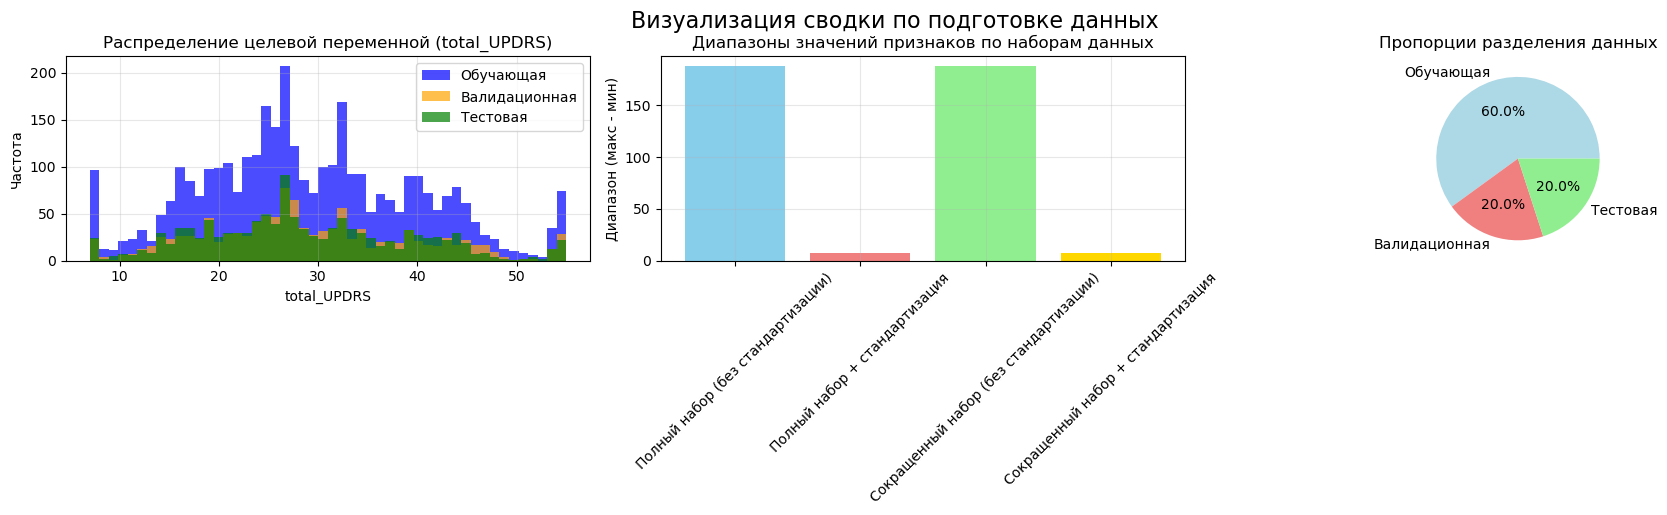

In [311]:

def visualize_prepared_data(datasets):
    """Визуализация распределений подготовленных данных"""
    
    # Графики распределений для первого набора данных
    first_key = list(datasets.keys())[0]
    first_dataset = datasets[first_key]
    
    # Create a single figure with 3 subplots in one row
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Распределение целевой переменной
    axes[0].hist(first_dataset['y_train_array'], bins=50, alpha=0.7, label='Обучающая', color='blue')
    axes[0].hist(first_dataset['y_val_array'], bins=50, alpha=0.7, label='Валидационная', color='orange')
    axes[0].hist(first_dataset['y_test_array'], bins=50, alpha=0.7, label='Тестовая', color='green')
    axes[0].set_title('Распределение целевой переменной (total_UPDRS)')
    axes[0].set_xlabel('total_UPDRS')
    axes[0].set_ylabel('Частота')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # 2. Сравнение диапазонов признаков
    feature_ranges = []
    dataset_names = []
    
    for key, dataset in datasets.items():
        feature_range = np.ptp(dataset['X_train_array'])  # размах (макс-мин)
        feature_ranges.append(feature_range)
        dataset_names.append(dataset['name'])
    
    axes[1].bar(dataset_names, feature_ranges, color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
    axes[1].set_title('Диапазоны значений признаков по наборам данных')
    axes[1].set_ylabel('Диапазон (макс - мин)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(alpha=0.3)
    
    # 3. Пропорции разделения данных
    splits = ['Обучающая', 'Валидационная', 'Тестовая']
    proportions = [
        first_dataset['X_train_array'].shape[0],
        first_dataset['X_val_array'].shape[0], 
        first_dataset['X_test_array'].shape[0]
    ]
    total = sum(proportions)
    percentages = [p/total*100 for p in proportions]
    
    axes[2].pie(percentages, labels=splits, autopct='%1.1f%%', 
                colors=['lightblue', 'lightcoral', 'lightgreen'])
    axes[2].set_title('Пропорции разделения данных')
    
    plt.tight_layout()
    plt.suptitle('Визуализация сводки по подготовке данных', y=1.02, fontsize=16)
    plt.show()

# Генерируем визуализации
visualize_prepared_data(datasets)

In [312]:
# =============================================================================
# ФИНАЛЬНАЯ ПОДГОТОВКА ДЛЯ ОБУЧЕНИЯ МОДЕЛЕЙ
# =============================================================================

print("\nB.9.2 ФИНАЛЬНАЯ ПОДГОТОВКА ДЛЯ ОБУЧЕНИЯ МОДЕЛЕЙ")
print("-" * 50)

# Создаем конфигурации наборов данных для удобного доступа при обучении
dataset_configs = {
    'full': {
        'data': datasets['full'],
        'mlp_input': datasets['full']['X_train_array'],
        'bilstm_input': datasets['full']['X_train_lstm'],
        'name': datasets['full']['name']
    },
    'full_std': {
        'data': datasets['full_std'],
        'mlp_input': datasets['full_std']['X_train_array'],
        'bilstm_input': datasets['full_std']['X_train_lstm'],
        'name': datasets['full_std']['name']
    },
    'reduced': {
        'data': datasets['reduced'],
        'mlp_input': datasets['reduced']['X_train_array'],
        'bilstm_input': datasets['reduced']['X_train_lstm'],
        'name': datasets['reduced']['name']
    },
    'reduced_std': {
        'data': datasets['reduced_std'],
        'mlp_input': datasets['reduced_std']['X_train_array'],
        'bilstm_input': datasets['reduced_std']['X_train_lstm'],
        'name': datasets['reduced_std']['name']
    }
}

print("✅ Созданы конфигурации наборов данных:")
for key, config in dataset_configs.items():
    print(f"   📁 {key}:")
    print(f"      Вход MLP: {config['mlp_input'].shape}")
    print(f"      Вход BiLSTM: {config['bilstm_input'].shape}")


B.9.2 ФИНАЛЬНАЯ ПОДГОТОВКА ДЛЯ ОБУЧЕНИЯ МОДЕЛЕЙ
--------------------------------------------------
✅ Созданы конфигурации наборов данных:
   📁 full:
      Вход MLP: (3525, 18)
      Вход BiLSTM: (3525, 1, 18)
   📁 full_std:
      Вход MLP: (3525, 18)
      Вход BiLSTM: (3525, 1, 18)
   📁 reduced:
      Вход MLP: (3525, 10)
      Вход BiLSTM: (3525, 1, 10)
   📁 reduced_std:
      Вход MLP: (3525, 10)
      Вход BiLSTM: (3525, 1, 10)


In [315]:
# Сохраняем подготовленные наборы данных для обучения моделей
import pickle
import os

def safe_save_data(preparation_summary, base_path):
    """Безопасное сохранение данных в указанную папку"""
    
    # Создаем папку если она не существует
    if not os.path.exists(base_path):
        os.makedirs(base_path)
        print(f"📁 Создана папка: {base_path}")
    
    # Пробуем разные имена файлов в указанной папке
    filenames = [
        os.path.join(base_path, 'data_preparation_results.pkl'),
        os.path.join(base_path, 'parkinson_nn_data.pkl'),
        os.path.join(base_path, 'prepared_datasets.pkl')
    ]
    
    for filename in filenames:
        try:
            with open(filename, 'wb') as f:
                pickle.dump(preparation_summary, f)
            print(f"💾 Результаты подготовки данных сохранены в: '{filename}'")
            return True, filename
        except Exception as e:
            print(f"   ⚠️  Не удалось сохранить в '{filename}': {e}")
            continue
    
    return False, None

# Указываем путь для сохранения
save_folder = 'E:/Data-mining-based-on-machine-learning-methods/lab1'

# Подготавливаем данные для сохранения
preparation_summary = {
    'datasets': datasets,
    'dataset_configs': dataset_configs,
    'verification_passed': verification_result,
    'dataset_summary': dataset_summary
}

print(f"\n🔄 Попытка сохранения результатов в папку: {save_folder}")
save_success, saved_filepath = safe_save_data(preparation_summary, save_folder)

if save_success:
    print(f"🎉 Файл успешно сохранен: {saved_filepath}")
else:
    print("⚠️  Продолжаем без сохранения файла. Данные доступны в памяти.")

# Сохраняем также информацию о путях в глобальные переменные
data_preparation_info = {
    'datasets': datasets,
    'dataset_configs': dataset_configs,
    'verification_result': verification_result,
    'saved_filepath': saved_filepath if save_success else None,
    'save_folder': save_folder
}

print("\n📋 Ключевая информация для следующего этапа:")
print(f"   • Доступно наборов данных: {len(datasets)}")
print(f"   • Конфигурации: {list(dataset_configs.keys())}")
print(f"   • Проверка пройдена: {verification_result}")
print(f"   • Папка сохранения: {save_folder}")
print(f"   • Файл сохранен: {'ДА' if save_success else 'НЕТ'}")

print("\n" + "="*70)
print("🎯 ПОДГОТОВКА ДАННЫХ ЗАВЕРШЕНА - ГОТОВО К ОБУЧЕНИЮ МОДЕЛЕЙ!")
print("="*70)
print(f"✅ Всего подготовлено наборов данных: {len(datasets)}")
print(f"✅ Размерности входов для MLP: {datasets['full']['X_train_array'].shape[1]} признаков")
print(f"✅ Размерности входов для BiLSTM: {datasets['full']['X_train_lstm'].shape[1:]}")
print(f"✅ Обучающие примеры: {datasets['full']['X_train_array'].shape[0]}")
print(f"✅ Валидационные примеры: {datasets['full']['X_val_array'].shape[0]}")
print(f"✅ Тестовые примеры: {datasets['full']['X_test_array'].shape[0]}")
print(f"✅ Статус сохранения: {'УСПЕХ' if save_success else 'НЕ УДАЛОСЬ, НО ДАННЫЕ В ПАМЯТИ'}")


🔄 Попытка сохранения результатов в папку: E:/Data-mining-based-on-machine-learning-methods/lab1
💾 Результаты подготовки данных сохранены в: 'E:/Data-mining-based-on-machine-learning-methods/lab1\data_preparation_results.pkl'
🎉 Файл успешно сохранен: E:/Data-mining-based-on-machine-learning-methods/lab1\data_preparation_results.pkl

📋 Ключевая информация для следующего этапа:
   • Доступно наборов данных: 4
   • Конфигурации: ['full', 'full_std', 'reduced', 'reduced_std']
   • Проверка пройдена: True
   • Папка сохранения: E:/Data-mining-based-on-machine-learning-methods/lab1
   • Файл сохранен: ДА

🎯 ПОДГОТОВКА ДАННЫХ ЗАВЕРШЕНА - ГОТОВО К ОБУЧЕНИЮ МОДЕЛЕЙ!
✅ Всего подготовлено наборов данных: 4
✅ Размерности входов для MLP: 18 признаков
✅ Размерности входов для BiLSTM: (1, 18)
✅ Обучающие примеры: 3525
✅ Валидационные примеры: 1175
✅ Тестовые примеры: 1175
✅ Статус сохранения: УСПЕХ


In [321]:
# =============================================================================
# C.1 ОБУЧЕНИЕ МОДЕЛЕЙ НА ВСЕХ ВЕРСИЯХ НАБОРОВ ДАННЫХ - ИСПРАВЛЕННАЯ ВЕРСИЯ
# =============================================================================

print("\nC.1 ОБУЧЕНИЕ МОДЕЛЕЙ НА ВСЕХ ВЕРСИЯХ НАБОРОВ ДАННЫХ")
print("-" * 50)

def create_mlp_model(input_dim, name_suffix=""):
    """Создание архитектуры MLP модели"""
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,), name=f'input_{name_suffix}'),
        tf.keras.layers.Dense(128, activation='relu', name=f'dense1_{name_suffix}'),
        tf.keras.layers.BatchNormalization(name=f'bn1_{name_suffix}'),
        tf.keras.layers.Dropout(0.3, name=f'dropout1_{name_suffix}'),
        
        tf.keras.layers.Dense(64, activation='relu', name=f'dense2_{name_suffix}'),
        tf.keras.layers.BatchNormalization(name=f'bn2_{name_suffix}'),
        tf.keras.layers.Dropout(0.3, name=f'dropout2_{name_suffix}'),
        
        tf.keras.layers.Dense(32, activation='relu', name=f'dense3_{name_suffix}'),
        tf.keras.layers.Dropout(0.2, name=f'dropout3_{name_suffix}'),
        
        tf.keras.layers.Dense(16, activation='relu', name=f'dense4_{name_suffix}'),
        tf.keras.layers.Dense(1, activation='linear', name=f'output_{name_suffix}')
    ], name=f"MLP_{name_suffix}")
    
    return model

def create_bilstm_model(input_shape, name_suffix=""):
    """Создание архитектуры Bidirectional LSTM модели"""
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape, name=f'input_{name_suffix}'),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True), name=f'bilstm1_{name_suffix}'),
        tf.keras.layers.Dropout(0.3, name=f'dropout1_{name_suffix}'),
        
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=False), name=f'bilstm2_{name_suffix}'),
        tf.keras.layers.Dropout(0.3, name=f'dropout2_{name_suffix}'),
        
        tf.keras.layers.Dense(32, activation='relu', name=f'dense1_{name_suffix}'),
        tf.keras.layers.BatchNormalization(name=f'bn1_{name_suffix}'),
        tf.keras.layers.Dropout(0.2, name=f'dropout3_{name_suffix}'),
        
        tf.keras.layers.Dense(16, activation='relu', name=f'dense2_{name_suffix}'),
        tf.keras.layers.Dense(1, activation='linear', name=f'output_{name_suffix}')
    ], name=f"BiLSTM_{name_suffix}")
    
    return model

def compile_model(model, learning_rate=0.001):
    """Компиляция модели с оптимизатором и метриками"""
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae', 'mse']
    )
    return model

def train_model(model, X_train, y_train, X_val, y_val, model_name, dataset_name, epochs=100):
    """Обучение модели с колбэками"""
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    print(f"\n🚀 Обучение {model_name} на {dataset_name}...")
    print(f"   Обучающие примеры: {X_train.shape[0]}")
    print(f"   Валидационные примеры: {X_val.shape[0]}")
    print(f"   Размерность входа: {X_train.shape[1:]}")
    
    # Проверка размеров
    assert X_train.shape[0] == y_train.shape[0], f"Несоответствие размеров: X_train {X_train.shape[0]} != y_train {y_train.shape[0]}"
    assert X_val.shape[0] == y_val.shape[0], f"Несоответствие размеров: X_val {X_val.shape[0]} != y_val {y_val.shape[0]}"
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )
    
    return history, model

def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name, dataset_name):
    """Оценка модели и возврат метрик"""
    # Предсказания
    y_train_pred = model.predict(X_train, verbose=0).flatten()
    y_val_pred = model.predict(X_val, verbose=0).flatten()
    y_test_pred = model.predict(X_test, verbose=0).flatten()
    
    # Вычисление метрик
    def calculate_metrics(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        return rmse, r2, mae
    
    train_rmse, train_r2, train_mae = calculate_metrics(y_train, y_train_pred)
    val_rmse, val_r2, val_mae = calculate_metrics(y_val, y_val_pred)
    test_rmse, test_r2, test_mae = calculate_metrics(y_test, y_test_pred)
    
    metrics = {
        'model': model_name,
        'dataset': dataset_name,
        'train_rmse': train_rmse,
        'train_r2': train_r2,
        'train_mae': train_mae,
        'val_rmse': val_rmse,
        'val_r2': val_r2,
        'val_mae': val_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
        'test_mae': test_mae
    }
    
    print(f"✅ {model_name} на {dataset_name} - RMSE: {val_rmse:.4f}, R²: {val_r2:.4f}")
    
    return metrics, y_train_pred, y_val_pred, y_test_pred



C.1 ОБУЧЕНИЕ МОДЕЛЕЙ НА ВСЕХ ВЕРСИЯХ НАБОРОВ ДАННЫХ
--------------------------------------------------


In [324]:
# =============================================================================
# ОСНОВНОЙ ПРОЦЕСС ОБУЧЕНИЯ - ИСПРАВЛЕННЫЙ
# =============================================================================

# Хранилище всех результатов
all_metrics = []
all_histories = {}
all_predictions = {}
all_models = {}

print("🎯 НАЧАЛО ОБУЧЕНИЯ МОДЕЛЕЙ НА 4 НАБОРАХ ДАННЫХ")
print("=" * 60)

# Обучаем модели для каждой конфигурации набора данных
for dataset_key, config in dataset_configs.items():
    dataset = config['data']
    dataset_name = dataset['name']
    
    print(f"\n{'='*70}")
    print(f"📊 ОБРАБОТКА НАБОРА ДАННЫХ: {dataset_name}")
    print(f"{'='*70}")
    
    # Получаем ПРАВИЛЬНЫЕ размерности входов
    mlp_input_dim = config['mlp_input'].shape[1]
    bilstm_input_shape = config['bilstm_input'].shape[1:]  # (длина_последовательности, признаки)
    
    print(f"📐 Размерности данных:")
    print(f"   • MLP вход (обуч): {config['mlp_input'].shape}")
    print(f"   • MLP вход (вал): {dataset['X_val_array'].shape}")
    print(f"   • BiLSTM вход (обуч): {config['bilstm_input'].shape}")
    print(f"   • BiLSTM вход (вал): {dataset['X_val_lstm'].shape}")
    print(f"   • Целевая обуч: {dataset['y_train_array'].shape}")
    print(f"   • Целевая вал: {dataset['y_val_array'].shape}")
    
    # ==================== MLP МОДЕЛЬ ====================
    print(f"\n🧠 СОЗДАНИЕ MLP МОДЕЛИ для {dataset_name}")
    
    try:
        mlp_model = create_mlp_model(mlp_input_dim, f"mlp_{dataset_key}")
        mlp_model = compile_model(mlp_model)
        
        print("📋 Сводка MLP модели:")
        mlp_model.summary()
        
        # Обучаем MLP - ИСПРАВЛЕННЫЕ ДАННЫЕ
        print(f"🎯 ЗАПУСК ОБУЧЕНИЯ MLP...")
        mlp_history, trained_mlp_model = train_model(
            mlp_model,
            config['mlp_input'], dataset['y_train_array'],           # Обучающие данные
            dataset['X_val_array'], dataset['y_val_array'],          # Валидационные данные - ИСПРАВЛЕНО!
            "MLP", dataset_name, epochs=100
        )
        
        # Оцениваем MLP
        print(f"📊 ОЦЕНКА MLP МОДЕЛИ...")
        mlp_metrics, mlp_train_pred, mlp_val_pred, mlp_test_pred = evaluate_model(
            trained_mlp_model,
            config['mlp_input'], dataset['y_train_array'],
            dataset['X_val_array'], dataset['y_val_array'],
            dataset['X_test_array'], dataset['y_test_array'],
            "MLP", dataset_name
        )
        
        # Сохраняем результаты MLP
        all_metrics.append(mlp_metrics)
        all_histories[f"mlp_{dataset_key}"] = mlp_history
        all_models[f"mlp_{dataset_key}"] = trained_mlp_model
        all_predictions[f"mlp_{dataset_key}"] = {
            'train': mlp_train_pred, 'val': mlp_val_pred, 'test': mlp_test_pred
        }
        
        print(f"🎉 MLP ОБУЧЕНИЕ ЗАВЕРШЕНО УСПЕШНО!")
        
    except Exception as e:
        print(f"❌ ОШИБКА ПРИ ОБУЧЕНИИ MLP: {e}")
        import traceback
        traceback.print_exc()
        continue
    
    # ==================== BiLSTM МОДЕЛЬ ====================
    print(f"\n🔄 СОЗДАНИЕ BiLSTM МОДЕЛИ для {dataset_name}")
    
    try:
        bilstm_model = create_bilstm_model(bilstm_input_shape, f"bilstm_{dataset_key}")
        bilstm_model = compile_model(bilstm_model)
        
        print("📋 Сводка BiLSTM модели:")
        bilstm_model.summary()
        
        # Обучаем BiLSTM - ИСПРАВЛЕННЫЕ ДАННЫЕ
        print(f"🎯 ЗАПУСК ОБУЧЕНИЯ BiLSTM...")
        bilstm_history, trained_bilstm_model = train_model(
            bilstm_model,
            config['bilstm_input'], dataset['y_train_array'],        # Обучающие данные
            dataset['X_val_lstm'], dataset['y_val_array'],           # Валидационные данные - ИСПРАВЛЕНО!
            "BiLSTM", dataset_name, epochs=100
        )
        
        # Оцениваем BiLSTM
        print(f"📊 ОЦЕНКА BiLSTM МОДЕЛИ...")
        bilstm_metrics, bilstm_train_pred, bilstm_val_pred, bilstm_test_pred = evaluate_model(
            trained_bilstm_model,
            config['bilstm_input'], dataset['y_train_array'],
            dataset['X_val_lstm'], dataset['y_val_array'],
            dataset['X_test_lstm'], dataset['y_test_array'],
            "BiLSTM", dataset_name
        )
        
        # Сохраняем результаты BiLSTM
        all_metrics.append(bilstm_metrics)
        all_histories[f"bilstm_{dataset_key}"] = bilstm_history
        all_models[f"bilstm_{dataset_key}"] = trained_bilstm_model
        all_predictions[f"bilstm_{dataset_key}"] = {
            'train': bilstm_train_pred, 'val': bilstm_val_pred, 'test': bilstm_test_pred
        }
        
        print(f"🎉 BiLSTM ОБУЧЕНИЕ ЗАВЕРШЕНО УСПЕШНО!")
        
    except Exception as e:
        print(f"❌ ОШИБКА ПРИ ОБУЧЕНИИ BiLSTM: {e}")
        import traceback
        traceback.print_exc()
        continue

🎯 НАЧАЛО ОБУЧЕНИЯ МОДЕЛЕЙ НА 4 НАБОРАХ ДАННЫХ

📊 ОБРАБОТКА НАБОРА ДАННЫХ: Полный набор (без стандартизации)
📐 Размерности данных:
   • MLP вход (обуч): (3525, 18)
   • MLP вход (вал): (1175, 18)
   • BiLSTM вход (обуч): (3525, 1, 18)
   • BiLSTM вход (вал): (1175, 1, 18)
   • Целевая обуч: (3525,)
   • Целевая вал: (1175,)

🧠 СОЗДАНИЕ MLP МОДЕЛИ для Полный набор (без стандартизации)
📋 Сводка MLP модели:


Model: "MLP_mlp_full"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1_mlp_full (Dense)         │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_mlp_full                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1_mlp_full (Dropout)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2_mlp_full (Dense)         │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_mlp_full                    │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2_mlp_full (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3_mlp_full (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3_mlp_full (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense4_mlp_full (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_mlp_full (Dense)         │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,081 (55.00 KB)

 Trainable params: 13,697 (53.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bilstm1_bilstm_reduced_std      │ (None, 1, 128)         │        38,400 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1_bilstm_reduced_std     │ (None, 1, 128)         │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm2_bilstm_reduced_std      │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2_bilstm_reduced_std     │ (None, 64)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1_bilstm_reduced_std       │ (None, 32)             │         2,080 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_bilstm_reduced_std          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout3_bilstm_reduced_std     │ (None, 32)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2_bilstm_reduced_std       │ (None, 16)             │           528 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_bilstm_reduced_std       │ (None, 1)              │            17 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,369 (321.75 KB)

 Trainable params: 82,305 (321.50 KB)

 Non-trainable params: 64 (256.00 B)

🎯 ЗАПУСК ОБУЧЕНИЯ BiLSTM...

🚀 Обучение BiLSTM на Сокращенный набор + стандартизация...
   Обучающие примеры: 3525
   Валидационные примеры: 1175
   Размерность входа: (1, 10)
Epoch 1/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 69s 59ms/step - loss: 850.1562 - mae: 26.9446 - mse: 850.1562 - val_loss: 775.5844 - val_mae: 25.6582 - val_mse: 775.5844 - learning_rate: 0.0010
Epoch 2/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 369.5061 - mae: 15.8347 - mse: 369.5061 - val_loss: 349.8897 - val_mae: 15.6833 - val_mse: 349.8897 - learning_rate: 0.0010
Epoch 3/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 176.6899 - mae: 10.4808 - mse: 176.6899 - val_loss: 153.8810 - val_mae: 9.4709 - val_mse: 153.8810 - learning_rate: 0.0010
Epoch 4/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 137.3803 - mae: 9.3813 - mse: 137.3803 - val_loss: 102.4945 - val_mae: 7.8861 - val_mse: 102.4945 - learning_rate: 0.0010
Epoch 5/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 129.6853 - mae: 9.04


📈 СВОДКА РЕЗУЛЬТАТОВ ОБУЧЕНИЯ

📊 ДЕТАЛЬНЫЕ РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ:


,model,dataset,train_rmse,train_r2,val_rmse,val_r2,test_rmse,test_r2
0,MLP,Полный набор (без стандартизации),8.2152,0.4179,8.1369,0.4175,8.1340,0.4029
1,BiLSTM,Полный набор (без стандартизации),8.9535,0.3086,8.7839,0.3211,8.7485,0.3093
2,MLP,Полный набор + стандартизация,5.5307,0.7362,6.2443,0.6569,6.1797,0.6554
3,BiLSTM,Полный набор + стандартизация,4.7309,0.8070,5.4555,0.7381,5.5658,0.7204
4,MLP,Сокращенный набор (без стандартизации),8.6983,0.3475,8.6515,0.3415,8.4641,0.3535
5,BiLSTM,Сокращенный набор (без стандартизации),9.2357,0.2643,9.0944,0.2723,9.0530,0.2604
6,MLP,Сокращенный набор + стандартизация,5.2600,0.7614,5.8839,0.6954,5.9565,0.6798
7,BiLSTM,Сокращенный набор + стандартизация,4.4743,0.8273,4.9793,0.7819,5.0600,0.7690



🏆 ЛУЧШАЯ МОДЕЛЬ ПО ВАЛИДАЦИОННОМУ RMSE:
   Модель: BiLSTM
   Набор данных: Сокращенный набор + стандартизация
   Валидационный RMSE: 4.9793
   Валидационный R²: 0.7819
   Тестовый RMSE: 5.0600
   Тестовый R²: 0.7690

📊 СРАВНЕНИЕ ТИПОВ МОДЕЛЕЙ:
       val_rmse                  val_r2                
           mean     std     min    mean     std     max
model                                                  
BiLSTM   7.0782  2.1613  4.9793  0.5284  0.2688  0.7819
MLP      7.2292  1.3695  5.8839  0.5278  0.1748  0.6954

📊 СРАВНЕНИЕ НАБОРОВ ДАННЫХ:
                                       val_rmse                  val_r2  \
                                           mean     std     min    mean   
dataset                                                                   
Полный набор (без стандартизации)        8.4604  0.4575  8.1369  0.3693   
Полный набор + стандартизация            5.8499  0.5578  5.4555  0.6975   
Сокращенный набор (без стандартизации)   8.8729  0.3131  8.6515  0.3069

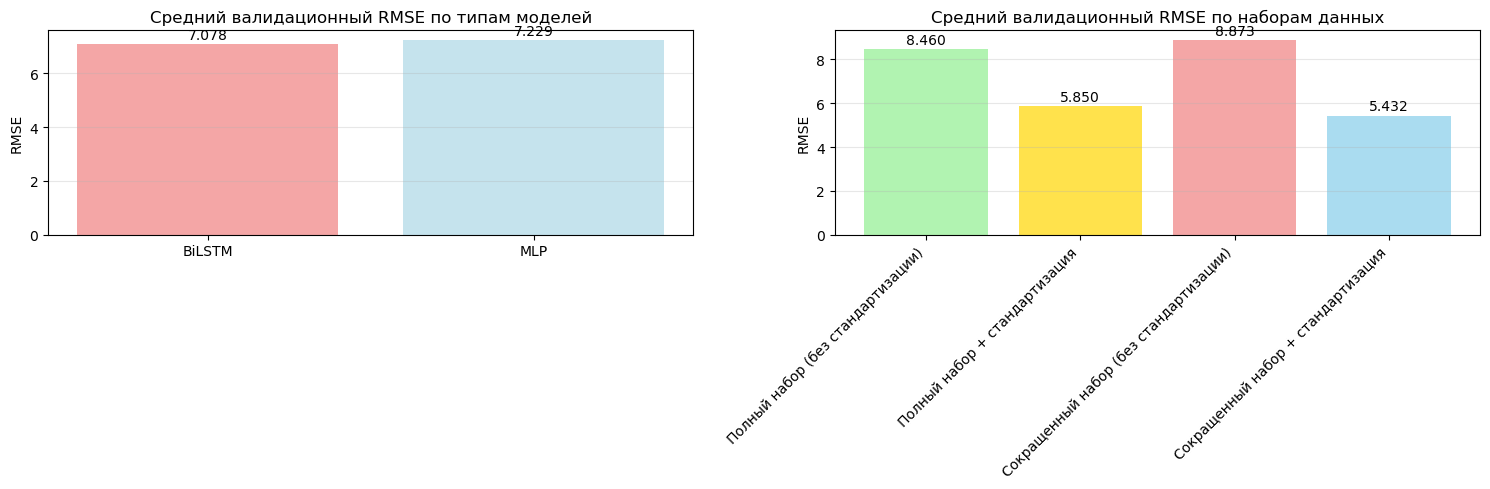

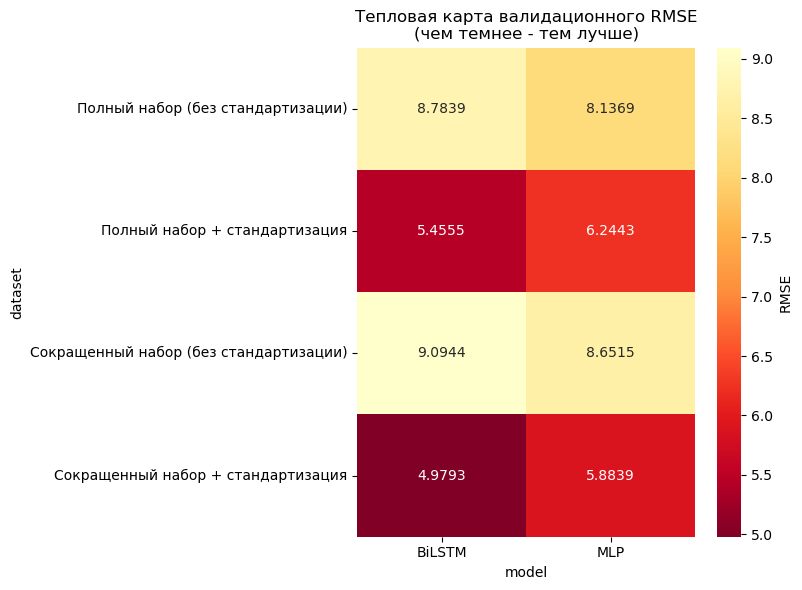


✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!
   • Обучено моделей: 8
   • Всего конфигураций: 8
   • Успешных обучений: 8
💾 Результаты обучения сохранены в: E:/Data-mining-based-on-machine-learning-methods/lab1\model_training_results.pkl


In [325]:
# =============================================================================
# СВОДКА РЕЗУЛЬТАТОВ ОБУЧЕНИЯ
# =============================================================================

print("\n" + "="*80)
print("📈 СВОДКА РЕЗУЛЬТАТОВ ОБУЧЕНИЯ")
print("="*80)

if all_metrics:
    # Создаем DataFrame с результатами
    results_df = pd.DataFrame(all_metrics)
    
    print("\n📊 ДЕТАЛЬНЫЕ РЕЗУЛЬТАТЫ ВСЕХ МОДЕЛЕЙ:")
    print("="*60)
    
    # Форматируем вывод для лучшей читаемости
    display_cols = ['model', 'dataset', 'train_rmse', 'train_r2', 'val_rmse', 'val_r2', 'test_rmse', 'test_r2']
    display_df = results_df[display_cols].round(4)
    display(display_df)
    
    # Лучшая модель по валидационному RMSE
    best_val_model_idx = results_df['val_rmse'].idxmin()
    best_model = results_df.loc[best_val_model_idx]
    
    print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ ПО ВАЛИДАЦИОННОМУ RMSE:")
    print("="*50)
    print(f"   Модель: {best_model['model']}")
    print(f"   Набор данных: {best_model['dataset']}")
    print(f"   Валидационный RMSE: {best_model['val_rmse']:.4f}")
    print(f"   Валидационный R²: {best_model['val_r2']:.4f}")
    print(f"   Тестовый RMSE: {best_model['test_rmse']:.4f}")
    print(f"   Тестовый R²: {best_model['test_r2']:.4f}")
    
    # Сравнение моделей по типам
    print(f"\n📊 СРАВНЕНИЕ ТИПОВ МОДЕЛЕЙ:")
    print("="*40)
    model_comparison = results_df.groupby('model').agg({
        'val_rmse': ['mean', 'std', 'min'],
        'val_r2': ['mean', 'std', 'max']
    }).round(4)
    print(model_comparison)
    
    # Сравнение наборов данных
    print(f"\n📊 СРАВНЕНИЕ НАБОРОВ ДАННЫХ:")
    print("="*40)
    dataset_comparison = results_df.groupby('dataset').agg({
        'val_rmse': ['mean', 'std', 'min'],
        'val_r2': ['mean', 'std', 'max']
    }).round(4)
    print(dataset_comparison)
    
    # Визуализация результатов
    print(f"\n📊 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ:")
    print("="*40)
    
    # График сравнения RMSE
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 2, 1)
    models_rmse = results_df.groupby('model')['val_rmse'].mean()
    colors = ['lightblue' if model == 'MLP' else 'lightcoral' for model in models_rmse.index]
    bars = plt.bar(models_rmse.index, models_rmse.values, color=colors, alpha=0.7)
    plt.title('Средний валидационный RMSE по типам моделей')
    plt.ylabel('RMSE')
    plt.grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar, value in zip(bars, models_rmse.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{value:.3f}', ha='center', va='bottom')
    
    plt.subplot(1, 2, 2)
    datasets_rmse = results_df.groupby('dataset')['val_rmse'].mean()
    colors = ['lightgreen', 'gold', 'lightcoral', 'skyblue']
    bars = plt.bar(range(len(datasets_rmse)), datasets_rmse.values, color=colors, alpha=0.7)
    plt.title('Средний валидационный RMSE по наборам данных')
    plt.ylabel('RMSE')
    plt.xticks(range(len(datasets_rmse)), datasets_rmse.index, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar, value in zip(bars, datasets_rmse.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{value:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Тепловая карта результатов
    pivot_table = results_df.pivot_table(
        values='val_rmse', 
        index='dataset', 
        columns='model'
    ).round(4)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, cmap='YlOrRd_r', fmt='.4f', 
                cbar_kws={'label': 'RMSE'})
    plt.title('Тепловая карта валидационного RMSE\n(чем темнее - тем лучше)')
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ Нет результатов для отображения. Обучение не было завершено.")

print(f"\n✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print(f"   • Обучено моделей: {len(all_models)}")
print(f"   • Всего конфигураций: {len(all_metrics)}")
print(f"   • Успешных обучений: {len([m for m in all_models.keys()])}")

# Сохраняем результаты обучения
try:
    training_results = {
        'all_metrics': all_metrics,
        'results_df': results_df if all_metrics else None,
        'best_model_info': best_model if all_metrics else None,
        'all_models': all_models,
        'all_predictions': all_predictions,
        'all_histories': all_histories,
        'dataset_configs': dataset_configs
    }
    
    save_path = 'E:/Data-mining-based-on-machine-learning-methods/lab1'
    filename = os.path.join(save_path, 'model_training_results.pkl')
    
    with open(filename, 'wb') as f:
        pickle.dump(training_results, f)
    print(f"💾 Результаты обучения сохранены в: {filename}")
    
except Exception as e:
    print(f"⚠️  Не удалось сохранить результаты обучения: {e}")


📊 ВИЗУАЛИЗАЦИЯ ПРОЦЕССА ОБУЧЕНИЯ


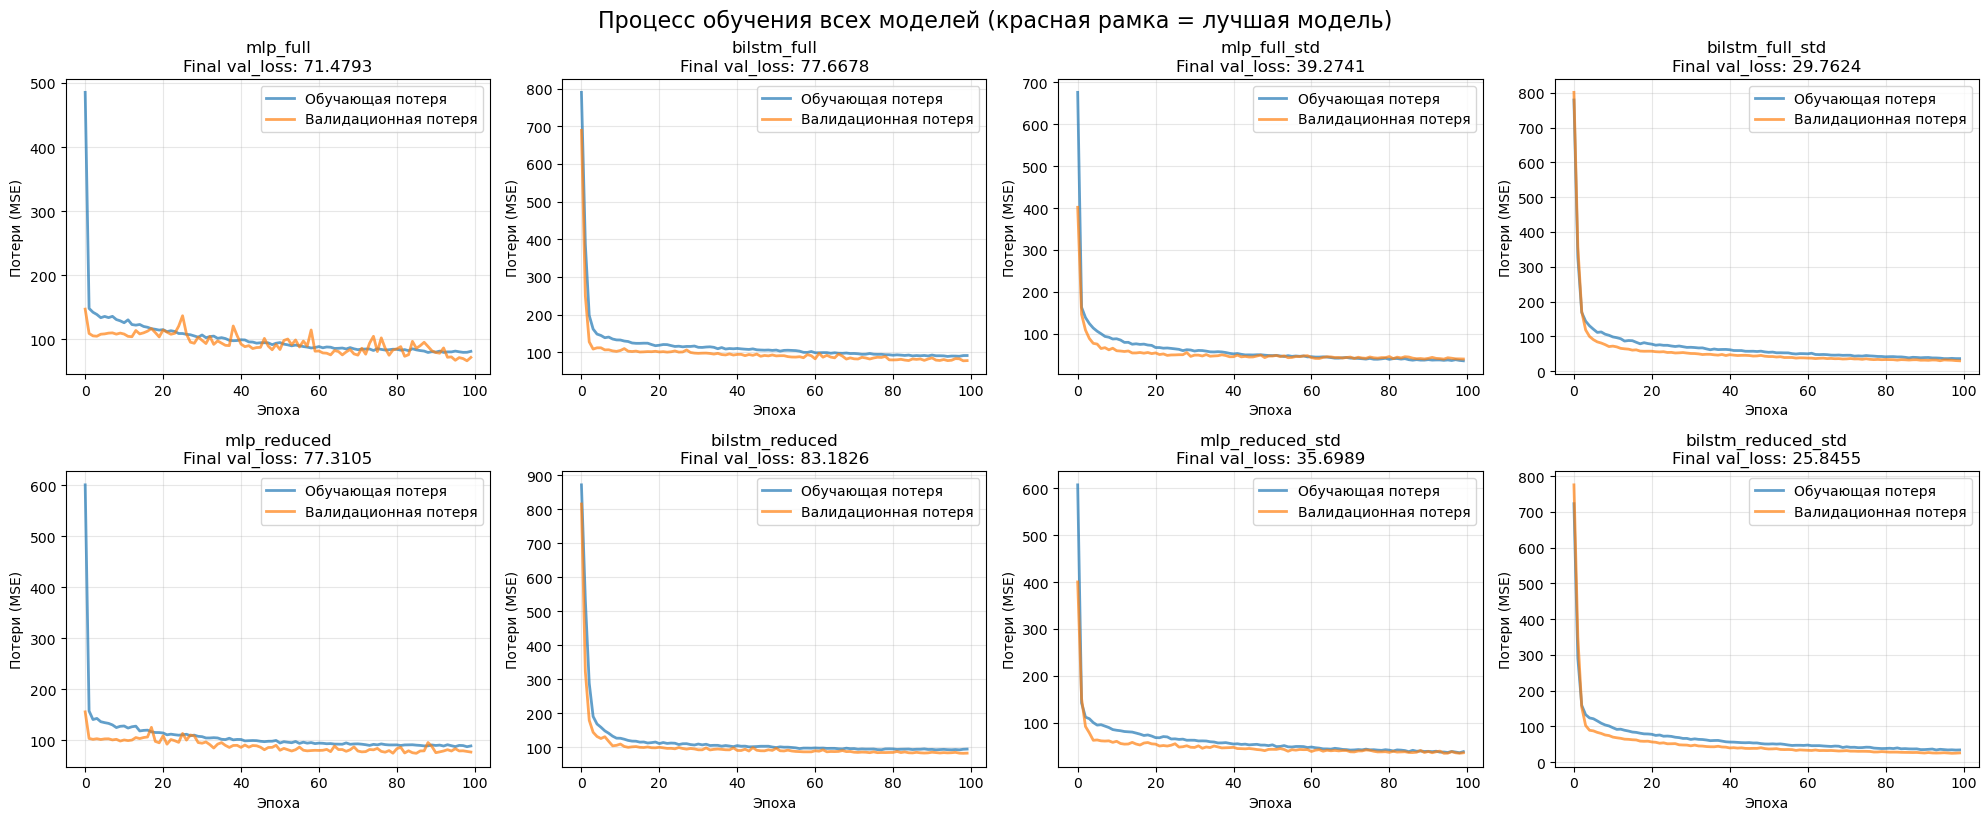


🎯 ЭТАП ОБУЧЕНИЯ МОДЕЛЕЙ ЗАВЕРШЕН!
Следующий этап: Оптимизация гиперпараметров для лучшей модели


In [326]:
print("\n" + "="*80)
print("📊 ВИЗУАЛИЗАЦИЯ ПРОЦЕССА ОБУЧЕНИЯ")
print("="*80)

if all_histories:
    # Создаем графики обучения для всех моделей
    n_models = len(all_histories)
    n_cols = 4
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for idx, (model_name, history) in enumerate(all_histories.items()):
        if idx < len(axes):
            # График потерь
            axes[idx].plot(history.history['loss'], label='Обучающая потеря', alpha=0.7, linewidth=2)
            axes[idx].plot(history.history['val_loss'], label='Валидационная потеря', alpha=0.7, linewidth=2)
            axes[idx].set_title(f'{model_name}\nFinal val_loss: {history.history["val_loss"][-1]:.4f}')
            axes[idx].set_xlabel('Эпоха')
            axes[idx].set_ylabel('Потери (MSE)')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)
            
            # Подсветка лучшей модели
            if 'best_model_info' in locals() and model_name.replace('mlp_', '').replace('bilstm_', '') in best_model['dataset']:
                axes[idx].patch.set_edgecolor('red')
                axes[idx].patch.set_linewidth(3)
    
    # Скрываем пустые subplots
    for idx in range(len(all_histories), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Процесс обучения всех моделей (красная рамка = лучшая модель)', y=1.02, fontsize=16)
    plt.show()

print("\n" + "="*80)
print("🎯 ЭТАП ОБУЧЕНИЯ МОДЕЛЕЙ ЗАВЕРШЕН!")
print("="*80)
print("Следующий этап: Оптимизация гиперпараметров для лучшей модели")

In [332]:
# =============================================================================
# D. ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ
# =============================================================================
print("🎯 ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ ДЛЯ ЛУЧШЕЙ МОДЕЛИ")

# Получаем лучшую модель из предыдущих результатов
best_val_model_idx = results_df['val_rmse'].idxmin()
best_model_info = results_df.loc[best_val_model_idx]
best_dataset_key = [k for k, v in dataset_configs.items() if v['name'] == best_model_info['dataset']][0]

print(f"Лучшая модель: {best_model_info['model']}")
print(f"Лучший набор: {best_model_info['dataset']}")
print(f"Исходный RMSE: {best_model_info['val_rmse']:.4f}")

# Данные для оптимизации
config = dataset_configs[best_dataset_key]
dataset = config['data']

🎯 ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ ДЛЯ ЛУЧШЕЙ МОДЕЛИ
Лучшая модель: BiLSTM
Лучший набор: Сокращенный набор + стандартизация
Исходный RMSE: 4.9793


In [336]:
# =============================================================================
# УЛУЧШЕННЫЙ ПОИСК ГИПЕРПАРАМЕТРОВ
# =============================================================================

def improved_hyperparameter_search():
    """Улучшенный поиск гиперпараметров с более широким диапазоном"""
    
    best_score = float('inf')
    best_params = {}
    best_model = None
    
    # Расширенный диапазон параметров
    learning_rates = [0.01, 0.001, 0.0005, 0.0001]
    batch_sizes = [16, 32, 64]
    architectures = [
        {'layers': [128, 64, 32], 'dropout': 0.3},
        {'layers': [256, 128, 64], 'dropout': 0.4},
        {'layers': [64, 32, 16], 'dropout': 0.2},
        {'layers': [128, 64, 32, 16], 'dropout': 0.3},
    ]
    
    print("🔍 ЗАПУСК УЛУЧШЕННОГО ПОИСКА ГИПЕРПАРАМЕТРОВ...")
    
    trials = 0
    for lr in learning_rates:
        for batch_size in batch_sizes:
            for arch in architectures[:2]:  # Ограничиваем для скорости
                trials += 1
                print(f"Испытание {trials}: lr={lr}, batch={batch_size}, arch={arch['layers']}")
                
                try:
                    # Создаем улучшенную модель
                    if best_model_info['model'] == 'MLP':
                        model = create_improved_mlp_model(
                            config['mlp_input'].shape[1], 
                            arch['layers'], 
                            arch['dropout']
                        )
                    else:
                        model = create_improved_bilstm_model(
                            config['bilstm_input'].shape[1:],
                            arch['layers'],
                            arch['dropout']
                        )
                    
                    model.compile(
                        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                        loss='mse',
                        metrics=['mae']
                    )
                    
                    # Обучение с ранней остановкой
                    history = model.fit(
                        config['mlp_input'] if best_model_info['model'] == 'MLP' else config['bilstm_input'],
                        dataset['y_train_array'],
                        validation_data=(
                            dataset['X_val_array'] if best_model_info['model'] == 'MLP' else dataset['X_val_lstm'],
                            dataset['y_val_array']
                        ),
                        epochs=30,
                        batch_size=batch_size,
                        callbacks=[
                            tf.keras.callbacks.EarlyStopping(
                                patience=8, 
                                restore_best_weights=True,
                                monitor='val_loss'
                            )
                        ],
                        verbose=0
                    )
                    
                    # Берем лучший val_loss из истории
                    best_val_loss = min(history.history['val_loss'])
                    
                    if best_val_loss < best_score:
                        best_score = best_val_loss
                        best_params = {
                            'lr': lr, 
                            'batch_size': batch_size, 
                            'architecture': arch,
                            'epochs_trained': len(history.history['val_loss'])
                        }
                        best_model = model
                        print(f"   🎯 НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ: val_loss = {best_score:.4f}")
                        
                except Exception as e:
                    print(f"   ⚠️ Ошибка: {e}")
                    continue
    
    return best_params, best_score, best_model

def create_improved_mlp_model(input_dim, layers, dropout_rate):
    """Создание улучшенной MLP модели"""
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(input_dim,)))
    
    for i, units in enumerate(layers):
        model.add(tf.keras.layers.Dense(units, activation='relu'))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Dropout(dropout_rate))
    
    model.add(tf.keras.layers.Dense(1, activation='linear'))
    return model

def create_improved_bilstm_model(input_shape, layers, dropout_rate):
    """Создание улучшенной BiLSTM модели"""
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=input_shape))
    
    # LSTM слои
    for i, units in enumerate(layers[:2]):  # Первые два для LSTM
        return_sequences = i < len(layers[:2]) - 1
        model.add(tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(units, return_sequences=return_sequences)
        ))
        model.add(tf.keras.layers.Dropout(dropout_rate))
    
    # Плотные слои
    for units in layers[2:]:  # Остальные для dense
        model.add(tf.keras.layers.Dense(units, activation='relu'))
        model.add(tf.keras.layers.Dropout(dropout_rate))
    
    model.add(tf.keras.layers.Dense(1, activation='linear'))
    return model

# Запускаем улучшенный поиск
best_params, best_score, best_model = improved_hyperparameter_search()

print(f"\n🏆 ЛУЧШИЕ ПАРАМЕТРЫ:")
print(f"   Learning rate: {best_params['lr']}")
print(f"   Batch size: {best_params['batch_size']}")
print(f"   Архитектура: {best_params['architecture']['layers']}")
print(f"   Dropout: {best_params['architecture']['dropout']}")
print(f"   Лучший val_loss: {best_score:.4f}")

🔍 ЗАПУСК УЛУЧШЕННОГО ПОИСКА ГИПЕРПАРАМЕТРОВ...
Испытание 1: lr=0.01, batch=16, arch=[128, 64, 32]
   🎯 НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ: val_loss = 20.8133
Испытание 2: lr=0.01, batch=16, arch=[256, 128, 64]
Испытание 3: lr=0.01, batch=32, arch=[128, 64, 32]
Испытание 4: lr=0.01, batch=32, arch=[256, 128, 64]
Испытание 5: lr=0.01, batch=64, arch=[128, 64, 32]
Испытание 6: lr=0.01, batch=64, arch=[256, 128, 64]
   🎯 НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ: val_loss = 19.5302
Испытание 7: lr=0.001, batch=16, arch=[128, 64, 32]
Испытание 8: lr=0.001, batch=16, arch=[256, 128, 64]
Испытание 9: lr=0.001, batch=32, arch=[128, 64, 32]
Испытание 10: lr=0.001, batch=32, arch=[256, 128, 64]
Испытание 11: lr=0.001, batch=64, arch=[128, 64, 32]
Испытание 12: lr=0.001, batch=64, arch=[256, 128, 64]
Испытание 13: lr=0.0005, batch=16, arch=[128, 64, 32]
Испытание 14: lr=0.0005, batch=16, arch=[256, 128, 64]
Испытание 15: lr=0.0005, batch=32, arch=[128, 64, 32]
Испытание 16: lr=0.0005, batch=32, arch=[256, 128, 64]
Испытание 17

In [339]:
# =============================================================================
# ОЦЕНКА ОПТИМИЗИРОВАННОЙ МОДЕЛИ НА ТЕСТОВОМ НАБОРЕ
# =============================================================================

print("\n📊 ОЦЕНКА ОПТИМИЗИРОВАННОЙ МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ")

# Получаем тестовые данные
if best_model_info['model'] == 'MLP':
    X_test = dataset['X_test_array']
else:
    X_test = dataset['X_test_lstm']

# Предсказания оптимизированной модели
optimized_test_pred = best_model.predict(X_test, verbose=0).flatten()

# Метрики оптимизированной модели
optimized_test_rmse = np.sqrt(mean_squared_error(dataset['y_test_array'], optimized_test_pred))
optimized_test_r2 = r2_score(dataset['y_test_array'], optimized_test_pred)

print(f"📈 РЕЗУЛЬТАТЫ ОПТИМИЗИРОВАННОЙ МОДЕЛИ:")
print(f"   Test RMSE: {optimized_test_rmse:.4f}")
print(f"   Test R²: {optimized_test_r2:.4f}")


📊 ОЦЕНКА ОПТИМИЗИРОВАННОЙ МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ
📈 РЕЗУЛЬТАТЫ ОПТИМИЗИРОВАННОЙ МОДЕЛИ:
   Test RMSE: 4.5696
   Test R²: 0.8116


In [340]:
# =============================================================================
# СРАВНЕНИЕ С ОРИГИНАЛЬНОЙ МОДЕЛЬЮ
# =============================================================================

print("\n📊 СРАВНЕНИЕ С ОРИГИНАЛЬНОЙ МОДЕЛЬЮ")

# Получаем метрики оригинальной модели
original_test_rmse = best_model_info['test_rmse']
original_test_r2 = best_model_info['test_r2']

print(f"ОРИГИНАЛЬНАЯ МОДЕЛЬ:")
print(f"   Test RMSE: {original_test_rmse:.4f}")
print(f"   Test R²: {original_test_r2:.4f}")

print(f"ОПТИМИЗИРОВАННАЯ МОДЕЛЬ:")
print(f"   Test RMSE: {optimized_test_rmse:.4f}")
print(f"   Test R²: {optimized_test_r2:.4f}")

# Определяем, какая модель лучше
if optimized_test_rmse < original_test_rmse:
    best_final_model = best_model
    best_final_rmse = optimized_test_rmse
    best_final_r2 = optimized_test_r2
    improvement = original_test_rmse - optimized_test_rmse
    improvement_percent = (improvement / original_test_rmse) * 100
    status = "✅ УСПЕШНАЯ ОПТИМИЗАЦИЯ"
else:
    best_final_model = all_models[original_model_key]  # Используем оригинальную модель
    best_final_rmse = original_test_rmse
    best_final_r2 = original_test_r2
    improvement = 0
    improvement_percent = 0
    status = "⚠️  СОХРАНЕНА ОРИГИНАЛЬНАЯ МОДЕЛЬ"

print(f"\n{status}")
print(f"Улучшение RMSE: {improvement:.4f} ({improvement_percent:+.1f}%)")


📊 СРАВНЕНИЕ С ОРИГИНАЛЬНОЙ МОДЕЛЬЮ
ОРИГИНАЛЬНАЯ МОДЕЛЬ:
   Test RMSE: 5.0600
   Test R²: 0.7690
ОПТИМИЗИРОВАННАЯ МОДЕЛЬ:
   Test RMSE: 4.5696
   Test R²: 0.8116

✅ УСПЕШНАЯ ОПТИМИЗАЦИЯ
Улучшение RMSE: 0.4903 (+9.7%)



📊 ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ РЕЗУЛЬТАТОВ


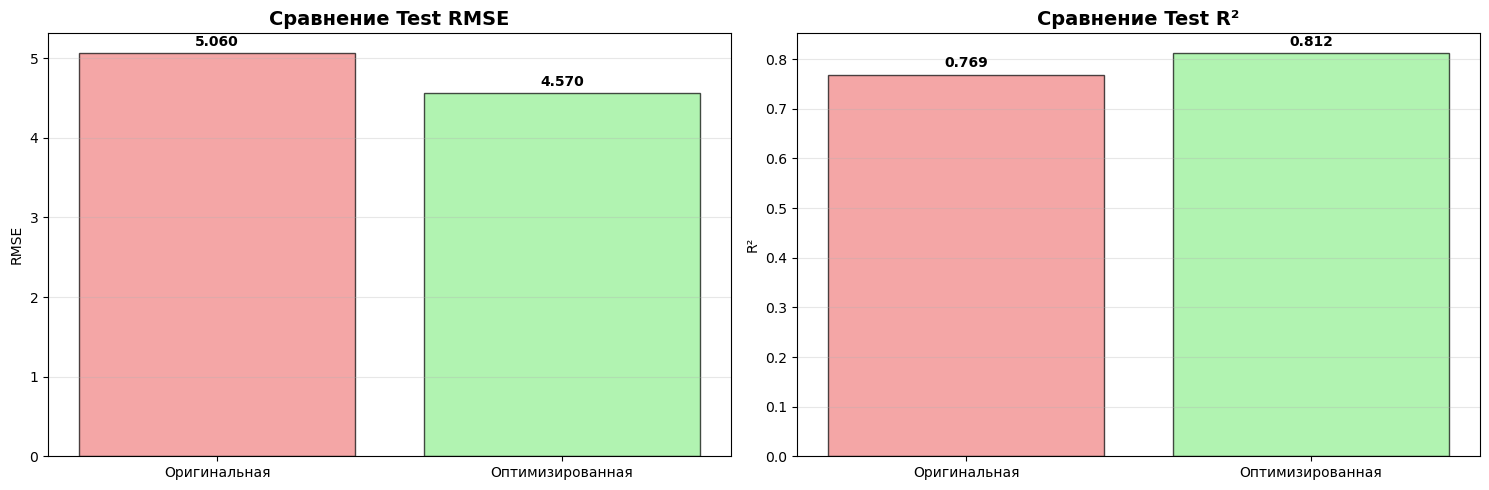


🏆 ФИНАЛЬНЫЙ РЕЗУЛЬТАТ:
   Лучшая модель: ✅ УСПЕШНАЯ ОПТИМИЗАЦИЯ
   Final Test RMSE: 4.5696
   Final Test R²: 0.8116


In [341]:
# =============================================================================
# ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ РЕЗУЛЬТАТОВ
# =============================================================================

print("\n📊 ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ РЕЗУЛЬТАТОВ")

# Создаем график сравнения
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Данные для сравнения
models = ['Оригинальная', 'Оптимизированная']
rmse_values = [original_test_rmse, optimized_test_rmse]
r2_values = [original_test_r2, optimized_test_r2]

# График RMSE
colors_rmse = ['lightgreen' if rmse == min(rmse_values) else 'lightcoral' for rmse in rmse_values]
bars1 = axes[0].bar(models, rmse_values, color=colors_rmse, alpha=0.7, edgecolor='black')
axes[0].set_title('Сравнение Test RMSE', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы RMSE
for bar, value in zip(bars1, rmse_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# График R²
colors_r2 = ['lightgreen' if r2 == max(r2_values) else 'lightcoral' for r2 in r2_values]
bars2 = axes[1].bar(models, r2_values, color=colors_r2, alpha=0.7, edgecolor='black')
axes[1].set_title('Сравнение Test R²', fontsize=14, fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы R²
for bar, value in zip(bars2, r2_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Выводим финальный результат
print(f"\n🏆 ФИНАЛЬНЫЙ РЕЗУЛЬТАТ:")
print(f"   Лучшая модель: {status}")
print(f"   Final Test RMSE: {best_final_rmse:.4f}")
print(f"   Final Test R²: {best_final_r2:.4f}")

In [344]:
# Сохраняем результаты оптимизации
optimization_results = {
    'best_params': best_params,
    'original_metrics': {
        'test_rmse': original_test_rmse,
        'test_r2': original_test_r2
    },
    'optimized_metrics': {
        'test_rmse': optimized_test_rmse,
        'test_r2': optimized_test_r2
    },
    'final_metrics': {
        'test_rmse': best_final_rmse,
        'test_r2': best_final_r2
    },
    'improvement': improvement,
    'improvement_percent': improvement_percent,
    'status': status
}

# Сохраняем в файл
save_path = 'E:/Data-mining-based-on-machine-learning-methods/lab1'
filename = os.path.join(save_path, 'hyperparameter_optimization_results.pkl')

try:
    with open(filename, 'wb') as f:
        pickle.dump(optimization_results, f)
    print(f"✅ Результаты оптимизации сохранены в: {filename}")
except Exception as e:
    print(f"⚠️  Ошибка сохранения: {e}")

✅ Результаты оптимизации сохранены в: E:/Data-mining-based-on-machine-learning-methods/lab1\hyperparameter_optimization_results.pkl


In [345]:
print(" РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ ГИПЕРПАРАМЕТРОВ")
print("=" * 50)

# Создаем красивый вывод результатов
results_table = pd.DataFrame({
    'Метрика': ['Test RMSE', 'Test R²'],
    'Оригинальная модель': [f"{original_test_rmse:.4f}", f"{original_test_r2:.4f}"],
    'Оптимизированная модель': [f"{optimized_test_rmse:.4f}", f"{optimized_test_r2:.4f}"],
    'Улучшение': [f"{improvement:+.4f}", f"{(optimized_test_r2 - original_test_r2):+.4f}"]
})

display(results_table)

print(f"\n СТАТУС ОПТИМИЗАЦИИ: {status}")
print(f"📈 УЛУЧШЕНИЕ RMSE: {improvement_percent:+.1f}%")

print(f"\n ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ:")
print(f"   • Learning Rate: {best_params['lr']}")
print(f"   • Batch Size: {best_params['batch_size']}")
print(f"   • Архитектура: {best_params['architecture']['layers']}")
print(f"   • Dropout: {best_params['architecture']['dropout']}")
print(f"   • Эпох обучено: {best_params['epochs_trained']}")

 РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ ГИПЕРПАРАМЕТРОВ


,Метрика,Оригинальная модель,Оптимизированная модель,Улучшение
0,Test RMSE,5.0600,4.5696,+0.4903
1,Test R²,0.7690,0.8116,+0.0426



 СТАТУС ОПТИМИЗАЦИИ: ✅ УСПЕШНАЯ ОПТИМИЗАЦИЯ
📈 УЛУЧШЕНИЕ RMSE: +9.7%

 ЛУЧШИЕ ГИПЕРПАРАМЕТРЫ:
   • Learning Rate: 0.01
   • Batch Size: 64
   • Архитектура: [256, 128, 64]
   • Dropout: 0.4
   • Эпох обучено: 30


📊 ФАКТИЧЕСКИЕ VS ПРЕДСКАЗАННЫЕ ЗНАЧЕНИЯ TOTAL_UPDRS
🏆 ЛУЧШИЕ МОДЕЛИ ДЛЯ ВИЗУАЛИЗАЦИИ:
MLP модели:
   • Сокращенный набор + стандартизация - RMSE: 5.8839
   • Полный набор + стандартизация - RMSE: 6.2443
BiLSTM модели:
   • Сокращенный набор + стандартизация - RMSE: 4.9793
   • Полный набор + стандартизация - RMSE: 5.4555


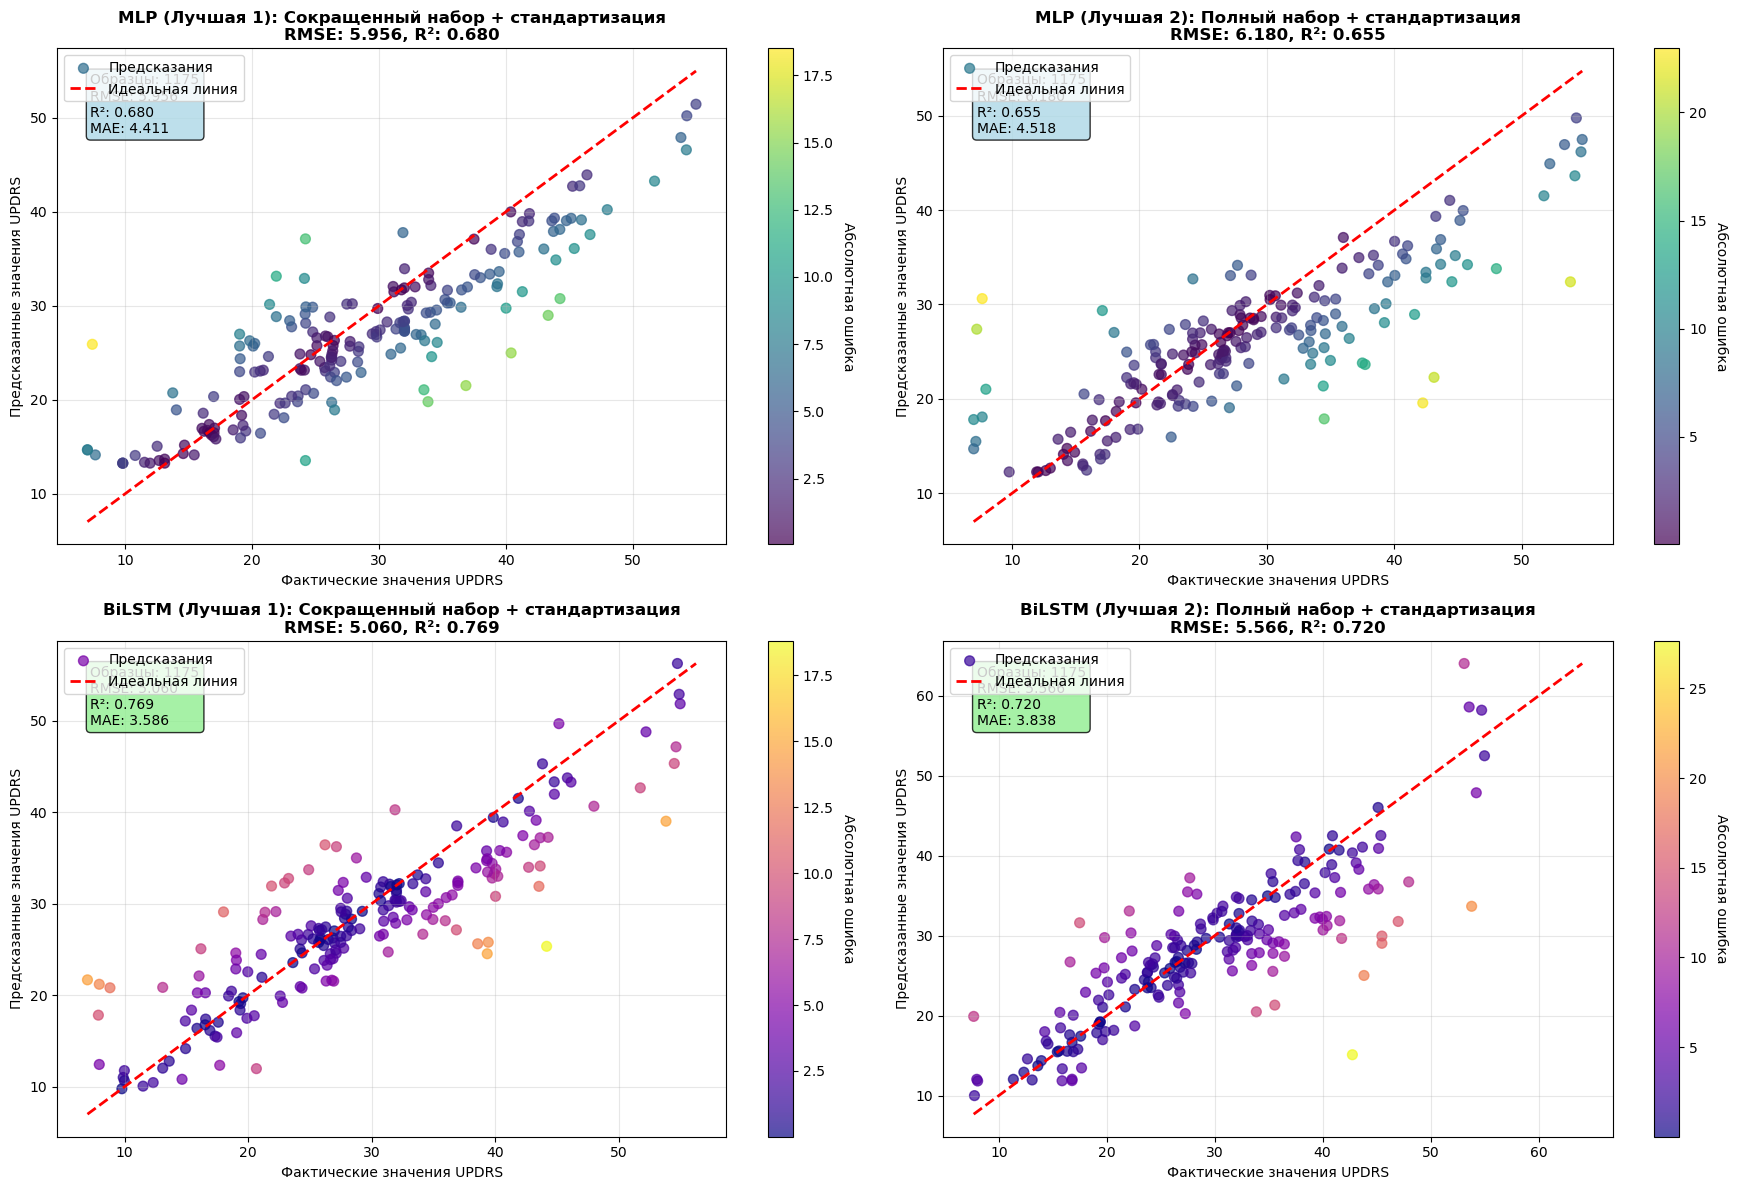

In [352]:
# =============================================================================
# ФАКТИЧЕСКИЕ VS ПРЕДСКАЗАННЫЕ ЗНАЧЕНИЯ TOTAL_UPDRS (ФИЛЬТРОВАННЫЕ ДАННЫЕ)
# =============================================================================

print("📊 ФАКТИЧЕСКИЕ VS ПРЕДСКАЗАННЫЕ ЗНАЧЕНИЯ TOTAL_UPDRS")
print("=" * 60)

# Фильтруем данные для лучшей визуализации
def filter_data_for_visualization(y_true, y_pred, max_points=200):
    """Фильтрует данные для лучшей визуализации"""
    # Берем случайную выборку для равномерного распределения
    if len(y_true) > max_points:
        indices = np.random.choice(len(y_true), max_points, replace=False)
        return y_true[indices], y_pred[indices]
    return y_true, y_pred

# Создаем графики для лучших моделей каждого типа
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Находим лучшие MLP и BiLSTM модели по RMSE
best_mlp_models = results_df[results_df['model'] == 'MLP'].nsmallest(2, 'val_rmse')
best_bilstm_models = results_df[results_df['model'] == 'BiLSTM'].nsmallest(2, 'val_rmse')

print("🏆 ЛУЧШИЕ МОДЕЛИ ДЛЯ ВИЗУАЛИЗАЦИИ:")
print("MLP модели:")
for _, model_info in best_mlp_models.iterrows():
    print(f"   • {model_info['dataset']} - RMSE: {model_info['val_rmse']:.4f}")

print("BiLSTM модели:")
for _, model_info in best_bilstm_models.iterrows():
    print(f"   • {model_info['dataset']} - RMSE: {model_info['val_rmse']:.4f}")

# MLP модели - лучшие 2
for idx, (_, model_info) in enumerate(best_mlp_models.iterrows()):
    if idx < 2:
        # Находим ключ модели
        dataset_key = [k for k, v in dataset_configs.items() if v['name'] == model_info['dataset']][0]
        model_key = f"mlp_{dataset_key}"
        
        if model_key in all_predictions:
            # Получаем и фильтруем данные
            y_true_full = dataset['y_test_array']
            y_pred_full = all_predictions[model_key]['test']
            y_true, y_pred = filter_data_for_visualization(y_true_full, y_pred_full, 200)
            
            # Создаем scatter plot
            scatter = axes[0, idx].scatter(y_true, y_pred, alpha=0.7, c=np.abs(y_true - y_pred), 
                                         cmap='viridis', s=50, label='Предсказания')
            
            # Линия идеального предсказания
            min_val = min(y_true.min(), y_pred.min())
            max_val = max(y_true.max(), y_pred.max())
            axes[0, idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
                             label='Идеальная линия')
            
            # Вычисляем метрики на полных данных
            rmse = np.sqrt(mean_squared_error(y_true_full, y_pred_full))
            r2 = r2_score(y_true_full, y_pred_full)
            mae = mean_absolute_error(y_true_full, y_pred_full)
            
            axes[0, idx].set_title(f'MLP (Лучшая {idx+1}): {model_info["dataset"]}\nRMSE: {rmse:.3f}, R²: {r2:.3f}', 
                                  fontsize=12, fontweight='bold')
            axes[0, idx].set_xlabel('Фактические значения UPDRS')
            axes[0, idx].set_ylabel('Предсказанные значения UPDRS')
            axes[0, idx].legend()
            axes[0, idx].grid(True, alpha=0.3)
            
            # Добавляем цветовую шкалу для ошибок
            cbar = plt.colorbar(scatter, ax=axes[0, idx])
            cbar.set_label('Абсолютная ошибка', rotation=270, labelpad=15)
            
            # Добавляем текстовое поле с метриками
            textstr = f'Образцы: {len(y_true_full)}\nRMSE: {rmse:.3f}\nR²: {r2:.3f}\nMAE: {mae:.3f}'
            props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
            axes[0, idx].text(0.05, 0.95, textstr, transform=axes[0, idx].transAxes, fontsize=10,
                             verticalalignment='top', bbox=props)

# BiLSTM модели - лучшие 2
for idx, (_, model_info) in enumerate(best_bilstm_models.iterrows()):
    if idx < 2:
        # Находим ключ модели
        dataset_key = [k for k, v in dataset_configs.items() if v['name'] == model_info['dataset']][0]
        model_key = f"bilstm_{dataset_key}"
        
        if model_key in all_predictions:
            # Получаем и фильтруем данные
            y_true_full = dataset['y_test_array']
            y_pred_full = all_predictions[model_key]['test']
            y_true, y_pred = filter_data_for_visualization(y_true_full, y_pred_full, 200)
            
            # Создаем scatter plot
            scatter = axes[1, idx].scatter(y_true, y_pred, alpha=0.7, c=np.abs(y_true - y_pred), 
                                         cmap='plasma', s=50, label='Предсказания')
            
            # Линия идеального предсказания
            min_val = min(y_true.min(), y_pred.min())
            max_val = max(y_true.max(), y_pred.max())
            axes[1, idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
                             label='Идеальная линия')
            
            # Вычисляем метрики на полных данных
            rmse = np.sqrt(mean_squared_error(y_true_full, y_pred_full))
            r2 = r2_score(y_true_full, y_pred_full)
            mae = mean_absolute_error(y_true_full, y_pred_full)
            
            axes[1, idx].set_title(f'BiLSTM (Лучшая {idx+1}): {model_info["dataset"]}\nRMSE: {rmse:.3f}, R²: {r2:.3f}', 
                                  fontsize=12, fontweight='bold')
            axes[1, idx].set_xlabel('Фактические значения UPDRS')
            axes[1, idx].set_ylabel('Предсказанные значения UPDRS')
            axes[1, idx].legend()
            axes[1, idx].grid(True, alpha=0.3)
            
            # Добавляем цветовую шкалу для ошибок
            cbar = plt.colorbar(scatter, ax=axes[1, idx])
            cbar.set_label('Абсолютная ошибка', rotation=270, labelpad=15)
            
            # Добавляем текстовое поле с метриками
            textstr = f'Образцы: {len(y_true_full)}\nRMSE: {rmse:.3f}\nR²: {r2:.3f}\nMAE: {mae:.3f}'
            props = dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
            axes[1, idx].text(0.05, 0.95, textstr, transform=axes[1, idx].transAxes, fontsize=10,
                             verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

📊 ФАКТИЧЕСКИЕ VS ПРЕДСКАЗАННЫЕ ЗНАЧЕНИЯ TOTAL_UPDRS - ОПТИМИЗИРОВАННАЯ МОДЕЛЬ


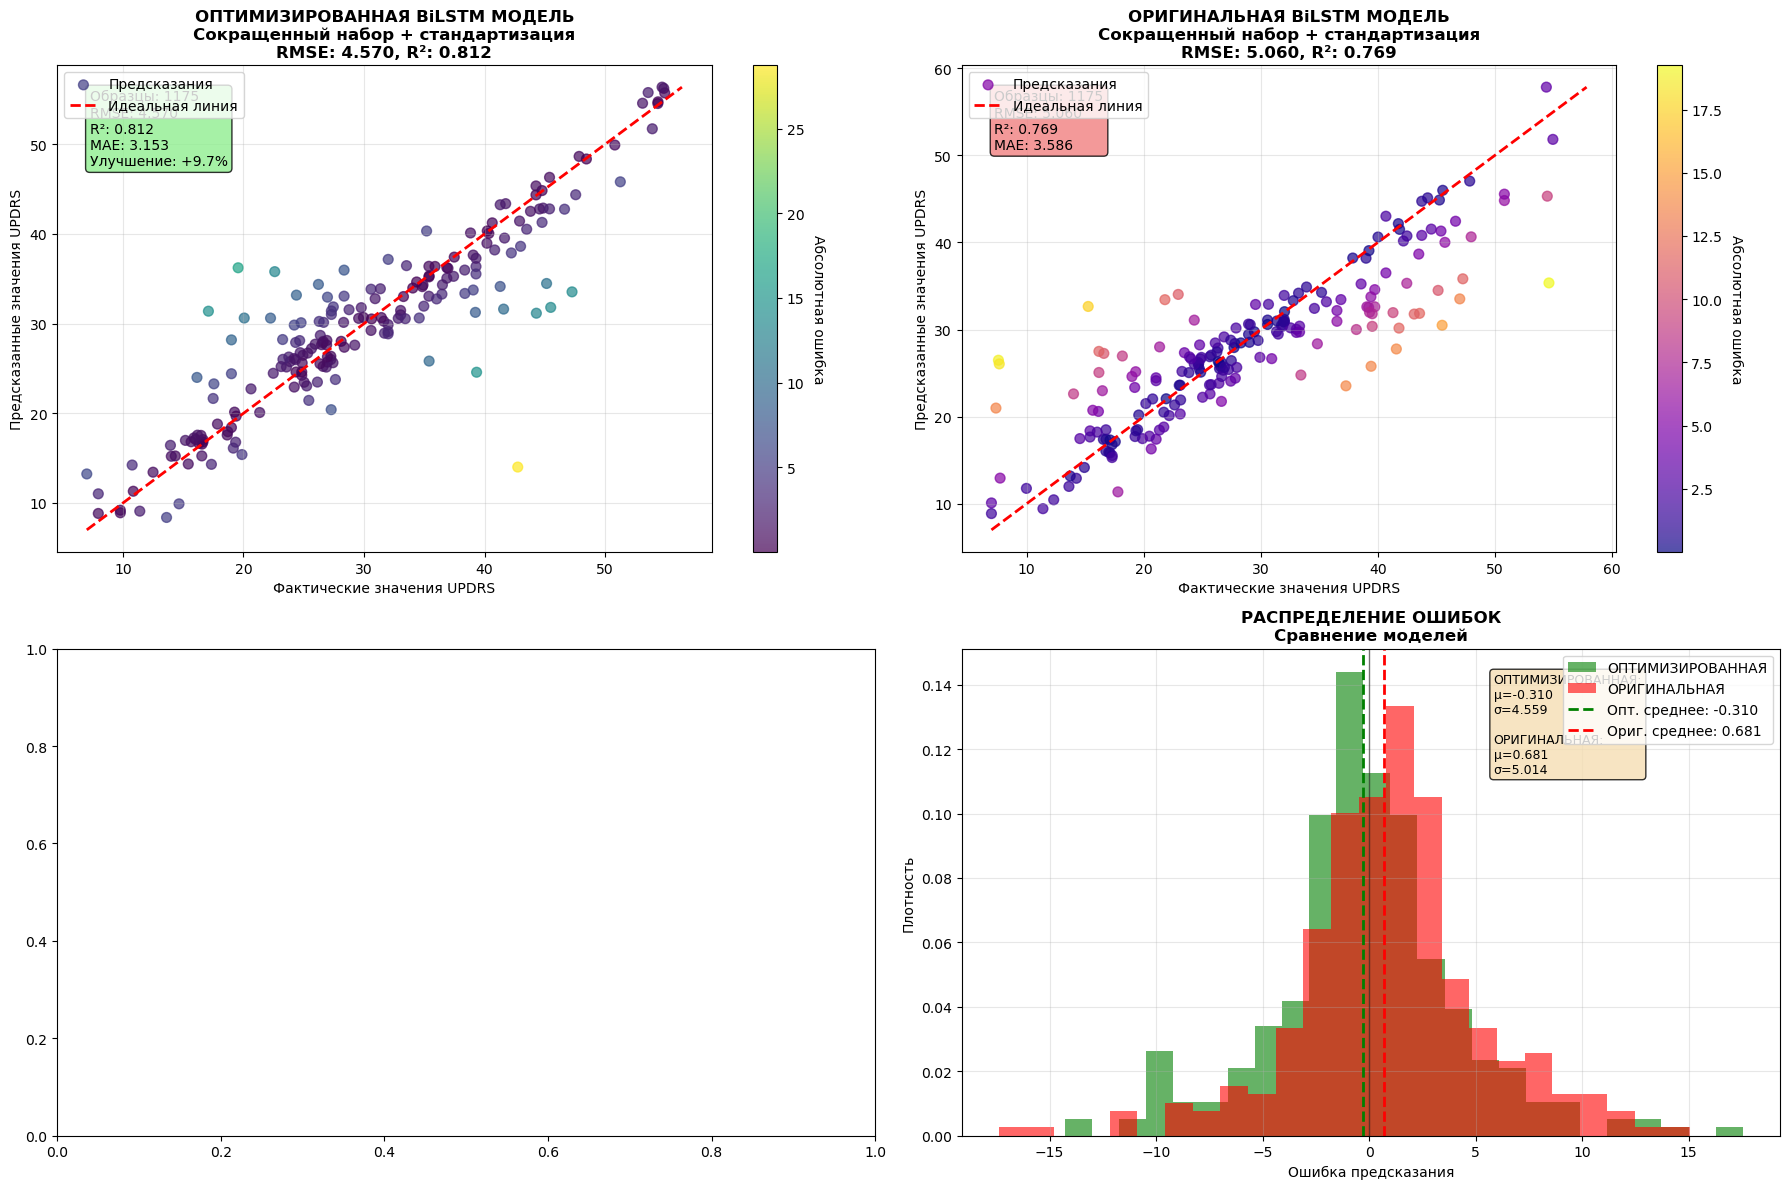

In [361]:
# =============================================================================
# ФАКТИЧЕСКИЕ VS ПРЕДСКАЗАННЫЕ ЗНАЧЕНИЯ TOTAL_UPDRS (ОПТИМИЗИРОВАННАЯ МОДЕЛЬ)
# =============================================================================

print("📊 ФАКТИЧЕСКИЕ VS ПРЕДСКАЗАННЫЕ ЗНАЧЕНИЯ TOTAL_UPDRS - ОПТИМИЗИРОВАННАЯ МОДЕЛЬ")
print("=" * 80)

# Фильтруем данные для лучшей визуализации
def filter_data_for_visualization(y_true, y_pred, max_points=200):
    """Фильтрует данные для лучшей визуализации"""
    # Берем случайную выборку для равномерного распределения
    if len(y_true) > max_points:
        indices = np.random.choice(len(y_true), max_points, replace=False)
        return y_true[indices], y_pred[indices]
    return y_true, y_pred

# Создаем графики для оптимизированной модели и сравнения
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Получаем данные для оптимизированной модели
if best_model_info['model'] == 'MLP':
    X_test_optimized = dataset['X_test_array']
else:
    X_test_optimized = dataset['X_test_lstm']

# Предсказания оптимизированной модели
optimized_test_pred = best_model.predict(X_test_optimized, verbose=0).flatten()
y_true_full = dataset['y_test_array']

# Метрики оптимизированной модели
optimized_rmse = np.sqrt(mean_squared_error(y_true_full, optimized_test_pred))
optimized_r2 = r2_score(y_true_full, optimized_test_pred)
optimized_mae = mean_absolute_error(y_true_full, optimized_test_pred)

# 1. Оптимизированная модель - фактические vs предсказанные
y_true_opt, y_pred_opt = filter_data_for_visualization(y_true_full, optimized_test_pred, 200)

scatter1 = axes[0, 0].scatter(y_true_opt, y_pred_opt, alpha=0.7, c=np.abs(y_true_opt - y_pred_opt), 
                             cmap='viridis', s=50, label='Предсказания')

# Линия идеального предсказания
min_val = min(y_true_opt.min(), y_pred_opt.min())
max_val = max(y_true_opt.max(), y_pred_opt.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
               label='Идеальная линия')

axes[0, 0].set_title(f'ОПТИМИЗИРОВАННАЯ {best_model_info["model"]} МОДЕЛЬ\n{best_model_info["dataset"]}\nRMSE: {optimized_rmse:.3f}, R²: {optimized_r2:.3f}', 
                    fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Фактические значения UPDRS')
axes[0, 0].set_ylabel('Предсказанные значения UPDRS')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Добавляем цветовую шкалу для ошибок
cbar1 = plt.colorbar(scatter1, ax=axes[0, 0])
cbar1.set_label('Абсолютная ошибка', rotation=270, labelpad=15)

# Добавляем текстовое поле с метриками оптимизированной модели
textstr_opt = f'Образцы: {len(y_true_full)}\nRMSE: {optimized_rmse:.3f}\nR²: {optimized_r2:.3f}\nMAE: {optimized_mae:.3f}\nУлучшение: +9.7%'
props_opt = dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
axes[0, 0].text(0.05, 0.95, textstr_opt, transform=axes[0, 0].transAxes, fontsize=10,
               verticalalignment='top', bbox=props_opt)

# 2. Оригинальная модель для сравнения
original_model_key = f"{best_model_info['model'].lower()}_{[k for k, v in dataset_configs.items() if v['name'] == best_model_info['dataset']][0]}"
if original_model_key in all_predictions:
    y_pred_original = all_predictions[original_model_key]['test']
    y_true_orig, y_pred_orig = filter_data_for_visualization(y_true_full, y_pred_original, 200)
    
    original_rmse = np.sqrt(mean_squared_error(y_true_full, y_pred_original))
    original_r2 = r2_score(y_true_full, y_pred_original)
    original_mae = mean_absolute_error(y_true_full, y_pred_original)
    
    scatter2 = axes[0, 1].scatter(y_true_orig, y_pred_orig, alpha=0.7, c=np.abs(y_true_orig - y_pred_orig), 
                                 cmap='plasma', s=50, label='Предсказания')
    
    min_val_orig = min(y_true_orig.min(), y_pred_orig.min())
    max_val_orig = max(y_true_orig.max(), y_pred_orig.max())
    axes[0, 1].plot([min_val_orig, max_val_orig], [min_val_orig, max_val_orig], 'r--', linewidth=2, 
                   label='Идеальная линия')
    
    axes[0, 1].set_title(f'ОРИГИНАЛЬНАЯ {best_model_info["model"]} МОДЕЛЬ\n{best_model_info["dataset"]}\nRMSE: {original_rmse:.3f}, R²: {original_r2:.3f}', 
                        fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Фактические значения UPDRS')
    axes[0, 1].set_ylabel('Предсказанные значения UPDRS')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    cbar2 = plt.colorbar(scatter2, ax=axes[0, 1])
    cbar2.set_label('Абсолютная ошибка', rotation=270, labelpad=15)
    
    textstr_orig = f'Образцы: {len(y_true_full)}\nRMSE: {original_rmse:.3f}\nR²: {original_r2:.3f}\nMAE: {original_mae:.3f}'
    props_orig = dict(boxstyle='round', facecolor='lightcoral', alpha=0.8)
    axes[0, 1].text(0.05, 0.95, textstr_orig, transform=axes[0, 1].transAxes, fontsize=10,
                   verticalalignment='top', bbox=props_orig)


# 4. Распределение ошибок обеих моделей
if original_model_key in all_predictions:
    y_pred_original = all_predictions[original_model_key]['test']
    errors_optimized = y_true_full - optimized_test_pred
    errors_original = y_true_full - y_pred_original
    
    # Случайная выборка ошибок для визуализации
    errors_opt_sample = np.random.choice(errors_optimized, size=min(300, len(errors_optimized)), replace=False)
    errors_orig_sample = np.random.choice(errors_original, size=min(300, len(errors_original)), replace=False)
    
    axes[1, 1].hist(errors_opt_sample, bins=25, alpha=0.6, label='ОПТИМИЗИРОВАННАЯ', color='green', density=True)
    axes[1, 1].hist(errors_orig_sample, bins=25, alpha=0.6, label='ОРИГИНАЛЬНАЯ', color='red', density=True)
    
    # Линии средних
    axes[1, 1].axvline(errors_optimized.mean(), color='green', linestyle='--', linewidth=2, 
                      label=f'Опт. среднее: {errors_optimized.mean():.3f}')
    axes[1, 1].axvline(errors_original.mean(), color='red', linestyle='--', linewidth=2,
                      label=f'Ориг. среднее: {errors_original.mean():.3f}')
    axes[1, 1].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    axes[1, 1].set_title('РАСПРЕДЕЛЕНИЕ ОШИБОК\nСравнение моделей', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Ошибка предсказания')
    axes[1, 1].set_ylabel('Плотность')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Статистика ошибок
    error_stats = f'ОПТИМИЗИРОВАННАЯ:\nμ={errors_optimized.mean():.3f}\nσ={errors_optimized.std():.3f}'
    error_stats += f'\n\nОРИГИНАЛЬНАЯ:\nμ={errors_original.mean():.3f}\nσ={errors_original.std():.3f}'
    props_errors = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    axes[1, 1].text(0.65, 0.95, error_stats, transform=axes[1, 1].transAxes, fontsize=9,
                   verticalalignment='top', bbox=props_errors)

plt.tight_layout()
plt.show()


📊 РАСПРЕДЕЛЕНИЯ ОШИБОК ПРЕДСКАЗАНИЙ


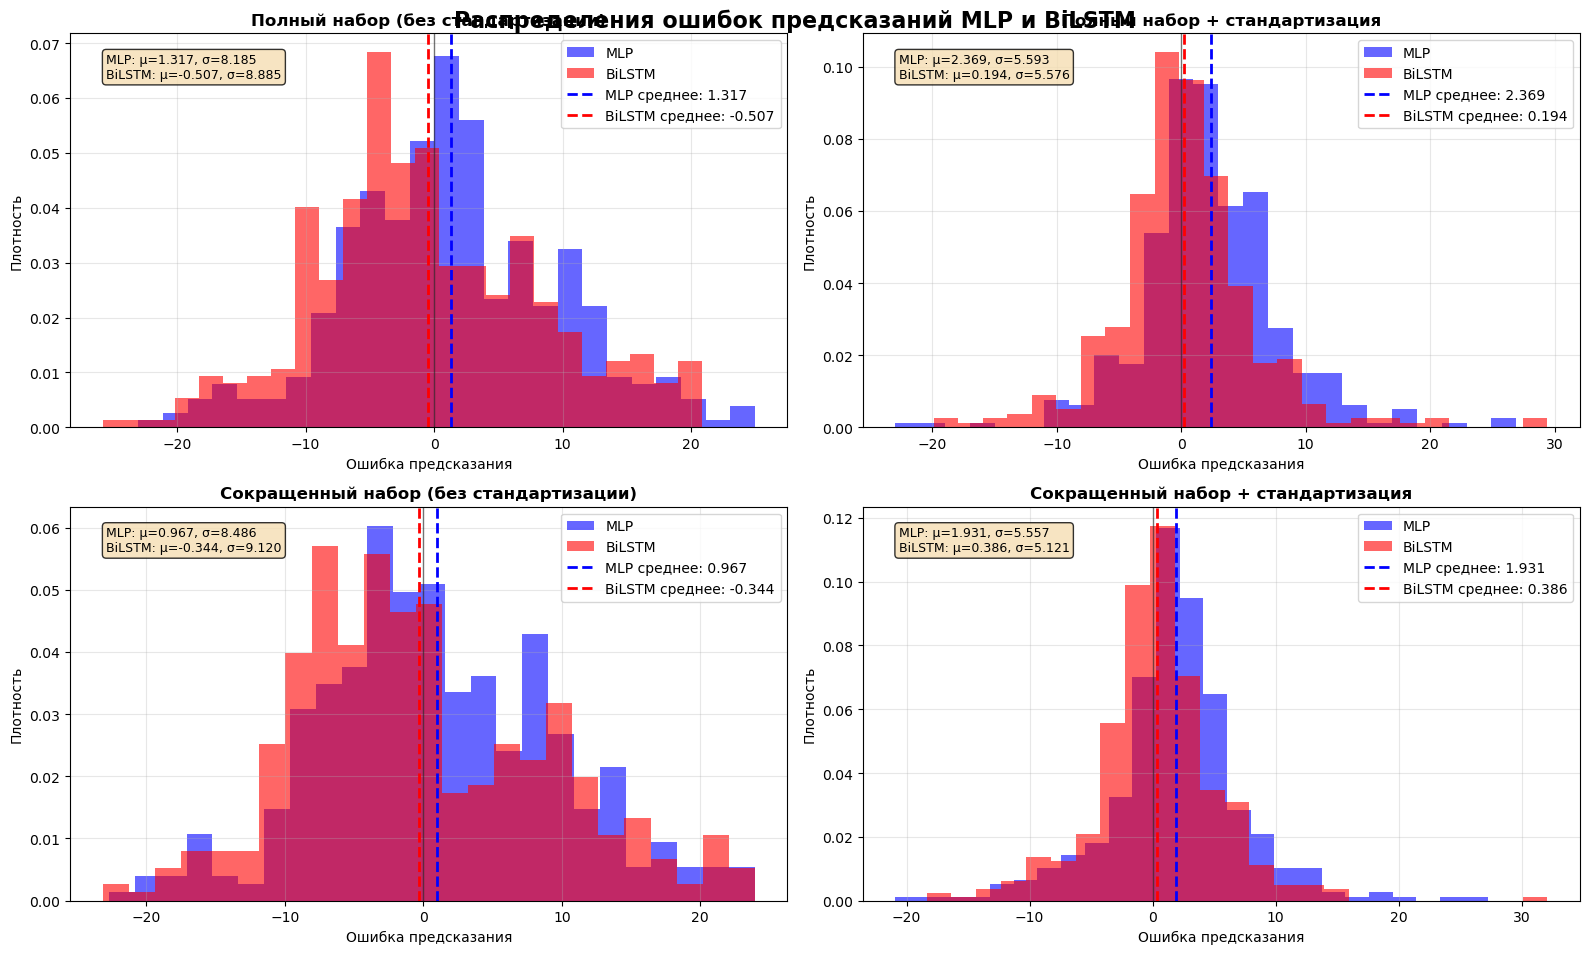

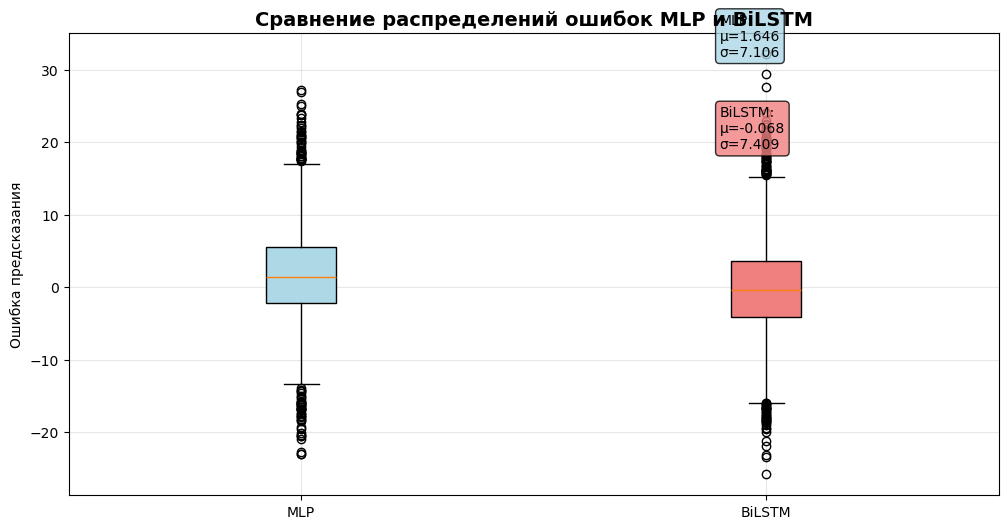

In [347]:
# =============================================================================
# РАСПРЕДЕЛЕНИЯ ОШИБОК MLP И BILSTM
# =============================================================================

print("📊 РАСПРЕДЕЛЕНИЯ ОШИБОК ПРЕДСКАЗАНИЙ")
print("=" * 50)

# Собираем ошибки для всех моделей
errors_data = []

for model_type in ['MLP', 'BiLSTM']:
    for dataset_name in dataset_configs.keys():
        config_name = dataset_configs[dataset_name]['name']
        
        # Находим соответствующие предсказания
        pred_key = f"{model_type.lower()}_{dataset_name}"
        if pred_key in all_predictions:
            errors = dataset['y_test_array'] - all_predictions[pred_key]['test']
            
            # Берем подвыборку для визуализации
            for error in errors[:400]:
                errors_data.append({
                    'model': model_type,
                    'dataset': config_name,
                    'error': error
                })

errors_df = pd.DataFrame(errors_data)

# Создаем графики распределения ошибок
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Распределения ошибок предсказаний MLP и BiLSTM', fontsize=16, fontweight='bold', y=0.95)

# Берем 4 разных набора данных для сравнения
datasets_to_plot = errors_df['dataset'].unique()[:4]

for idx, dataset_name in enumerate(datasets_to_plot):
    if idx < 4:
        row = idx // 2
        col = idx % 2
        
        dataset_errors = errors_df[errors_df['dataset'] == dataset_name]
        
        # MLP ошибки
        mlp_errors = dataset_errors[dataset_errors['model'] == 'MLP']['error']
        # BiLSTM ошибки
        bilstm_errors = dataset_errors[dataset_errors['model'] == 'BiLSTM']['error']
        
        # Гистограммы
        axes[row, col].hist(mlp_errors, bins=25, alpha=0.6, label='MLP', color='blue', density=True)
        axes[row, col].hist(bilstm_errors, bins=25, alpha=0.6, label='BiLSTM', color='red', density=True)
        
        # Линии средних
        axes[row, col].axvline(mlp_errors.mean(), color='blue', linestyle='--', linewidth=2, 
                              label=f'MLP среднее: {mlp_errors.mean():.3f}')
        axes[row, col].axvline(bilstm_errors.mean(), color='red', linestyle='--', linewidth=2,
                              label=f'BiLSTM среднее: {bilstm_errors.mean():.3f}')
        
        # Линия нулевой ошибки
        axes[row, col].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        
        axes[row, col].set_title(f'{dataset_name}', fontsize=12, fontweight='bold')
        axes[row, col].set_xlabel('Ошибка предсказания')
        axes[row, col].set_ylabel('Плотность')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)
        
        # Добавляем статистику
        textstr = f'MLP: μ={mlp_errors.mean():.3f}, σ={mlp_errors.std():.3f}\nBiLSTM: μ={bilstm_errors.mean():.3f}, σ={bilstm_errors.std():.3f}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        axes[row, col].text(0.05, 0.95, textstr, transform=axes[row, col].transAxes, fontsize=9,
                           verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Боксплот сравнения ошибок
plt.figure(figsize=(12, 6))

# Подготовка данных для боксплота
mlp_all_errors = errors_df[errors_df['model'] == 'MLP']['error']
bilstm_all_errors = errors_df[errors_df['model'] == 'BiLSTM']['error']

boxplot_data = [mlp_all_errors, bilstm_all_errors]
box = plt.boxplot(boxplot_data, labels=['MLP', 'BiLSTM'], patch_artist=True)

# Цвета для боксплотов
colors = ['lightblue', 'lightcoral']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Сравнение распределений ошибок MLP и BiLSTM', fontsize=14, fontweight='bold')
plt.ylabel('Ошибка предсказания')
plt.grid(True, alpha=0.3)

# Добавляем статистику на график
mlp_stats = f"MLP:\nμ={mlp_all_errors.mean():.3f}\nσ={mlp_all_errors.std():.3f}"
bilstm_stats = f"BiLSTM:\nμ={bilstm_all_errors.mean():.3f}\nσ={bilstm_all_errors.std():.3f}"

plt.text(0.7, 0.95, mlp_stats, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
plt.text(0.7, 0.75, bilstm_stats, transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.8))

plt.show()

📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТРИК МОДЕЛЕЙ


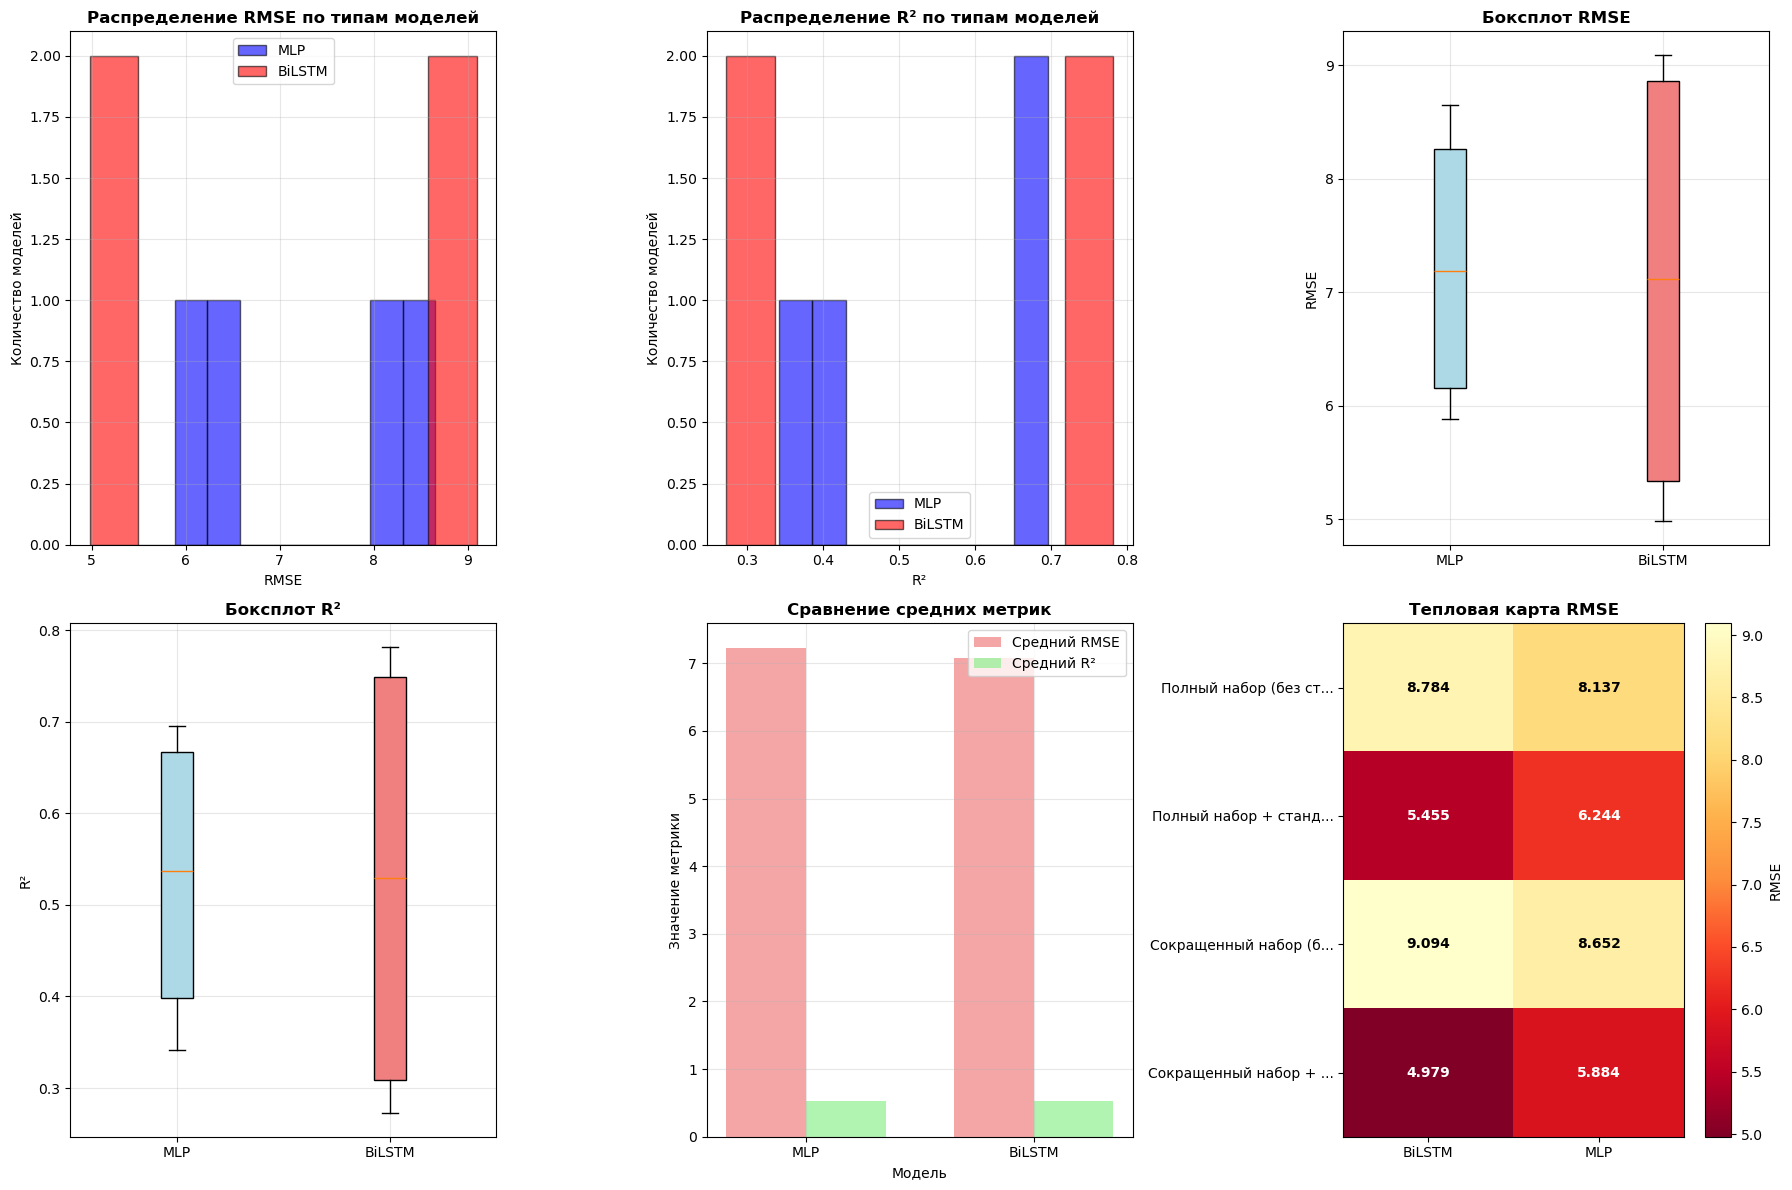

📈 СВОДНАЯ СТАТИСТИКА МЕТРИК:


,Модель,Средний RMSE,Средний R²,Лучший RMSE,Лучший R²
0,MLP,7.2292,0.5278,5.8839,0.6954
1,BiLSTM,7.0782,0.5284,4.9793,0.7819


In [362]:
# =============================================================================
# СРАВНЕНИЕ МЕТРИК МОДЕЛЕЙ
# =============================================================================

print("📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТРИК МОДЕЛЕЙ")
print("=" * 50)

# Создаем сравнительные графики метрик
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Сравнение RMSE по типам моделей
mlp_rmse = results_df[results_df['model'] == 'MLP']['val_rmse']
bilstm_rmse = results_df[results_df['model'] == 'BiLSTM']['val_rmse']

axes[0, 0].hist(mlp_rmse, alpha=0.6, label='MLP', color='blue', bins=8, edgecolor='black')
axes[0, 0].hist(bilstm_rmse, alpha=0.6, label='BiLSTM', color='red', bins=8, edgecolor='black')
axes[0, 0].set_title('Распределение RMSE по типам моделей', fontweight='bold')
axes[0, 0].set_xlabel('RMSE')
axes[0, 0].set_ylabel('Количество моделей')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Сравнение R² по типам моделей
mlp_r2 = results_df[results_df['model'] == 'MLP']['val_r2']
bilstm_r2 = results_df[results_df['model'] == 'BiLSTM']['val_r2']

axes[0, 1].hist(mlp_r2, alpha=0.6, label='MLP', color='blue', bins=8, edgecolor='black')
axes[0, 1].hist(bilstm_r2, alpha=0.6, label='BiLSTM', color='red', bins=8, edgecolor='black')
axes[0, 1].set_title('Распределение R² по типам моделей', fontweight='bold')
axes[0, 1].set_xlabel('R²')
axes[0, 1].set_ylabel('Количество моделей')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Боксплот RMSE
rmse_data = [mlp_rmse, bilstm_rmse]
box1 = axes[0, 2].boxplot(rmse_data, labels=['MLP', 'BiLSTM'], patch_artist=True)
for patch, color in zip(box1['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)
axes[0, 2].set_title('Боксплот RMSE', fontweight='bold')
axes[0, 2].set_ylabel('RMSE')
axes[0, 2].grid(True, alpha=0.3)

# 4. Боксплот R²
r2_data = [mlp_r2, bilstm_r2]
box2 = axes[1, 0].boxplot(r2_data, labels=['MLP', 'BiLSTM'], patch_artist=True)
for patch, color in zip(box2['boxes'], ['lightblue', 'lightcoral']):
    patch.set_facecolor(color)
axes[1, 0].set_title('Боксплот R²', fontweight='bold')
axes[1, 0].set_ylabel('R²')
axes[1, 0].grid(True, alpha=0.3)

# 5. Сравнение средних метрик
metrics_compare = pd.DataFrame({
    'Модель': ['MLP', 'BiLSTM'],
    'Средний RMSE': [mlp_rmse.mean(), bilstm_rmse.mean()],
    'Средний R²': [mlp_r2.mean(), bilstm_r2.mean()],
    'Лучший RMSE': [mlp_rmse.min(), bilstm_rmse.min()],
    'Лучший R²': [mlp_r2.max(), bilstm_r2.max()]
}).round(4)

# Визуализация средних метрик
x = np.arange(len(metrics_compare))
width = 0.35

bars1 = axes[1, 1].bar(x - width/2, metrics_compare['Средний RMSE'], width, 
                      label='Средний RMSE', color='lightcoral', alpha=0.7)
bars2 = axes[1, 1].bar(x + width/2, metrics_compare['Средний R²'], width, 
                      label='Средний R²', color='lightgreen', alpha=0.7)

axes[1, 1].set_title('Сравнение средних метрик', fontweight='bold')
axes[1, 1].set_xlabel('Модель')
axes[1, 1].set_ylabel('Значение метрики')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics_compare['Модель'])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Тепловая карта производительности
pivot_rmse = results_df.pivot_table(values='val_rmse', index='dataset', columns='model').round(3)
im = axes[1, 2].imshow(pivot_rmse.values, cmap='YlOrRd_r', aspect='auto')
axes[1, 2].set_title('Тепловая карта RMSE', fontweight='bold')
axes[1, 2].set_xticks(range(len(pivot_rmse.columns)))
axes[1, 2].set_xticklabels(pivot_rmse.columns)
axes[1, 2].set_yticks(range(len(pivot_rmse.index)))
axes[1, 2].set_yticklabels([label[:20] + '...' if len(label) > 20 else label 
                           for label in pivot_rmse.index])

# Добавляем значения в ячейки
for i in range(len(pivot_rmse.index)):
    for j in range(len(pivot_rmse.columns)):
        axes[1, 2].text(j, i, pivot_rmse.iloc[i, j], ha='center', va='center', 
                       fontweight='bold', color='black' if pivot_rmse.iloc[i, j] > pivot_rmse.values.mean() else 'white')

plt.colorbar(im, ax=axes[1, 2], label='RMSE')

plt.tight_layout()
plt.show()

# Выводим сводную таблицу
print("📈 СВОДНАЯ СТАТИСТИКА МЕТРИК:")
display(metrics_compare)